# 3D Stage 14 Computation Load

Single control notebook for the reproducible exact-SSE computational-load stages. Stage 14.0, 14.1, 14.2, 14.2A, 14.2B, 14.2C, 14.3, 14.4, 14.5, 14.6, 14.7, and 14.8 are integrated here; later approved Stage 14 substages should be appended without rerunning Stage 1-13 notebooks.

The default path is **artifact inspection**. Set a recomputation flag to `True` only when a fresh exact solve or fresh process-tree RSS measurement is required.

In [1]:
from pathlib import Path
import json
import sys

from IPython.display import FileLink, HTML, Image, display

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != '3D_0827':
    candidate = NOTEBOOK_DIR / '3D_0827'
    if not candidate.is_dir():
        raise RuntimeError('Run this notebook from the repository root or 3D_0827 directory.')
    NOTEBOOK_DIR = candidate
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from stage14_0_reference_diagnostics import run_stage14_0_diagnostics
from stage14_1_profiling_diagnostics import run_stage14_1_diagnostics
from stage14_2_benchmark_diagnostics import run_stage14_2_diagnostics
from stage14_2a_local_sse_diagnostics import run_stage14_2a_diagnostics
from stage14_2b_diagnostics import run_stage14_2b_diagnostics
from stage14_2c_diagnostics import run_stage14_2c_diagnostics
from stage14_3_diagnostics import run_stage14_3_diagnostics
from stage14_4_diagnostics import run_stage14_4_diagnostics
from stage14_5_diagnostics import run_stage14_5_diagnostics
from stage14_6_diagnostics import run_stage14_6_diagnostics
from stage14_7_scaling_analysis import run_stage14_7_analysis

STAGE14_0_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_0_benchmark_contract'
STAGE14_1_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_1_runtime_profiling'
STAGE14_2_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_2_benchmark_runner'
STAGE14_2A_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_2a_local_sse_contract'
STAGE14_2B_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_2b_local_sse_search'
STAGE14_2C_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_2c_local_scaling'
STAGE14_3_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_3_spatial_resolution'
STAGE14_4_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_4_heading_resolution'
STAGE14_5_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_5_switching_candidates'
STAGE14_6_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_6_neighbor_radius'
STAGE14_7_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_7_scaling_analysis'
STAGE14_8_DIR = NOTEBOOK_DIR / 'figure' / 'stage_14_8_final_gate'

def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def display_record(record):
    rows = ''.join(
        f'<tr><th style="text-align:left;padding:4px 12px">{key}</th>'
        f'<td style="padding:4px 12px">{value}</td></tr>'
        for key, value in record.items()
    )
    display(HTML(f'<table>{rows}</table>'))

print(f'Stage 14 workspace: {NOTEBOOK_DIR}')

Stage 14 workspace: C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827


## Execution policy

Keep all recomputation flags `False` for fast inspection of saved artifacts. Stage 14.0 recomputes the frozen reference, Stage 14.1 profiles one solve, Stage 14.2 runs/resumes the repetition smoke benchmark, and Stage 14.2A regenerates only the local-SSE contract diagnostics. Stage 14.2B runs the canonical exact local search in a fresh measured process. Stage 14.2C runs/resumes the approved local-scaling and matched global-oracle matrix. Stage 14.3 reuses identical 14.2C coarse/baseline isolated-process rows and runs only missing progressively finer spatial cases.

gate_passed,True
defender_action,3
attacker_candidate,27
J_A,7.1945895064610585
J_D_PoD,0.9999991723787202
mission_time_s,85.0594766128556


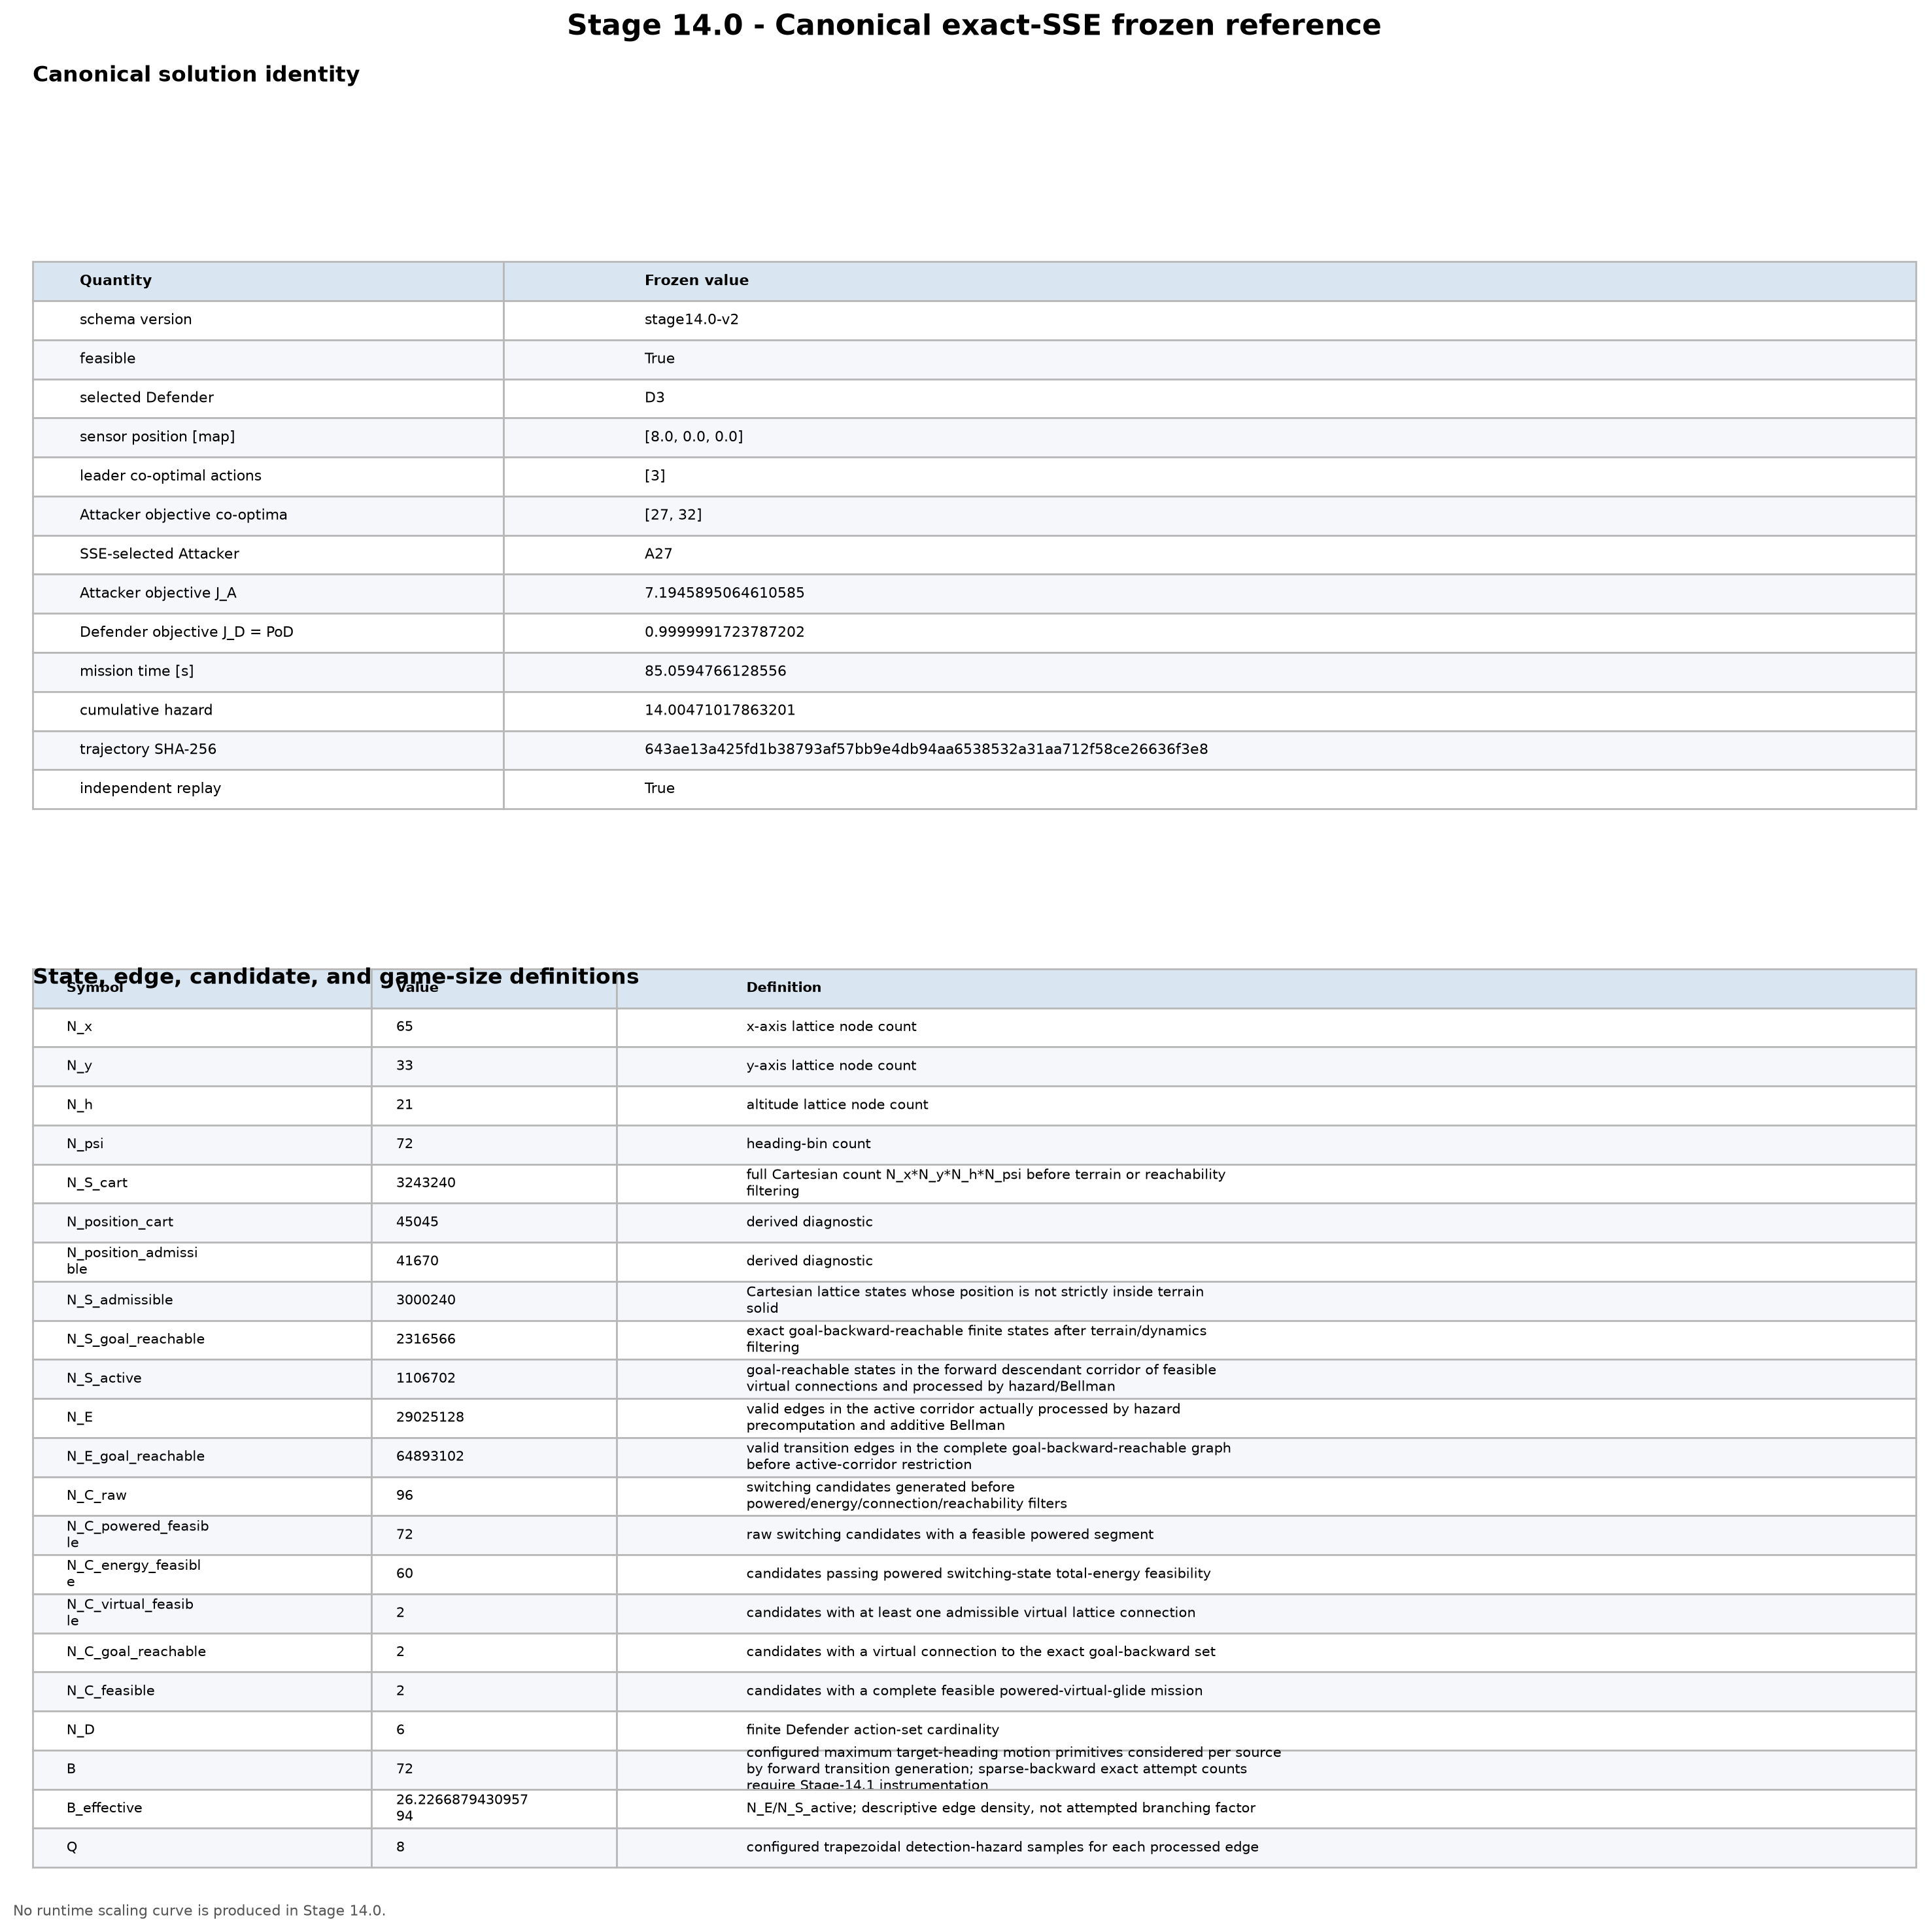

In [2]:
# Stage-level execution controls.
# True  = discard/resample that stage's benchmark rows and rebuild artifacts.
# False = load existing JSON/PNG artifacts without launching workers.
RECOMPUTE_STAGE14_1 = False
RECOMPUTE_STAGE14_2 = False  # controls 14.2, 14.2A, 14.2B, and 14.2C
RECOMPUTE_STAGE14_3 = False
RECOMPUTE_STAGE14_4 = False
RECOMPUTE_STAGE14_5 = False
RECOMPUTE_STAGE14_6 = False
RECOMPUTE_STAGE14_7 = False

# Set True once after an approved canonical-game change, then restore False.
REBASELINE_STAGE14_0 = False

if REBASELINE_STAGE14_0:
    _, _, stage14_0_reference = run_stage14_0_diagnostics(STAGE14_0_DIR, allow_scenario_rebaseline=True)
else:
    reference_path = STAGE14_0_DIR / 'frozen_reference.json'
    if not reference_path.exists():
        raise FileNotFoundError('Stage 14.0 artifact is absent; set REBASELINE_STAGE14_0=True once, review it, then return it to False.')
    stage14_0_reference = load_json(reference_path)

stage14_0_summary = load_json(STAGE14_0_DIR / 'stage14_0_summary.json')
identity = stage14_0_reference['solution_identity']
display_record({
    'gate_passed': stage14_0_summary['gate_passed'],
    'defender_action': identity['selected_defender_action_id'],
    'attacker_candidate': identity['selected_attacker_candidate_id'],
    'J_A': identity['attacker_objective'],
    'J_D_PoD': identity['defender_objective_pod'],
    'mission_time_s': identity['mission_time_s'],
})

display(Image(filename=str(STAGE14_0_DIR / 'baseline_identity_and_state_counts.png')))

## Stage 14.1 — reliable runtime and peak-memory instrumentation

The saved result can be inspected immediately. Fresh recomputation is intentionally opt-in because it performs the exact SSE solve again.

In [3]:
if RECOMPUTE_STAGE14_1:
    stage14_1_summary = run_stage14_1_diagnostics(STAGE14_1_DIR)
else:
    summary_path = STAGE14_1_DIR / 'stage14_1_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError('Stage 14.1 artifact is absent; set RECOMPUTE_STAGE14_1=True.')
    stage14_1_summary = load_json(summary_path)

totals = stage14_1_summary['timing']['totals']
memory = stage14_1_summary['process_tree_memory']
display_record({
    'gate_passed': stage14_1_summary['gate_passed'],
    'T_SSE_s': totals['T_SSE_s'],
    'peak_RSS_MiB': memory['peak_rss_bytes'] / 1024**2,
    'delta_RSS_MiB': memory['delta_peak_rss_bytes'] / 1024**2,
    'profiled_solution_match': stage14_1_summary['profiled_vs_unprofiled_match'],
    'infeasible_fixture': stage14_1_summary['infeasible_fixture_status'],
})

gate_passed,True
T_SSE_s,62.055722799999785
peak_RSS_MiB,194.859375
delta_RSS_MiB,188.9375
profiled_solution_match,True
infeasible_fixture,model_infeasible


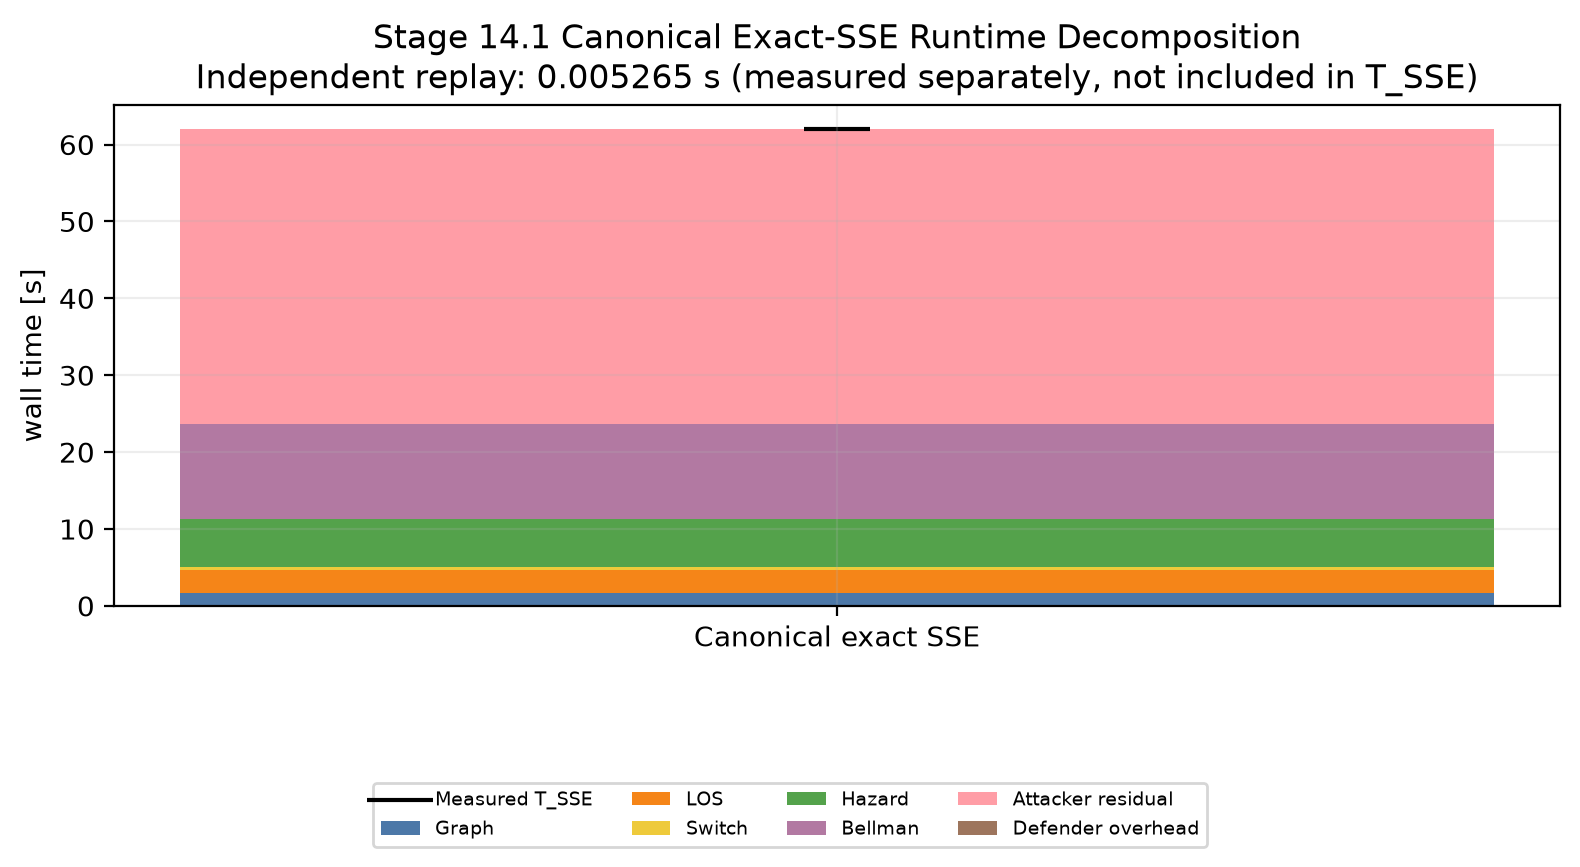

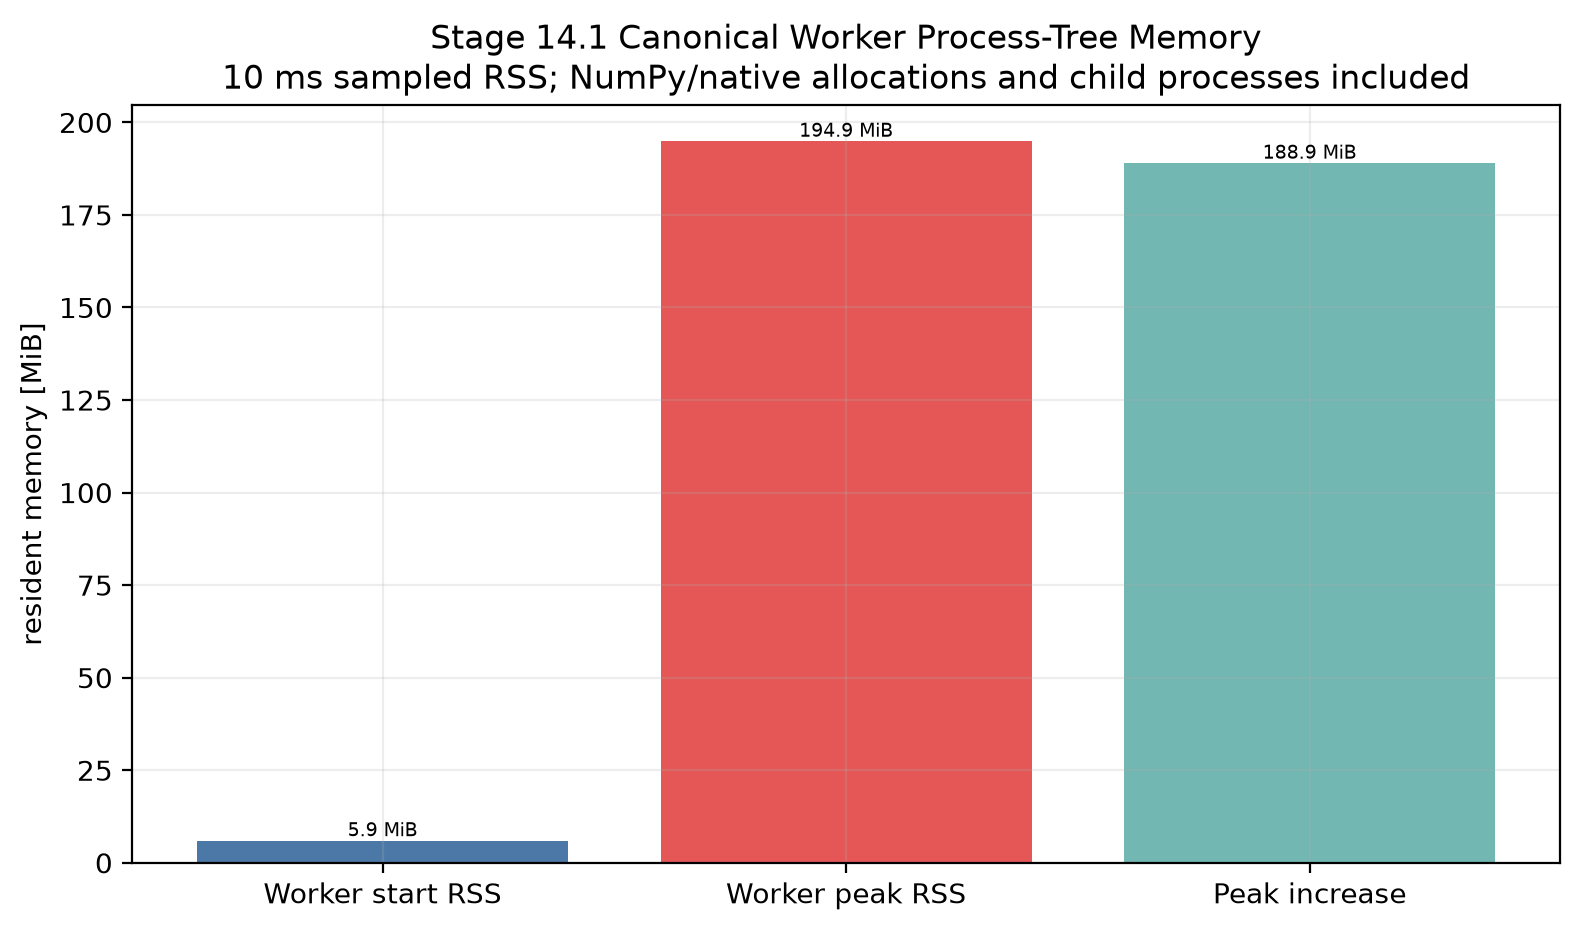

In [4]:
display(Image(filename=str(STAGE14_1_DIR / 'canonical_runtime_decomposition.png')))
display(Image(filename=str(STAGE14_1_DIR / 'canonical_memory_summary.png')))

In [5]:
print('Machine-readable artifacts')
display(FileLink(STAGE14_0_DIR / 'frozen_reference.json'))
display(FileLink(STAGE14_1_DIR / 'stage14_1_summary.json'))
display(FileLink(STAGE14_1_DIR / 'canonical_timing.csv'))

Machine-readable artifacts


C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_0_benchmark_contract\frozen_reference.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_1_runtime_profiling\stage14_1_summary.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_1_runtime_profiling\canonical_timing.csv

## Stage 14.2 — reproducible repetitions and resume behavior

The smoke benchmark uses three fresh canonical repetitions plus explicit infeasible and controlled-timeout fixtures. It validates the runner and does not constitute a scaling sweep.

In [6]:
if RECOMPUTE_STAGE14_2:
    stage14_2_summary = run_stage14_2_diagnostics(STAGE14_2_DIR, force=True)
else:
    summary_path = STAGE14_2_DIR / 'stage14_2_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError('Stage 14.2 artifact is absent; set RECOMPUTE_STAGE14_2=True.')
    stage14_2_summary = load_json(summary_path)

repeat_stats = stage14_2_summary['canonical_repetition_statistics']
display_record({
    'gate_passed': stage14_2_summary['gate_passed'],
    'fresh_process_repetitions': repeat_stats['count'],
    'median_T_SSE_s': repeat_stats['median'],
    'mean_T_SSE_s': repeat_stats['mean'],
    'sample_std_s': repeat_stats['standard_deviation_sample'],
    'minimum_s': repeat_stats['minimum'],
    'maximum_s': repeat_stats['maximum'],
    'statuses': stage14_2_summary['status_counts'],
    'resume_passed': stage14_2_summary['resume_behavior_deterministic'],
})

gate_passed,True
fresh_process_repetitions,3
median_T_SSE_s,62.40206969999963
mean_T_SSE_s,62.37471343333315
sample_std_s,0.6217480316870009
minimum_s,61.73973879999994
maximum_s,62.98233179999988
statuses,"{'completed': 3, 'model_infeasible': 1, 'timeout': 1}"
resume_passed,True


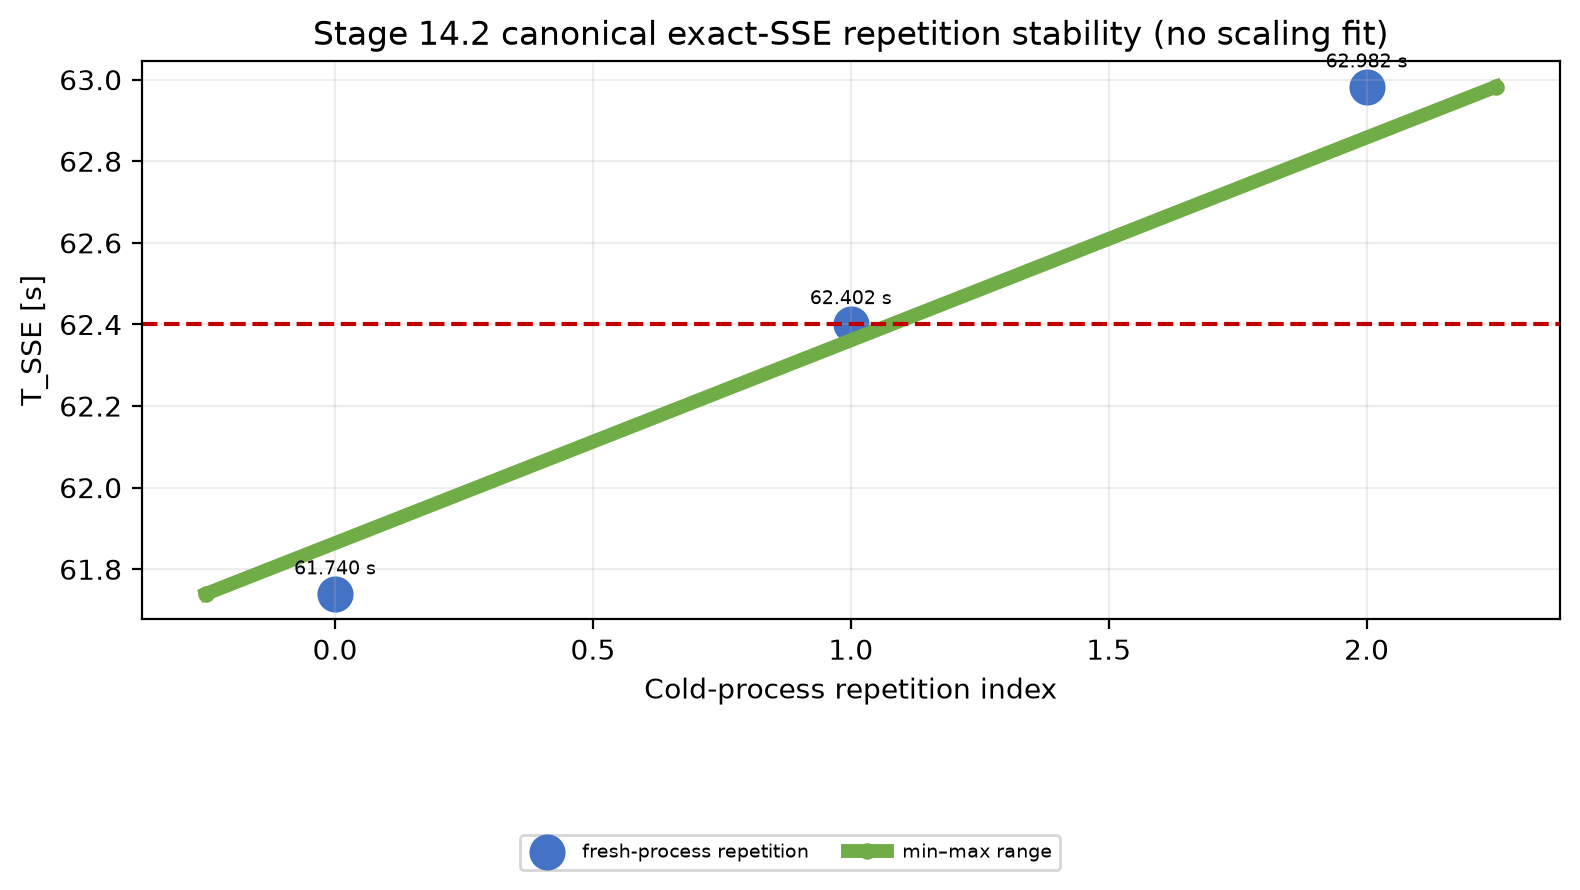

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_2_benchmark_runner\raw_repetitions.jsonl

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_2_benchmark_runner\raw_repetitions.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_2_benchmark_runner\configuration_summaries.csv

In [7]:
display(Image(filename=str(STAGE14_2_DIR / 'canonical_repetition_stability.png')))
display(FileLink(STAGE14_2_DIR / 'raw_repetitions.jsonl'))
display(FileLink(STAGE14_2_DIR / 'raw_repetitions.csv'))
display(FileLink(STAGE14_2_DIR / 'configuration_summaries.csv'))

## Stage 14.2A — local-SSE mathematical contract

This section verifies the configurable Defender grid neighborhood and the local/global distinction. It does not run a local search and does not modify the frozen global finite-SSE solver.

In [8]:
if RECOMPUTE_STAGE14_2:
    stage14_2a_summary = run_stage14_2a_diagnostics(STAGE14_2A_DIR)
else:
    summary_path = STAGE14_2A_DIR / 'stage14_2a_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError('Stage 14.2A artifact is absent; set RECOMPUTE_STAGE14_2=True.')
    stage14_2a_summary = load_json(summary_path)

display_record({
    'gate_passed': stage14_2a_summary['gate_passed'],
    'default_r_neighbor': stage14_2a_summary['default_r_neighbor'],
    'neighbor_metric': stage14_2a_summary['neighbor_metric'],
    'tiny_local_sse_actions': stage14_2a_summary['tiny_local_sse_action_ids'],
    'tiny_global_sse_actions': stage14_2a_summary['tiny_global_sse_action_ids'],
    'full_radius_equals_global': stage14_2a_summary['full_radius_equals_global'],
    'frozen_global_passes_local_verifier': stage14_2a_summary['current_global_action_passes_local_verifier'],
    'global_solver_modified': stage14_2a_summary['global_solver_modified'],
})

gate_passed,True
default_r_neighbor,1
neighbor_metric,chebyshev_grid_index
tiny_local_sse_actions,"[1, 3]"
tiny_global_sse_actions,[3]
full_radius_equals_global,True
frozen_global_passes_local_verifier,True
global_solver_modified,False


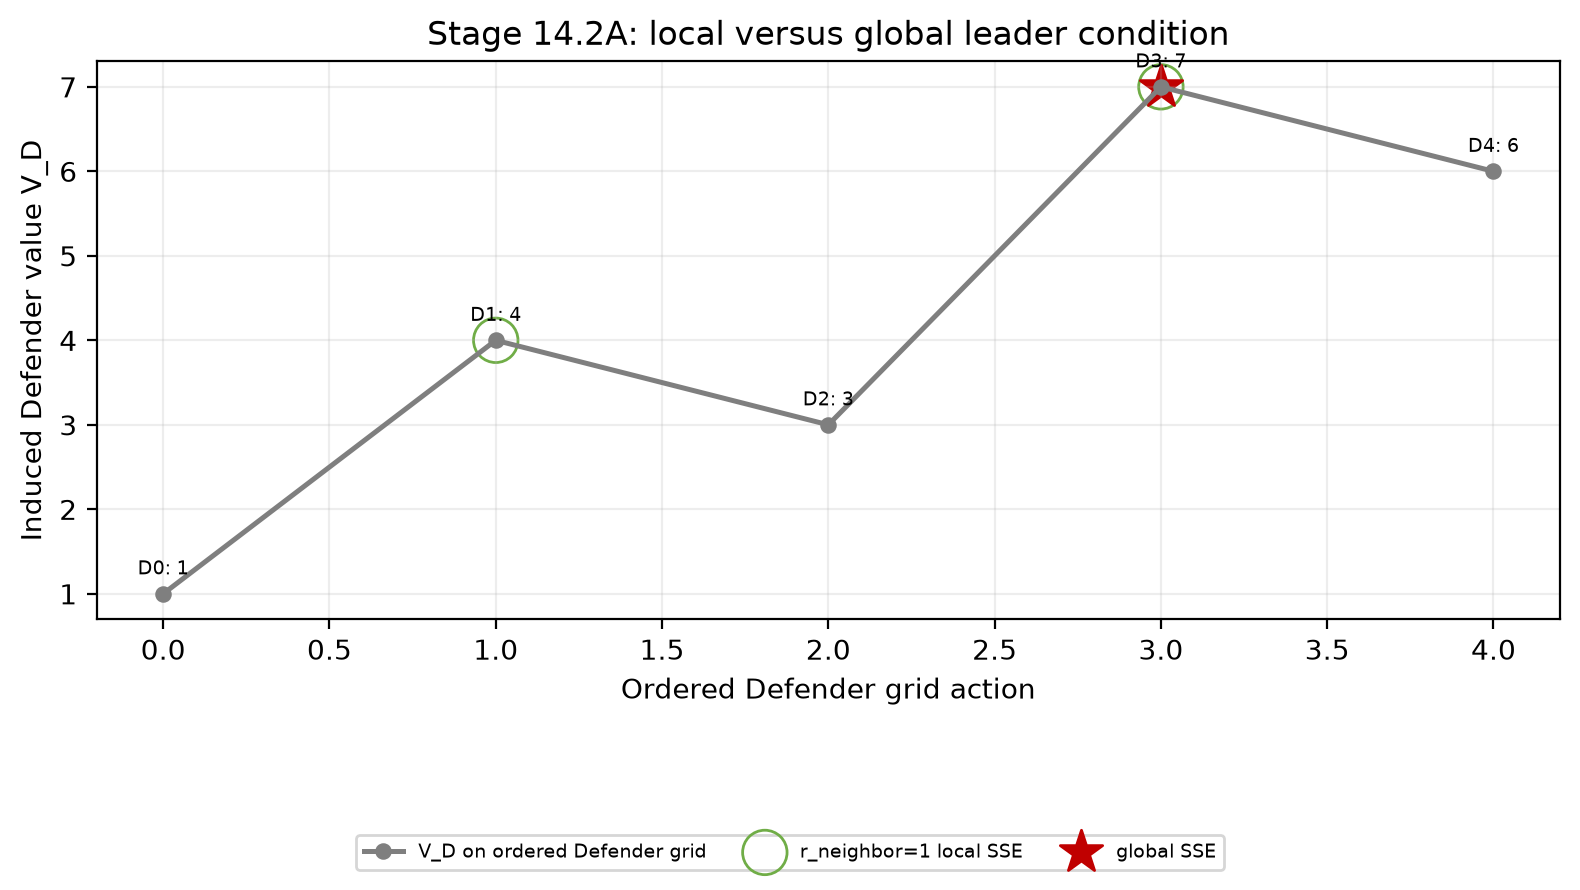

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_2a_local_sse_contract\local_sse_mathematical_contract.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_2a_local_sse_contract\current_discretized_existence_report.json

In [9]:
display(Image(filename=str(STAGE14_2A_DIR / 'local_vs_global_payoff_diagnostic.png')))
display(FileLink(STAGE14_2A_DIR / 'local_sse_mathematical_contract.json'))
display(FileLink(STAGE14_2A_DIR / 'current_discretized_existence_report.json'))

## Stage 14.2B — exact local-SSE search and certification

Starting from canonical Defender action `D0`, this section displays the saved
single-start, strict-improvement local search with `r_neighbor=1`. Every action
that appears with a payoff was evaluated using the existing exhaustive finite
Attacker best response and Strong follower tie-break. This is a **local finite-grid
SSE certificate**, not a global or continuous-space optimality claim.

In [10]:
if RECOMPUTE_STAGE14_2:
    stage14_2b_summary = run_stage14_2b_diagnostics(STAGE14_2B_DIR, recompute=True)
else:
    summary_path = STAGE14_2B_DIR / 'stage14_2b_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError('Stage 14.2B artifact is absent; set RECOMPUTE_STAGE14_2=True.')
    stage14_2b_summary = load_json(summary_path)

display_record({
    'gate_passed': stage14_2b_summary['gate_passed'],
    'termination': stage14_2b_summary['termination_status'],
    'scope': stage14_2b_summary['solution_scope'],
    'visited': stage14_2b_summary['visited_defender_actions'],
    'evaluated': stage14_2b_summary['evaluated_defender_actions'],
    'final_defender_action': stage14_2b_summary['final_local_sse_action_id'],
    'final_attacker_response': stage14_2b_summary['final_attacker_response_id'],
    'J_A': stage14_2b_summary['final_J_A'],
    'J_D_PoD': stage14_2b_summary['final_J_D'],
    'local_margin': stage14_2b_summary['local_optimality_margin'],
    'T_local_s': stage14_2b_summary['runtime_decomposition_s']['T_local_s'],
    'peak_RSS_MiB': stage14_2b_summary['peak_memory']['peak_rss_bytes'] / 1024**2,
    'global_optimality_evaluated': stage14_2b_summary['global_optimality_evaluated'],
})

gate_passed,True
termination,certified_local_sse
scope,local Strong Stackelberg equilibrium over an explicit finite Defender grid neighborhood; not a global or continuous-space optimality claim
visited,"[0, 1, 2]"
evaluated,"[0, 1, 2]"
final_defender_action,2
final_attacker_response,26
J_A,0.944086144839464
J_D_PoD,0.7814861193516704
local_margin,0.5720758796637269
T_local_s,58.82822949999991


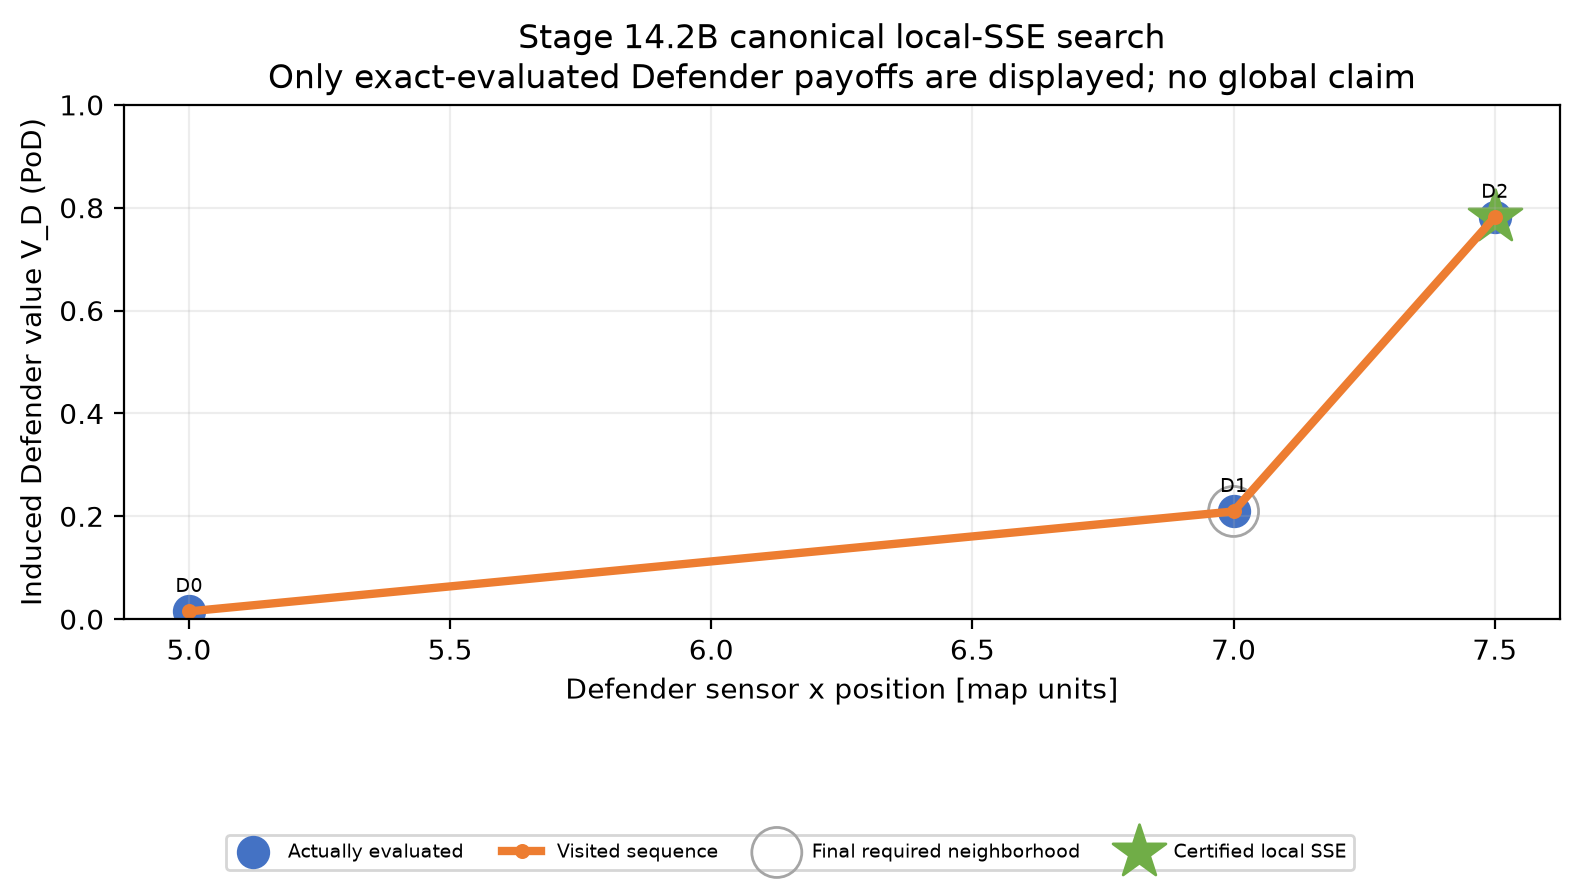

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_2b_local_sse_search\local_search_history.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_2b_local_sse_search\runtime_memory_summary.json

In [11]:
display(Image(filename=str(STAGE14_2B_DIR / 'local_search_diagnostic.png')))
display(FileLink(STAGE14_2B_DIR / 'local_search_history.json'))
display(FileLink(STAGE14_2B_DIR / 'runtime_memory_summary.json'))

## Stage 14.2C — local-SSE scaling and global-oracle gap

This section reports 60 fresh-process measurements over four controlled
one-factor-at-a-time sweeps. Terrain remains the single centered cube. The
single-start local SSE is the primary object; the exact global finite SSE is
used only as a matched tractable oracle. Reported gaps are empirical values on
the tested finite grids, not approximation-error bounds.

In [12]:
if RECOMPUTE_STAGE14_2:
    stage14_2c_summary = run_stage14_2c_diagnostics(STAGE14_2C_DIR, force=True)
else:
    summary_path = STAGE14_2C_DIR / 'stage14_2c_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError('Stage 14.2C artifact is absent; set RECOMPUTE_STAGE14_2=True.')
    stage14_2c_summary = load_json(summary_path)

display_record({
    'gate_passed': stage14_2c_summary['gate_passed'],
    'local_cases': stage14_2c_summary['local_case_count'],
    'global_oracle_cases': stage14_2c_summary['global_oracle_case_count'],
    'repetitions_per_case': stage14_2c_summary['repetitions_per_case'],
    'raw_rows': stage14_2c_summary['total_repetition_rows'],
    'completed_local_repetitions': stage14_2c_summary['local_completed_repetitions'],
    'completed_global_oracle_repetitions': stage14_2c_summary['global_oracle_completed_repetitions'],
    'oracle_comparisons': stage14_2c_summary['successful_oracle_comparisons'],
    'multi_start_performed': stage14_2c_summary['interpretation']['multi_start_performed'],
    'gap_is_empirical_not_bounded': stage14_2c_summary['interpretation']['gap_is_empirical_not_bounded'],
})

gate_passed,True
local_cases,10
global_oracle_cases,10
repetitions_per_case,3
raw_rows,60
completed_local_repetitions,30
completed_global_oracle_repetitions,30
oracle_comparisons,10
multi_start_performed,False
gap_is_empirical_not_bounded,True


In [13]:
stage14_2c_local = load_json(STAGE14_2C_DIR / 'local_scaling_summaries.json')
stage14_2c_oracle = load_json(STAGE14_2C_DIR / 'local_vs_global_oracle.json')
local_rows = [[
    row['profile'],
    round(row['runtime_statistics_s']['median'], 3),
    row['state_and_game_size']['N_S_active'],
    row['state_and_game_size']['N_E'],
    row['state_and_game_size']['N_C'],
    row['state_and_game_size']['N_D'],
    row['local_search_statistics']['unique_defender_evaluations']['median'],
    row['local_search_statistics']['local_search_iterations']['median'],
    row['local_search_outcomes']['isolated_feasible_local_sse_repetitions'],
    round(row['J_D_statistics']['median'], 9),
] for row in stage14_2c_local]
display(HTML(
    '<table><tr><th>profile</th><th>T_local median [s]</th><th>N_S active</th>'
    '<th>N_E</th><th>N_C</th><th>N_D</th><th>N_eval</th><th>K</th>'
    '<th>isolated reps</th><th>J_D</th></tr>'
    + ''.join('<tr>' + ''.join(f'<td>{value}</td>' for value in row) + '</tr>' for row in local_rows)
    + '</table><style>th,td{border:1px solid #bbb;padding:4px 7px}</style>'
))

oracle_rows = [row for row in stage14_2c_oracle if row['status'] == 'completed']
display(HTML(
    '<h4>Tractable exact-global oracle comparisons</h4>'
    '<table><tr><th>profile</th><th>T_local</th><th>T_global</th><th>ratio</th><th>ΔJ_D</th></tr>'
    + ''.join(
        f"<tr><td>{row['profile']}</td><td>{row['T_local_median_s']:.3f}</td>"
        f"<td>{row['T_global_median_s']:.3f}</td>"
        f"<td>{row['runtime_ratio_global_over_local']:.3f}</td>"
        f"<td>{row['delta_J_D']:.9f}</td></tr>" for row in oracle_rows
    )
    + '</table><style>th,td{border:1px solid #bbb;padding:4px 7px}</style>'
))

profile,T_local median [s],N_S active,N_E,N_C,N_D,N_eval,K,isolated reps,J_D
canonical_anchor,58.596,1106941,29035732,96,3,3.0,3.0,0,0.781486119
spatial_100m,7.858,461,898,96,3,3.0,3.0,0,0.912150501
spatial_50m,29.87,63518,1318846,96,3,3.0,3.0,0,0.893834547
heading_15deg,4.565,23930,66792,96,3,3.0,3.0,0,0.791285964
heading_10deg,11.785,237004,1747998,96,3,3.0,3.0,0,0.784331899
switch_contour_6,16.877,1042933,27179226,48,3,2.0,1.0,3,0.014278007
switch_contour_9,43.967,954387,24629774,72,3,3.0,3.0,0,0.781493552
defender_count_2,40.569,1106941,29035732,96,2,2.0,2.0,0,0.781486119
defender_count_3,18.876,1098590,28797135,96,3,2.0,1.0,3,0.015043572
defender_count_5,19.055,1098590,28797135,96,5,2.0,1.0,3,0.015043572


profile,T_local,T_global,ratio,ΔJ_D
canonical_anchor,58.596,58.409,0.997,0.000000000
defender_count_2,40.569,38.424,0.947,0.000000000
defender_count_3,18.876,39.526,2.094,0.766442547
defender_count_5,19.055,41.749,2.191,0.766442547
heading_10deg,11.785,11.047,0.937,0.000000000
heading_15deg,4.565,4.365,0.956,0.000000000
spatial_100m,7.858,7.512,0.956,0.000000000
spatial_50m,29.870,28.436,0.952,0.000000000
switch_contour_6,16.877,27.843,1.650,0.767193124
switch_contour_9,43.967,41.278,0.939,0.000000000


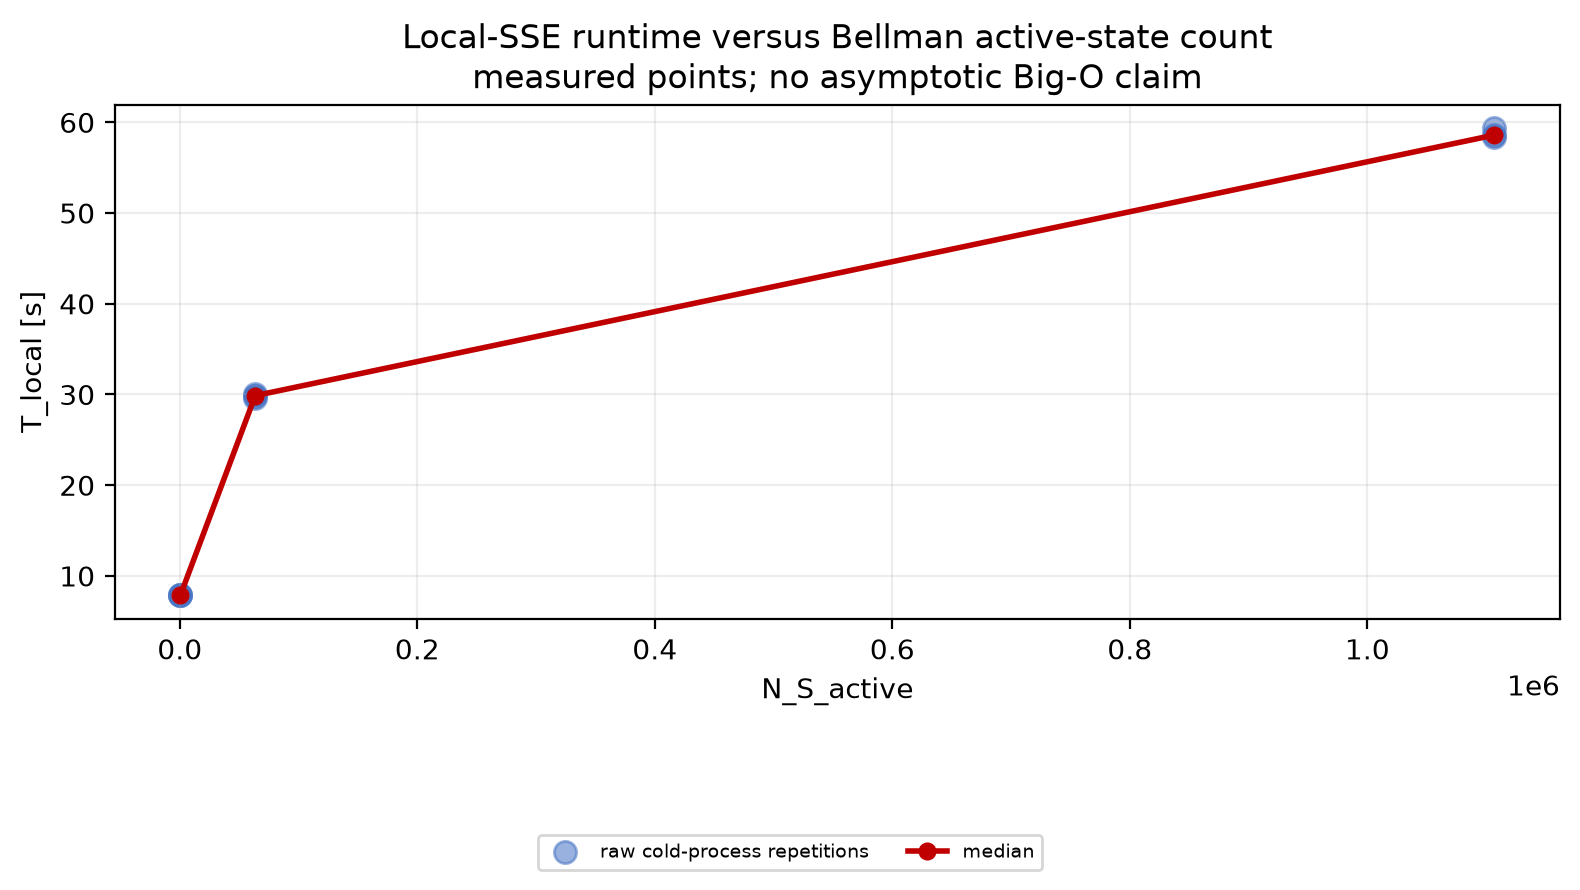

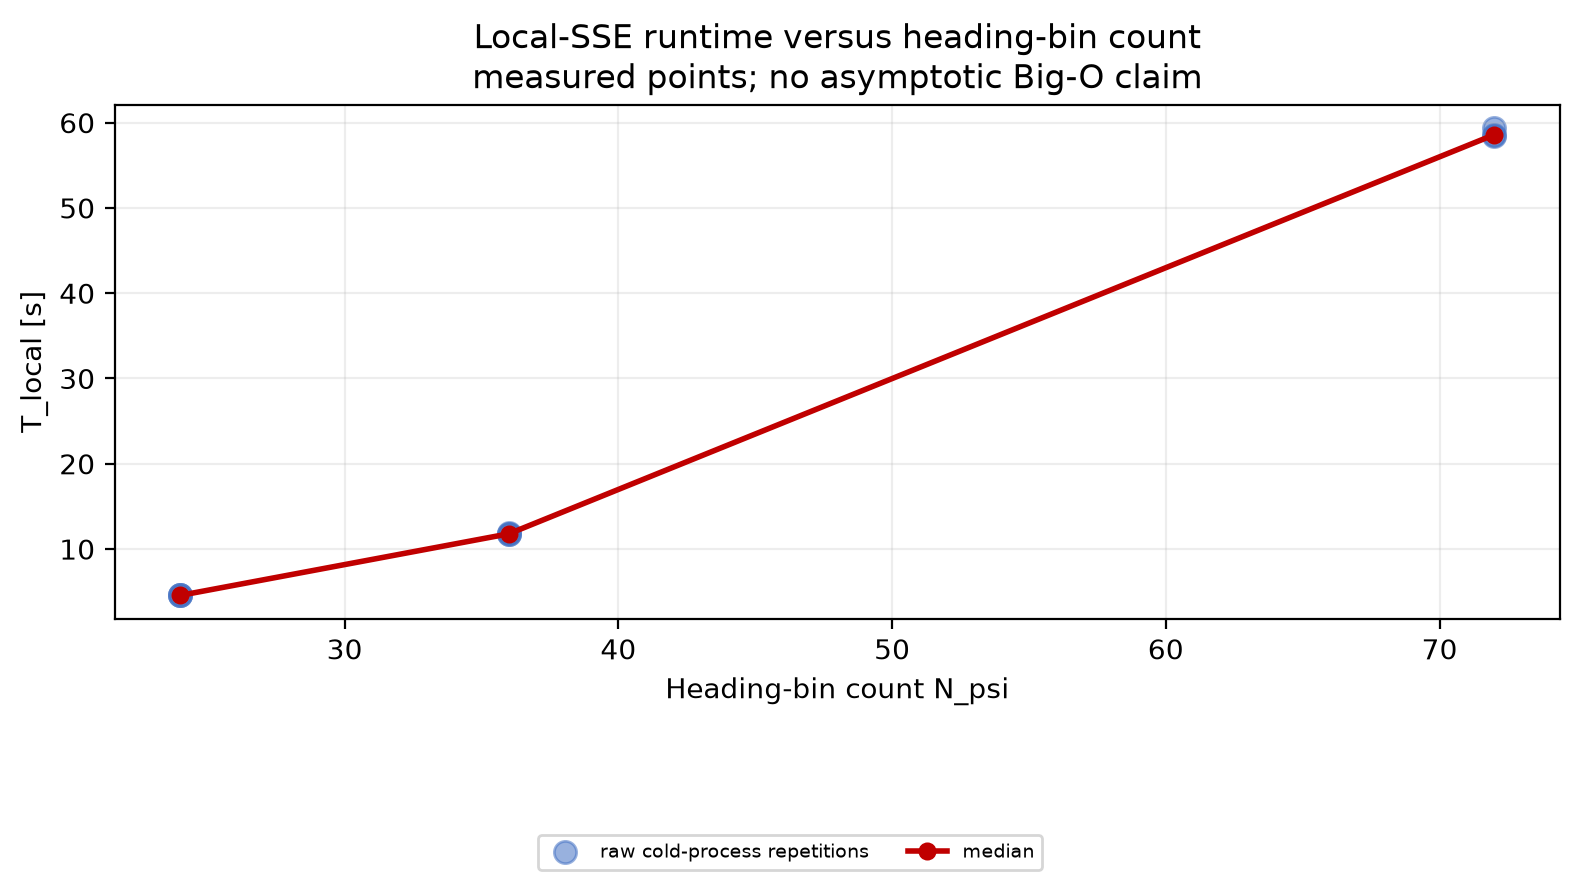

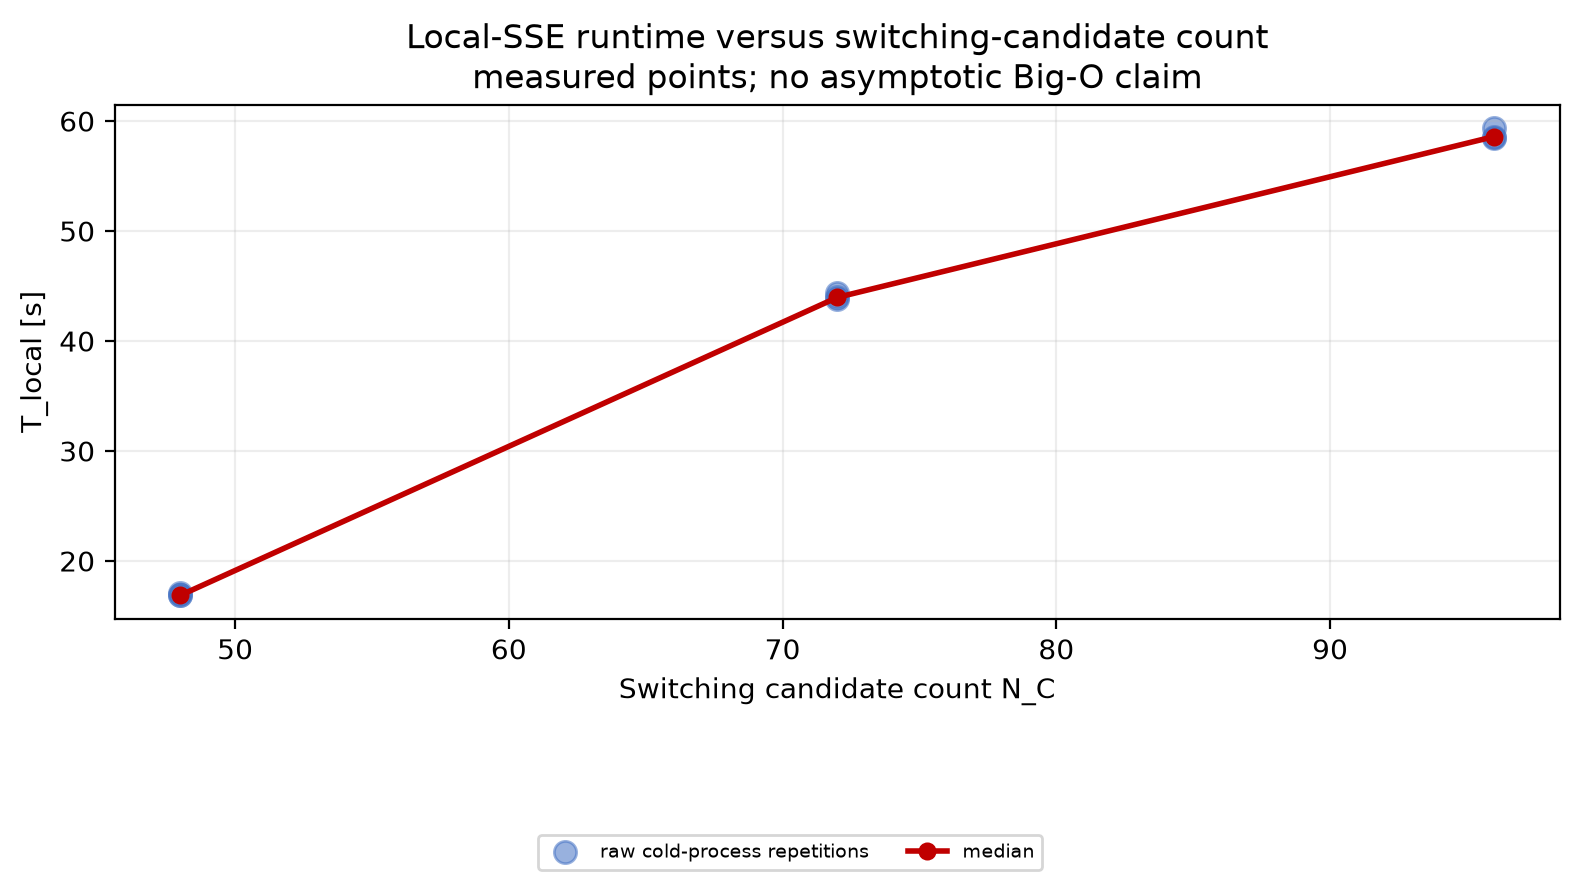

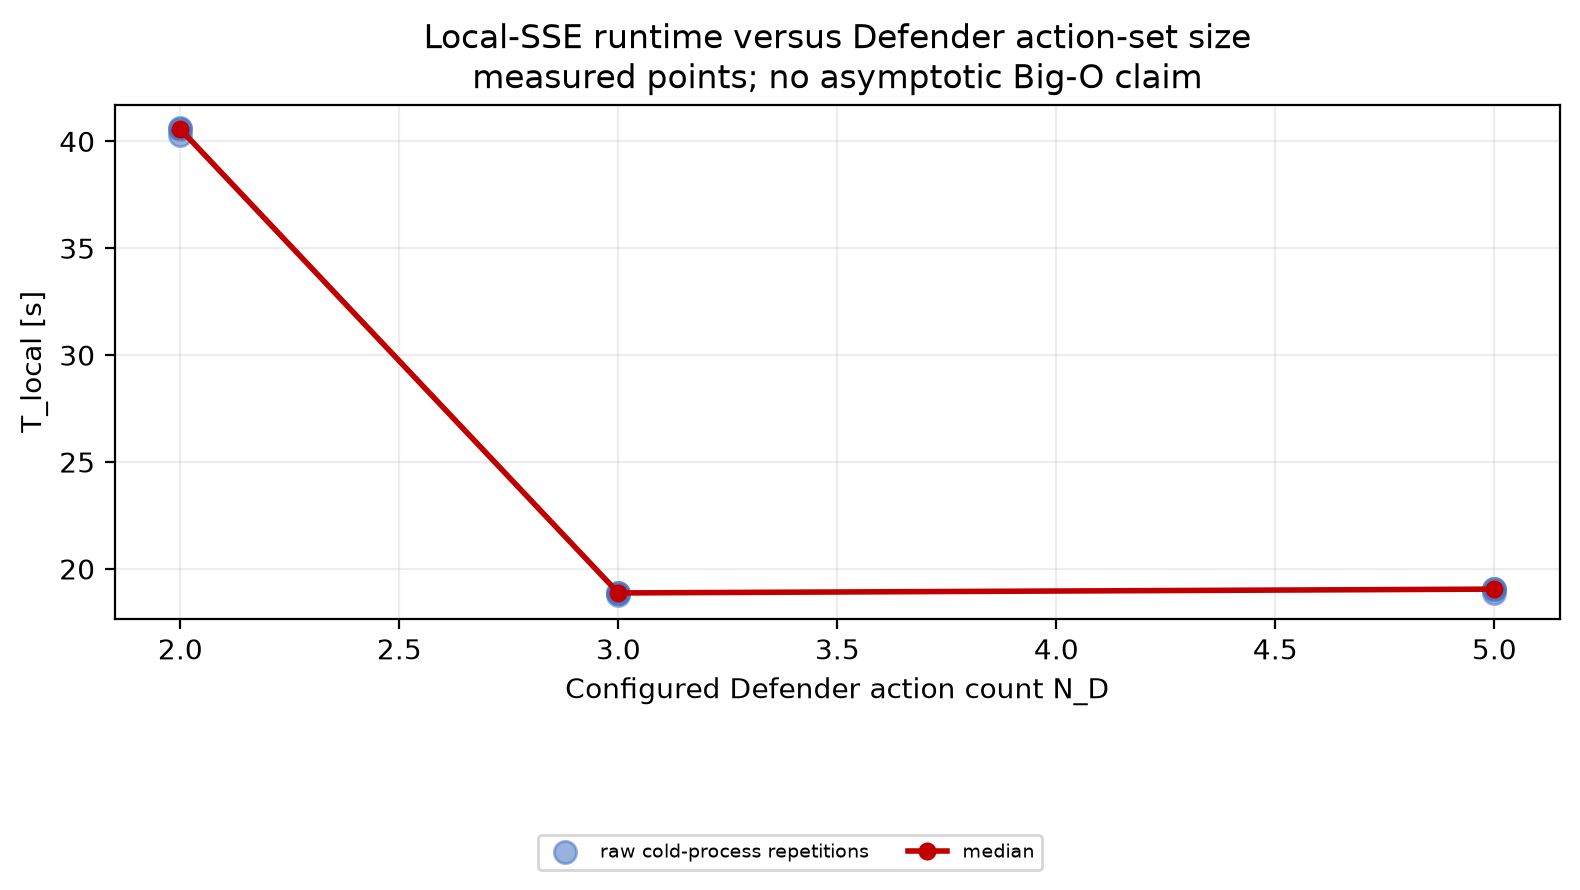

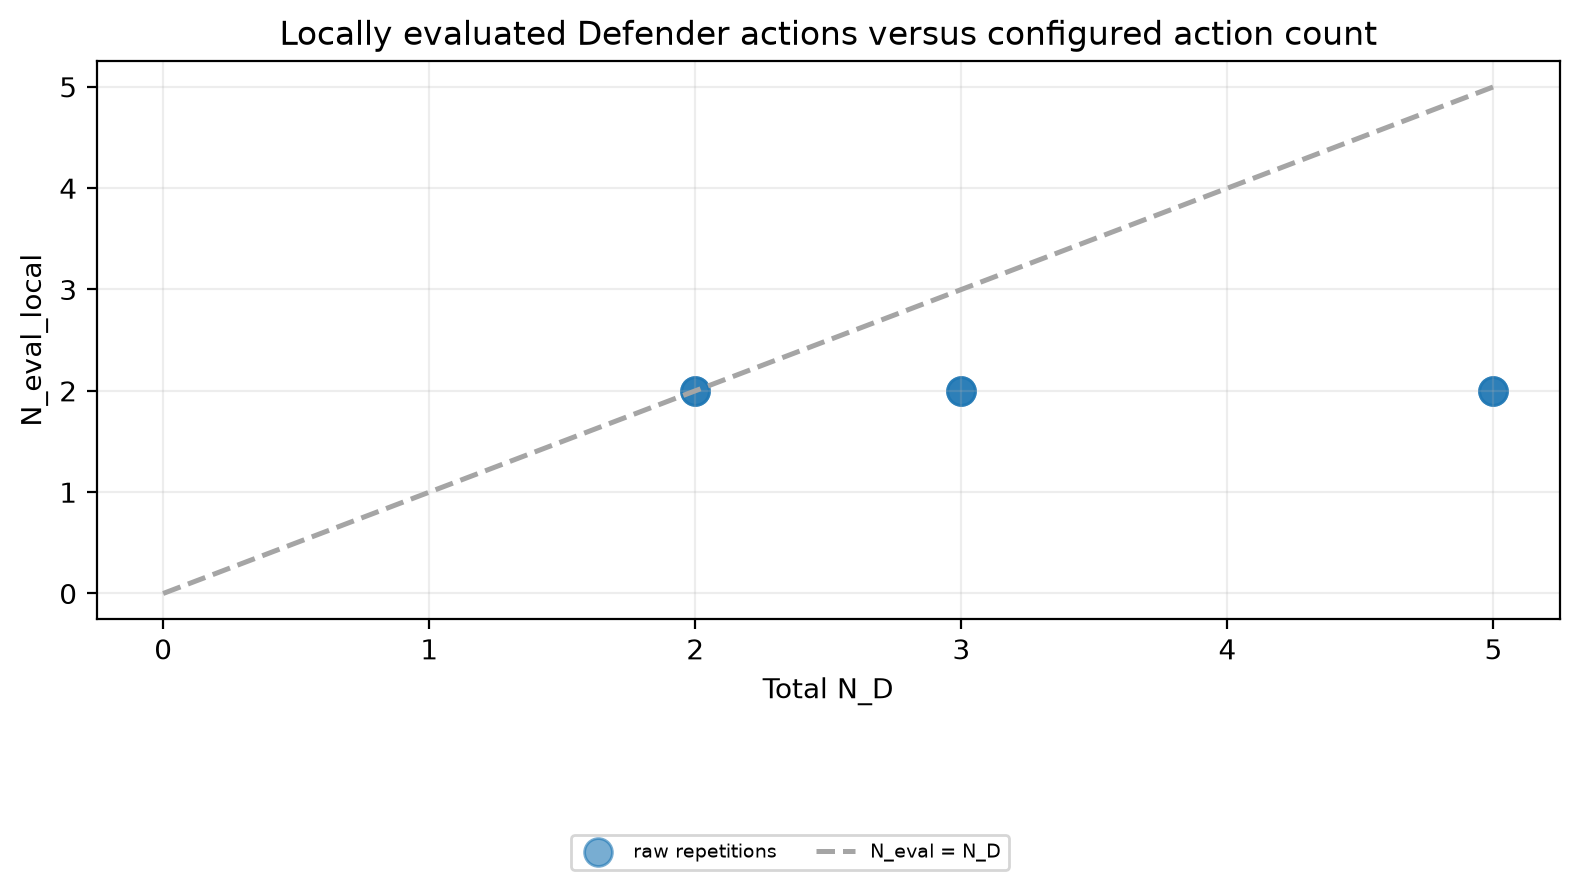

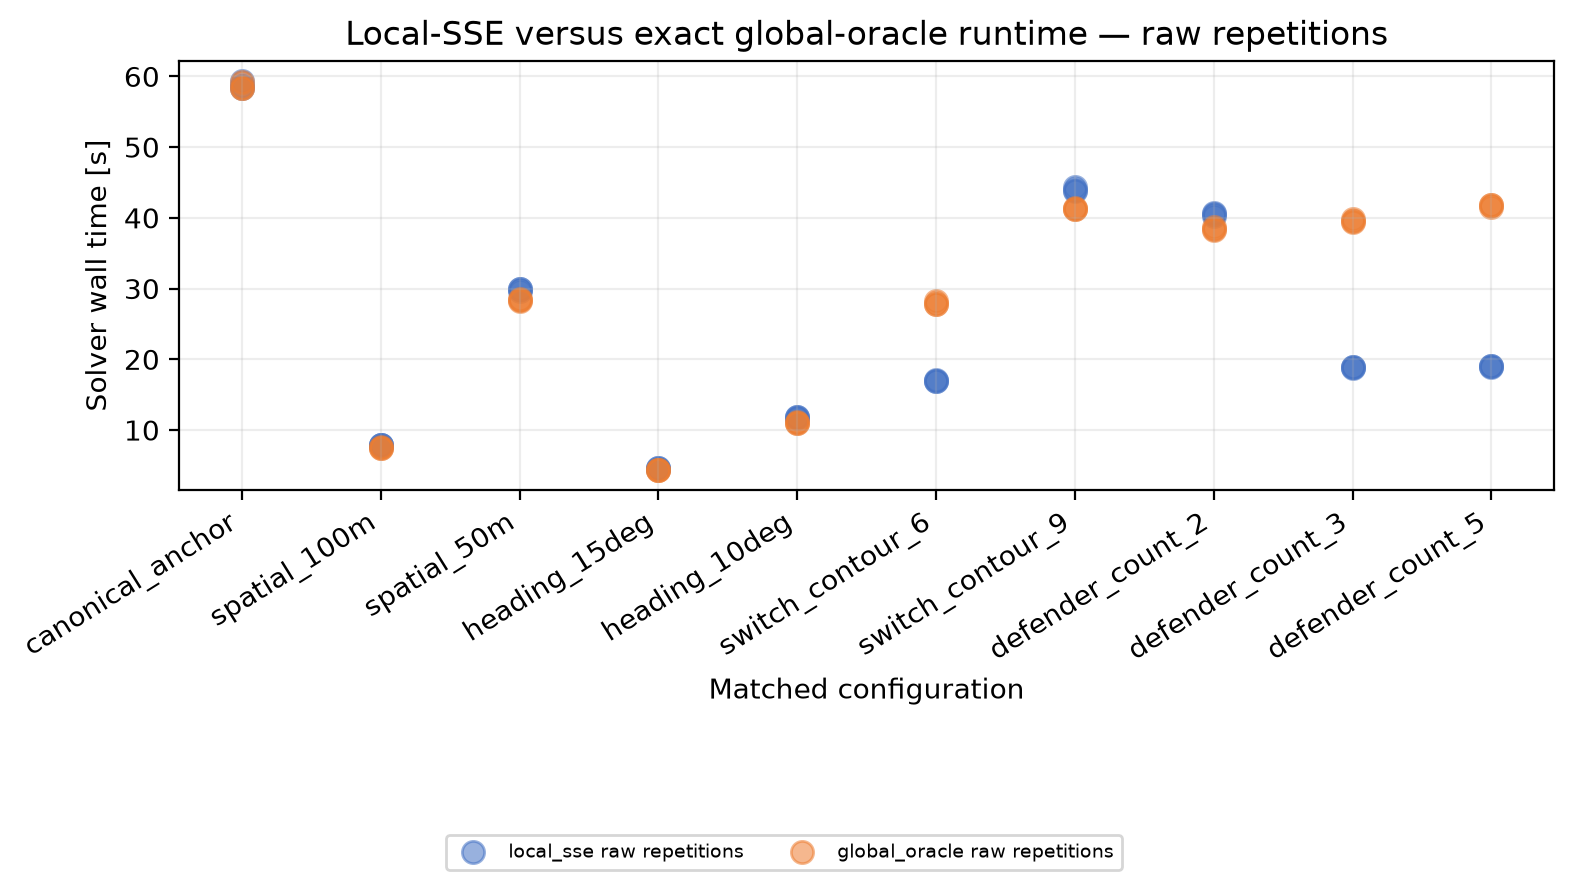

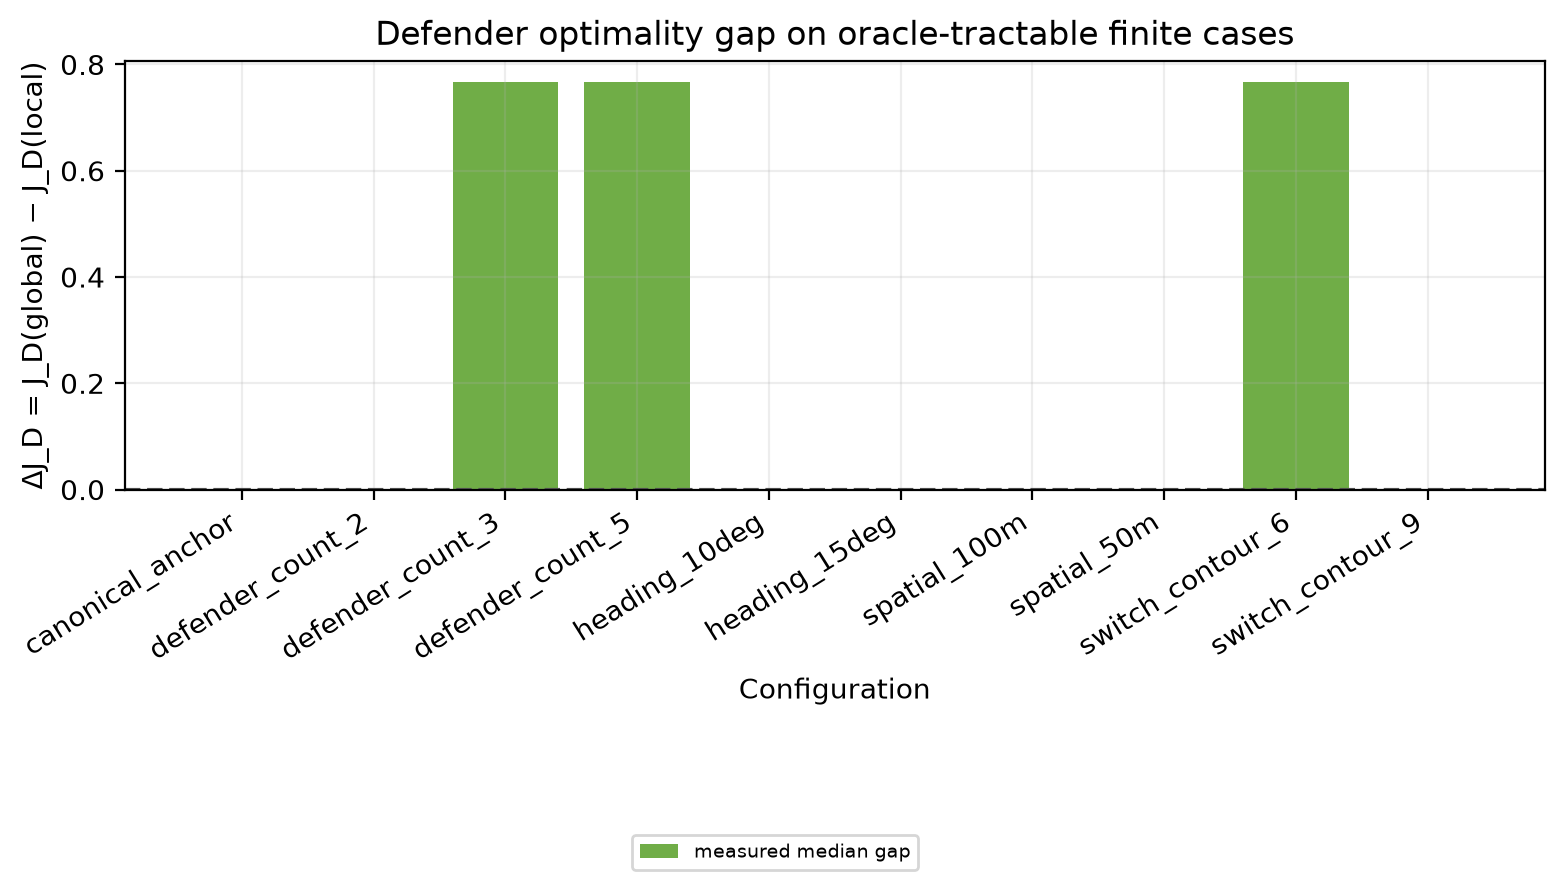

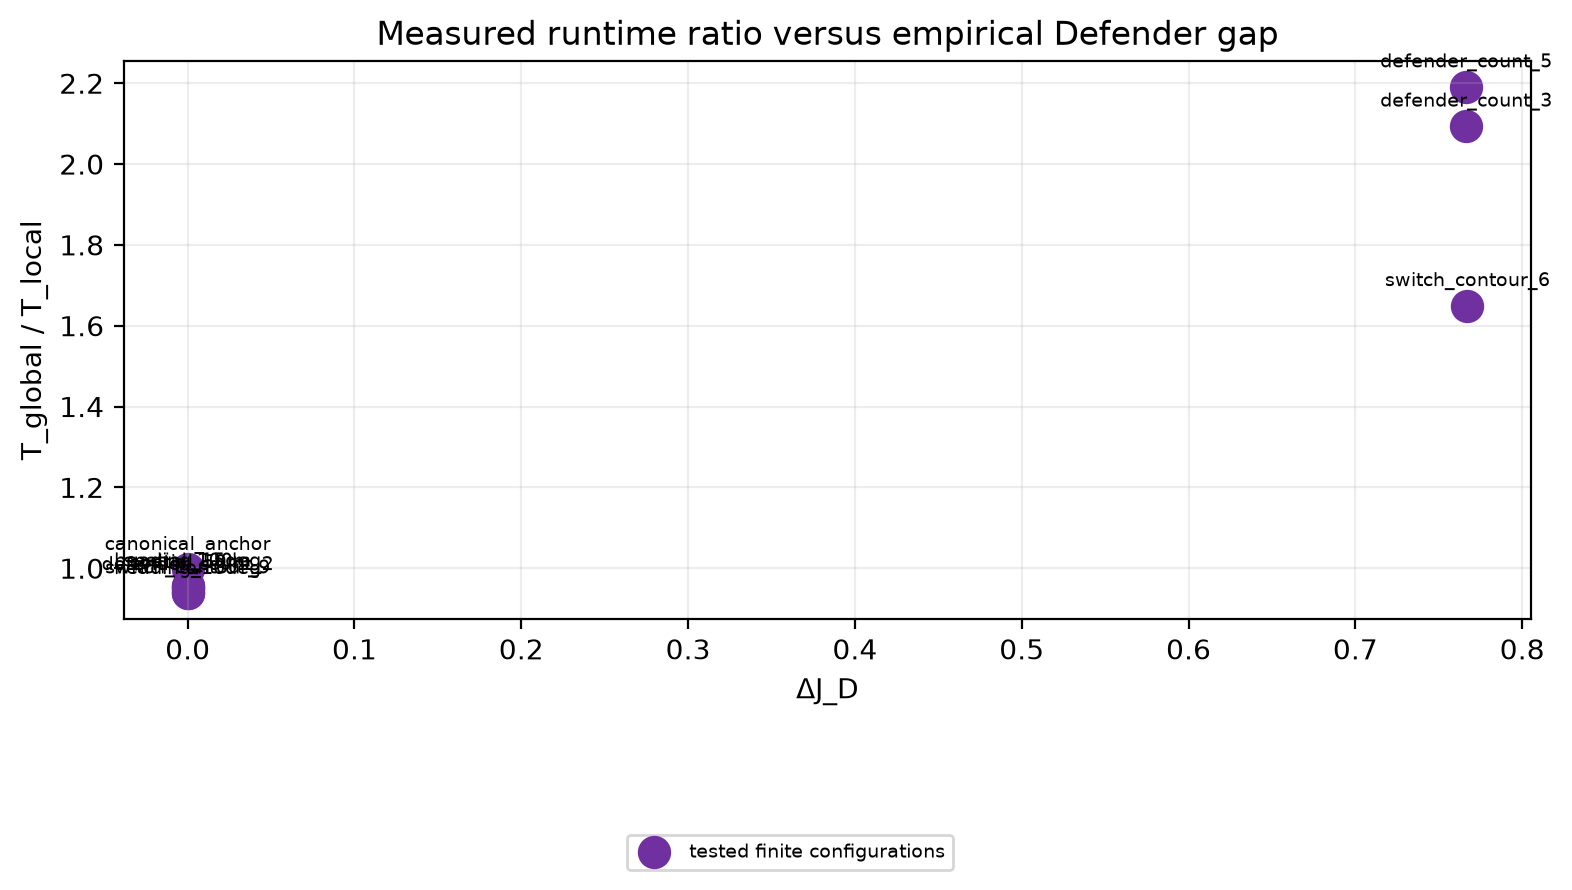

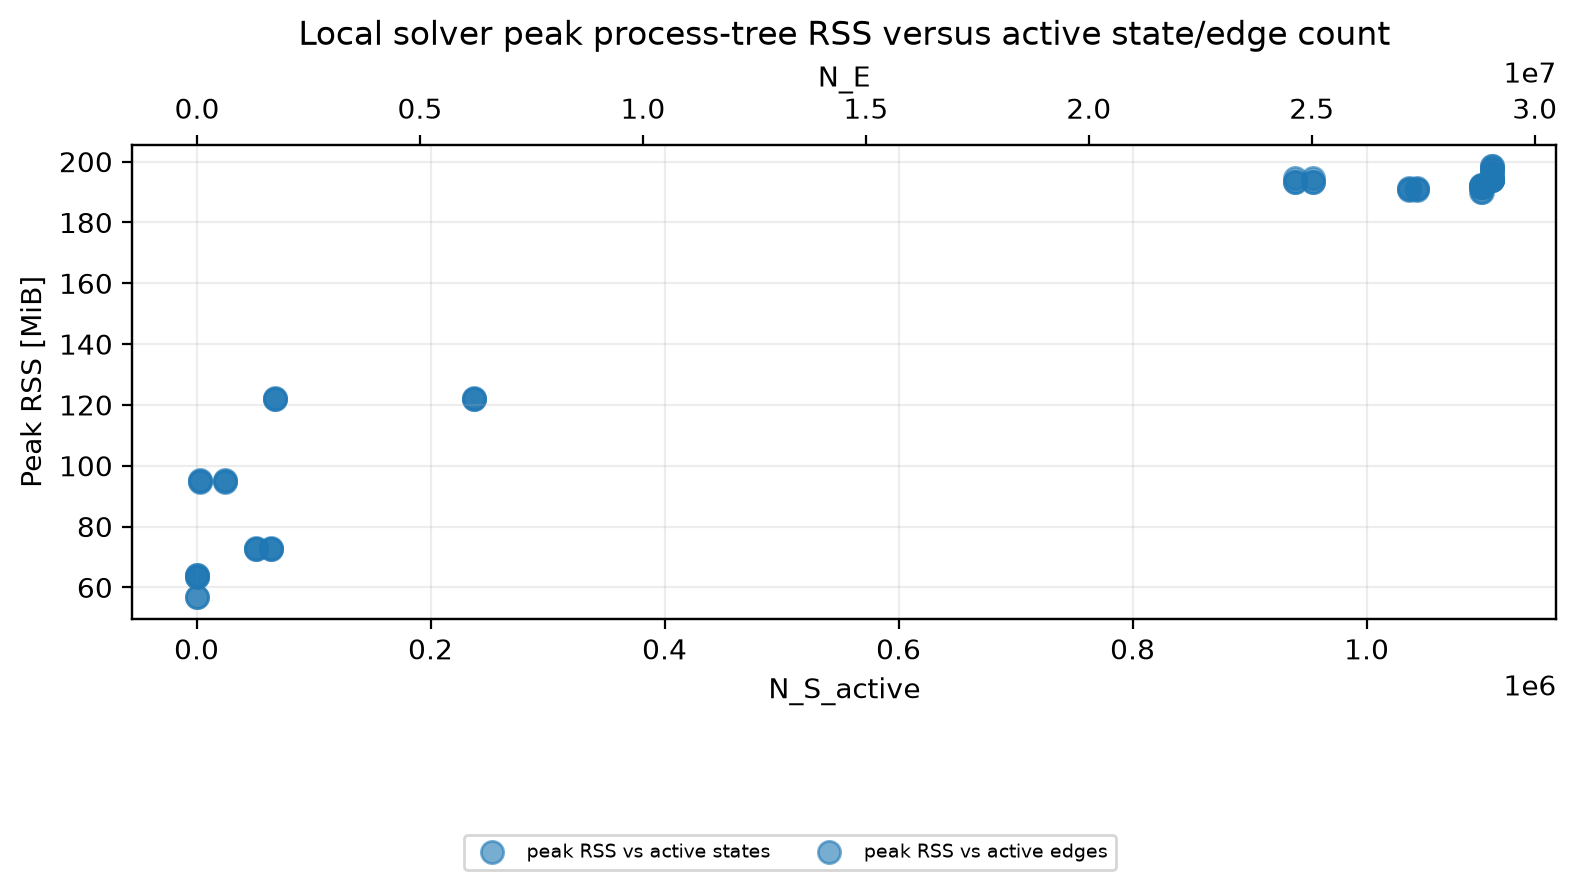

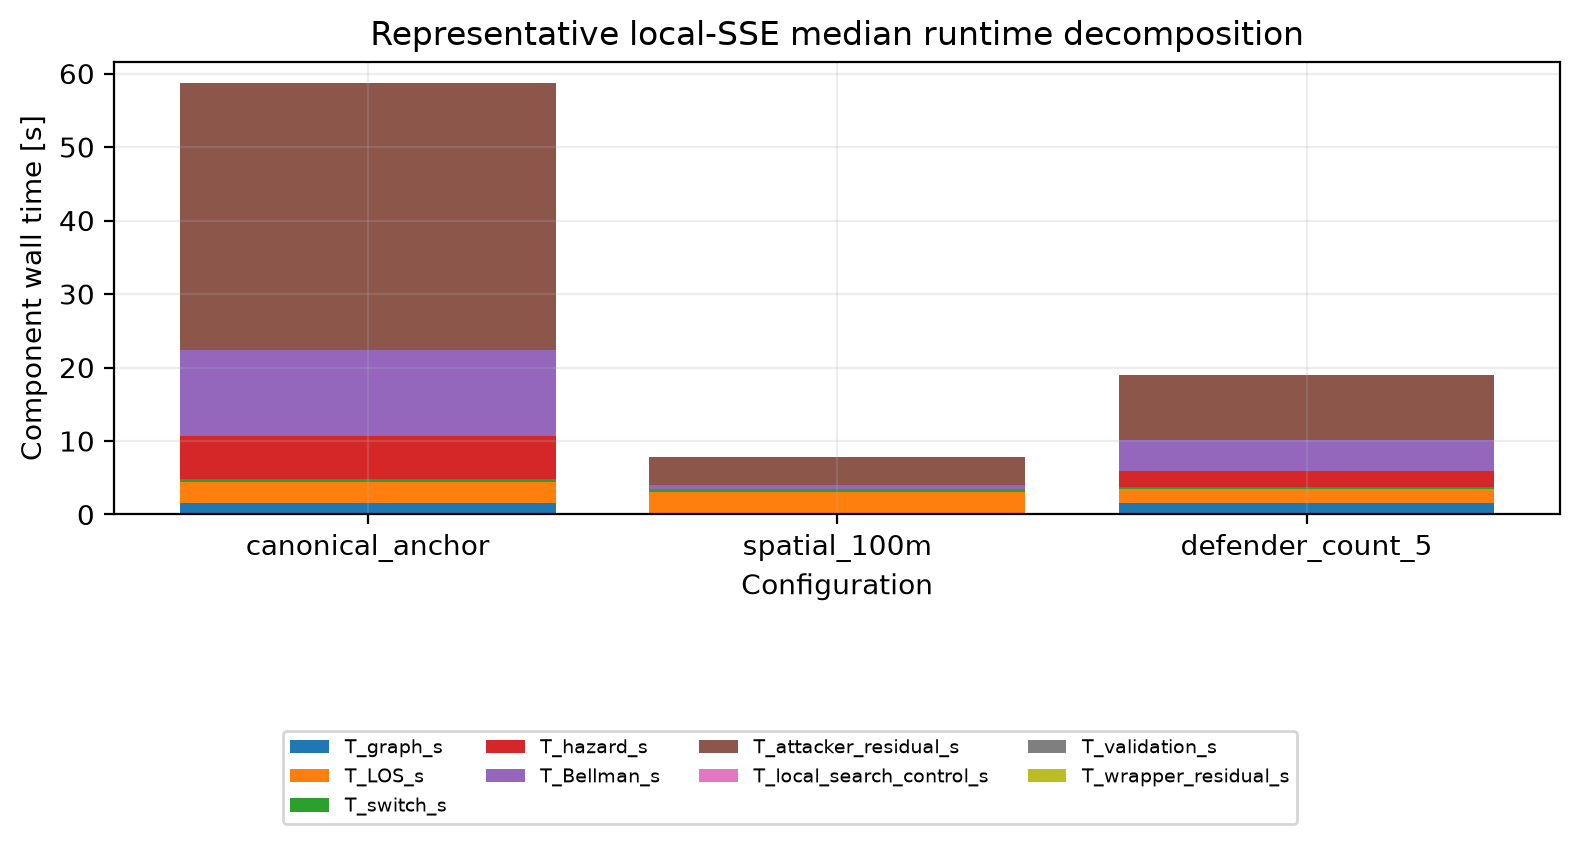

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_2c_local_scaling\raw_repetitions.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_2c_local_scaling\raw_repetitions.jsonl

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_2c_local_scaling\regression_validation_report.json

In [14]:
stage14_2c_figures = stage14_2c_summary['figure_files']
display(HTML('<h4>Static Stage 14.2C figures</h4>'))
for figure_name in stage14_2c_figures:
    display(HTML(f'<h5>{figure_name}</h5>'))
    display(Image(filename=str(STAGE14_2C_DIR / figure_name)))

display(FileLink(STAGE14_2C_DIR / 'raw_repetitions.csv'))
display(FileLink(STAGE14_2C_DIR / 'raw_repetitions.jsonl'))
display(FileLink(STAGE14_2C_DIR / 'regression_validation_report.json'))

### Interpretation boundary

- Local certification, computational scaling, and global-oracle gap are separate claims.
- A small measured gap is not a proven error bound.
- Multi-start is not performed and cannot be called global optimization.
- No RL, approximate planner, or terrain-complexity sweep is included.

## Stage 14.3 — one-variable spatial-resolution sweep

This section varies only `Delta x = Delta y = Delta h`. The centered-cube
mission, 5-degree heading grid, switching density, quadrature, Defender set,
and exact tie rules remain fixed. The preserved global finite-SSE solver is
shown only as an exact oracle/reference path. Local-SSE infeasibility at finer
single-start cases remains explicitly recorded rather than relabeled.

In [15]:
if RECOMPUTE_STAGE14_3:
    stage14_3_summary = run_stage14_3_diagnostics(STAGE14_3_DIR, force=True)
else:
    summary_path = STAGE14_3_DIR / 'stage14_3_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError('Stage 14.3 artifact is absent; set RECOMPUTE_STAGE14_3=True.')
    stage14_3_summary = load_json(summary_path)

stage14_3_validation = load_json(STAGE14_3_DIR / 'stage14_3_validation_report.json')
display_record({
    'gate_passed': stage14_3_summary['gate_passed'],
    'resolutions_m': stage14_3_summary['resolutions_m'],
    'reused_repetitions': stage14_3_summary['reused_repetition_count'],
    'new_repetitions': stage14_3_summary['new_repetition_count'],
    'total_repetitions': stage14_3_summary['total_repetition_count'],
    'finer_outcome': stage14_3_summary['finer_resolution_outcome'],
    'next_stage_started': stage14_3_summary['next_stage_started'],
})

gate_passed,True
resolutions_m,"[100.0, 50.0, 33.333333333333336, 25.0, 20.0, 16.666666666666668, 14.285714285714286, 12.5, 11.11111111111111, 10.0, 9.090909090909092, 8.333333333333334, 7.6923076923076925, 7.142857142857143, 6.666666666666667, 6.25, 5.882352941176471, 5.555555555555555, 5.2631578947368425, 5.0]"
reused_repetitions,0
new_repetitions,120
total_repetitions,120
finer_outcome,"{'attempted_resolutions_m': [5.0, 5.2631578947368425, 5.555555555555555, 5.882352941176471, 6.25, 6.666666666666667, 7.142857142857143, 7.6923076923076925, 8.333333333333334, 9.090909090909092, 10.0, 11.11111111111111, 12.5, 14.285714285714286, 16.666666666666668, 20.0], 'completed': True, 'completed_resolutions_m': [11.11111111111111, 12.5, 14.285714285714286, 16.666666666666668, 20.0], 'computational_limit': True, 'computational_limit_resolutions_m': [5.0, 5.2631578947368425, 5.555555555555555, 5.882352941176471, 6.25, 6.666666666666667, 7.142857142857143, 7.6923076923076925, 8.333333333333334, 9.090909090909092, 10.0], 'global_oracle_status_counts': {'completed': 15, 'memory_limit': 24, 'timeout': 9}, 'local_sse_status_counts': {'completed': 24, 'memory_limit': 24}}"
next_stage_started,False


In [16]:
stage14_3_rows = load_json(STAGE14_3_DIR / 'spatial_sweep_summaries.json')
table_rows = []
for row in stage14_3_rows:
    components = row['runtime_component_statistics_s']
    med = lambda key: None if components.get(key) is None else round(components[key]['median'], 4)
    identity = row['solution_identities'][0] if row['solution_identities'] else (None,) * 5
    table_rows.append([
        row['algorithm_variant'], row['resolution_m'],
        None if row['T_SSE_statistics_s'] is None else round(row['T_SSE_statistics_s']['median'], 4),
        med('T_LOS_s'), med('T_graph_s'), med('T_hazard_s'), med('T_switch_s'), med('T_Bellman_s'),
        None if row['peak_rss_statistics_bytes'] is None else round(row['peak_rss_statistics_bytes']['median'] / 1024**2, 2),
        None if row['J_A_statistics'] is None else row['J_A_statistics']['median'],
        None if row['J_D_statistics'] is None else row['J_D_statistics']['median'],
        identity[0], identity[1], None if identity[4] is None else identity[4][:10],
    ])
display(HTML(
    '<table><tr><th>variant</th><th>Delta xyz [m]</th><th>T_SSE</th><th>T_LOS</th>'
    '<th>T_graph</th><th>T_hazard</th><th>T_switch</th><th>T_Bellman</th>'
    '<th>peak RSS [MiB]</th><th>J_A</th><th>J_D</th><th>D ID</th><th>A ID</th><th>trajectory</th></tr>'
    + ''.join('<tr>' + ''.join(f'<td>{value}</td>' for value in values) + '</tr>' for values in table_rows)
    + '</table><style>th,td{border:1px solid #bbb;padding:4px 7px}</style>'
))

variant,Delta xyz [m],T_SSE,T_LOS,T_graph,T_hazard,T_switch,T_Bellman,peak RSS [MiB],J_A,J_D,D ID,A ID,trajectory
local_sse,25.0,83.615,4.9631,1.6367,8.6033,0.6917,9.1493,198.94,7.1945895064610585,0.9999991723787202,3,27,643ae13a42
local_sse,100.0,18.9448,4.9498,0.1941,0.1805,0.7002,0.9257,68.6,63.86782470065451,1.0,3,26,94df90c006
local_sse,50.0,62.1884,5.0071,0.5521,0.9921,0.7782,3.5769,78.46,72.13139995237101,1.0,3,26,db43cc7cf9
global_oracle,25.0,97.5437,6.0148,1.6305,10.173,0.7897,10.9359,200.0,7.1945895064610585,0.9999991723787202,3,27,643ae13a42
global_oracle,100.0,23.3746,6.017,0.1776,0.2216,0.862,1.0554,68.11,63.86782470065451,1.0,3,26,94df90c006
global_oracle,50.0,75.8476,5.9985,0.5262,1.1806,0.9537,4.4158,82.02,72.13139995237101,1.0,3,26,db43cc7cf9
local_sse,33.333333333333336,59.2504,5.2536,1.1264,2.5745,0.6799,5.0688,116.73,67.61603334794576,1.0,3,25,c1a34322dc
global_oracle,33.333333333333336,76.2615,6.3299,1.0905,3.2698,0.8189,6.2272,119.51,67.61603334794576,1.0,3,25,c1a34322dc
local_sse,20.0,40.3472,4.3529,2.6918,4.9936,0.5128,4.2197,322.48,0.3130444517693126,0.20388511678312862,2,37,f80ef3e06b
global_oracle,20.0,305.6812,32.93,2.5042,36.126,3.8213,37.1545,324.91,0.3130444517693126,0.20388511678312862,2,37,f80ef3e06b


### Stage 14.3 shared resolution-sweep figure guide

The spatial grid scale `Delta x = Delta y = Delta h` is the controlled x-axis.
Stages 14.3--14.6 use the same six-figure performance/solution schema; only the
controlled x-axis changes. Certified local SSE is solid and the completed exact
global finite solver is a dashed oracle/reference.

1. **Total SSE runtime** (`T_SSE`).
2. **Runtime decomposition** using the same LOS, graph/reachability, hazard,
   switching, Bellman, and residual components for both solver variants.
3. **Peak process-tree memory** (RSS).
4. **Equilibrium objectives** (`J_A`, `J_D`).
5. **Selected finite equilibrium** (Defender action and Attacker candidate).
6. **Selected trajectory identity** (exact hash) and switching-point coordinates.

State/edge growth is retained only in raw/tabular audit artifacts; it is not a
primary performance figure.

`Individual isolated-process runs (n=3)` means a newly launched Python worker
for each repetition, not guaranteed-cold operating-system or hardware caches.
Any infeasible, timeout, memory-limit, or worker-failure result remains explicit
in the table/validation artifacts; missing points are not relabeled as successful
measurements.

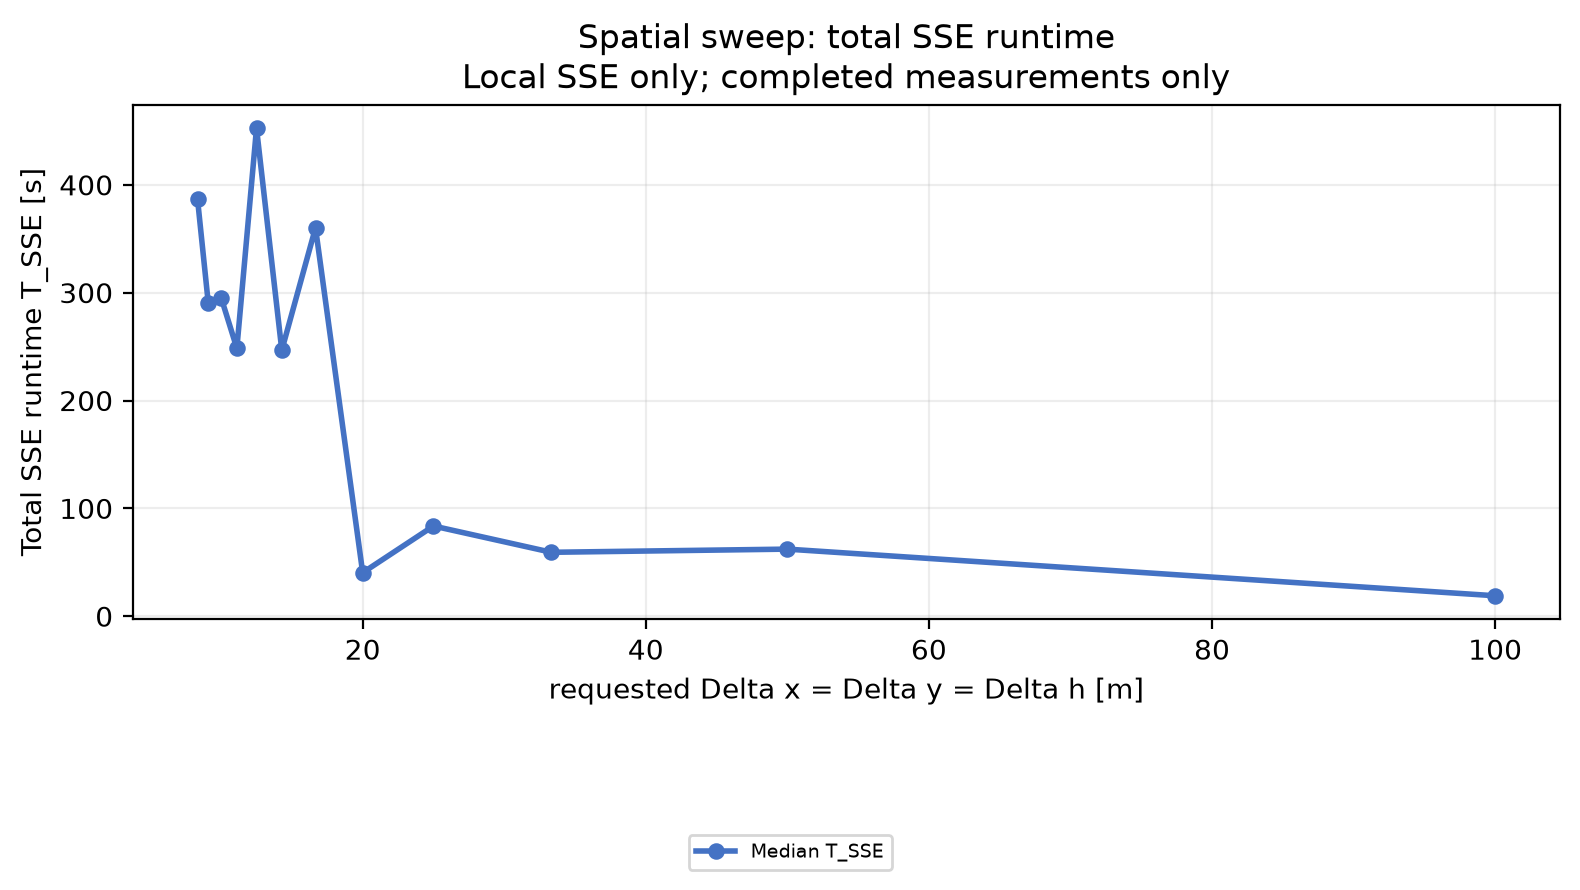

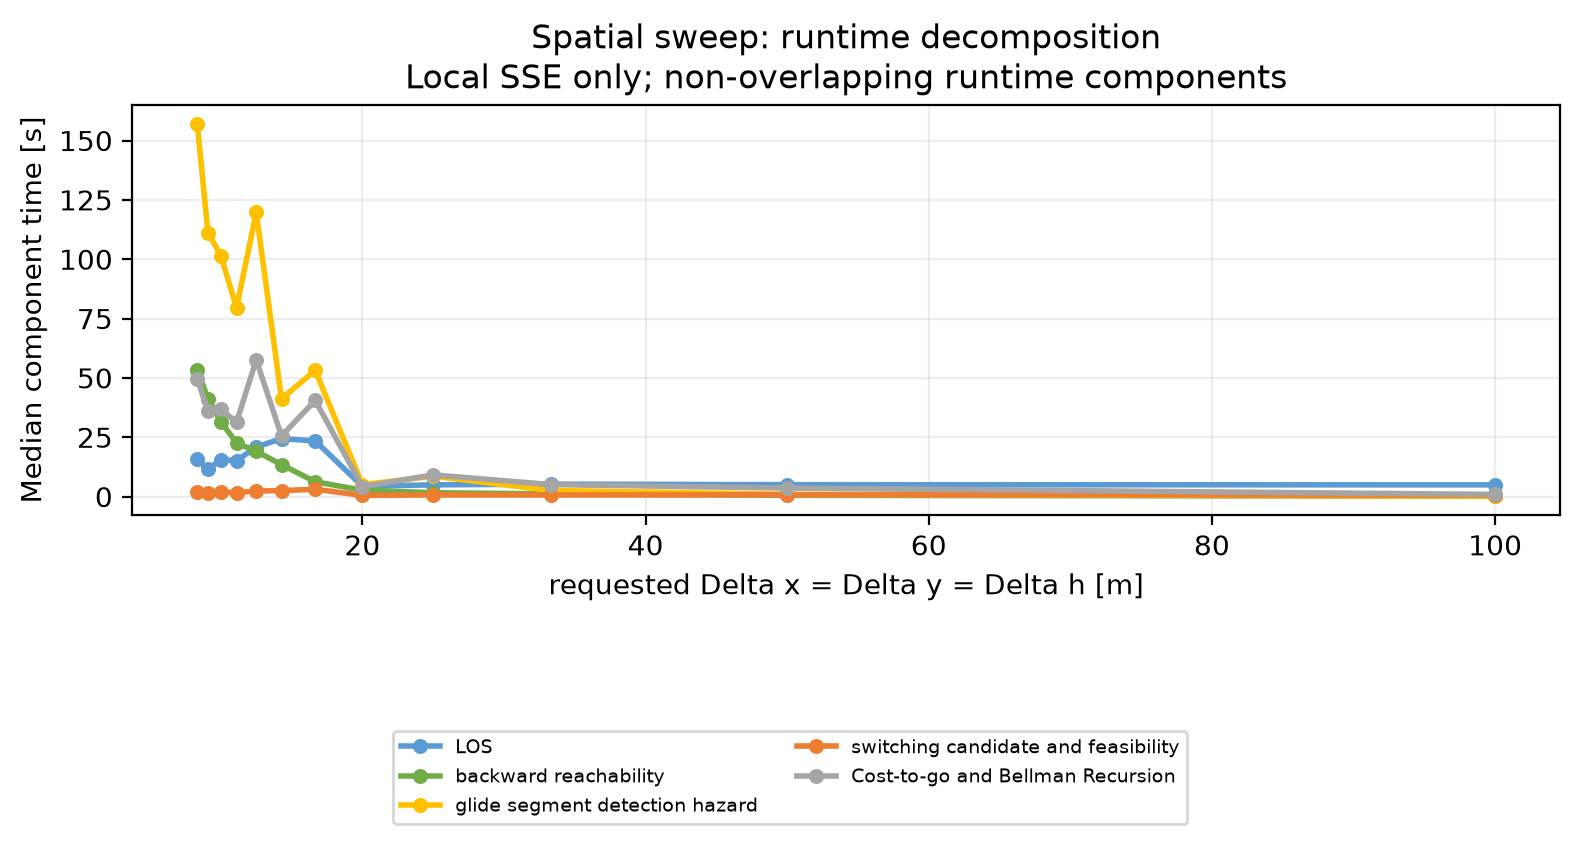

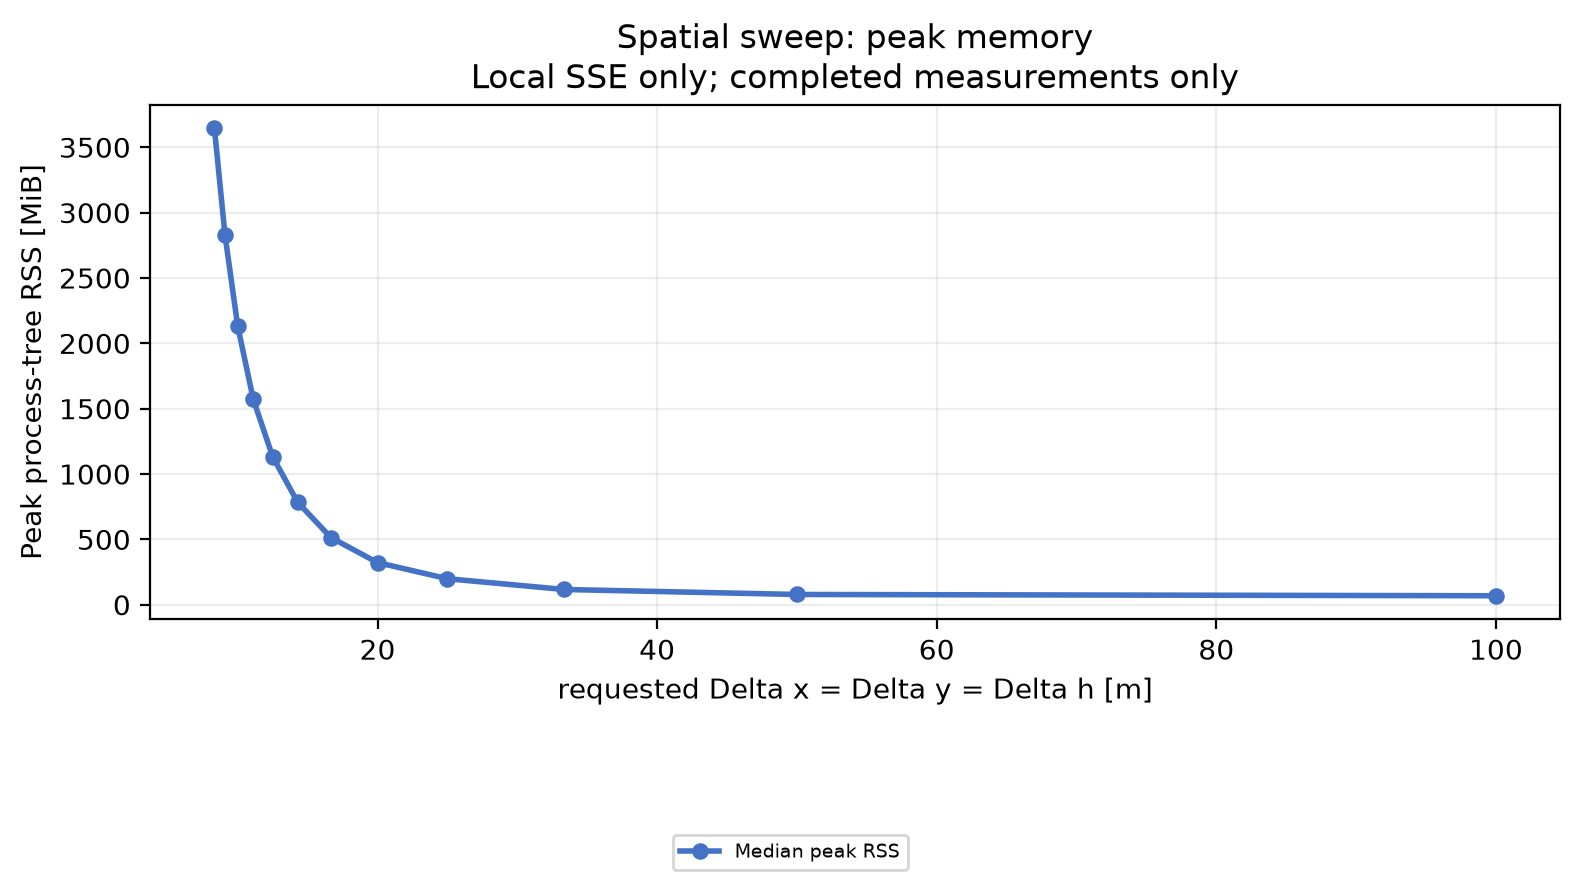

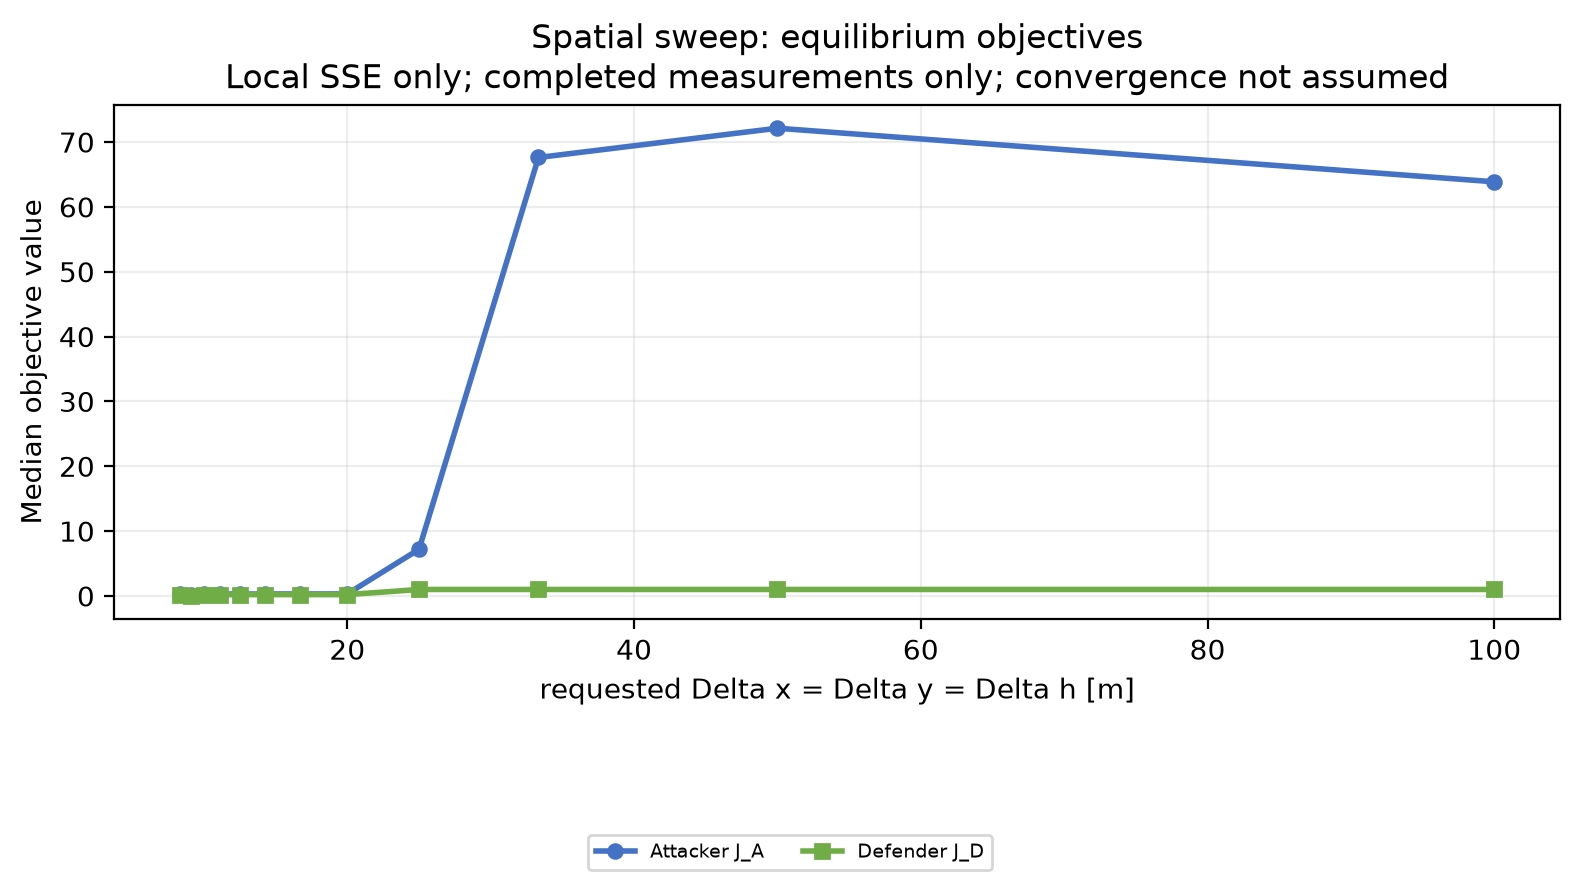

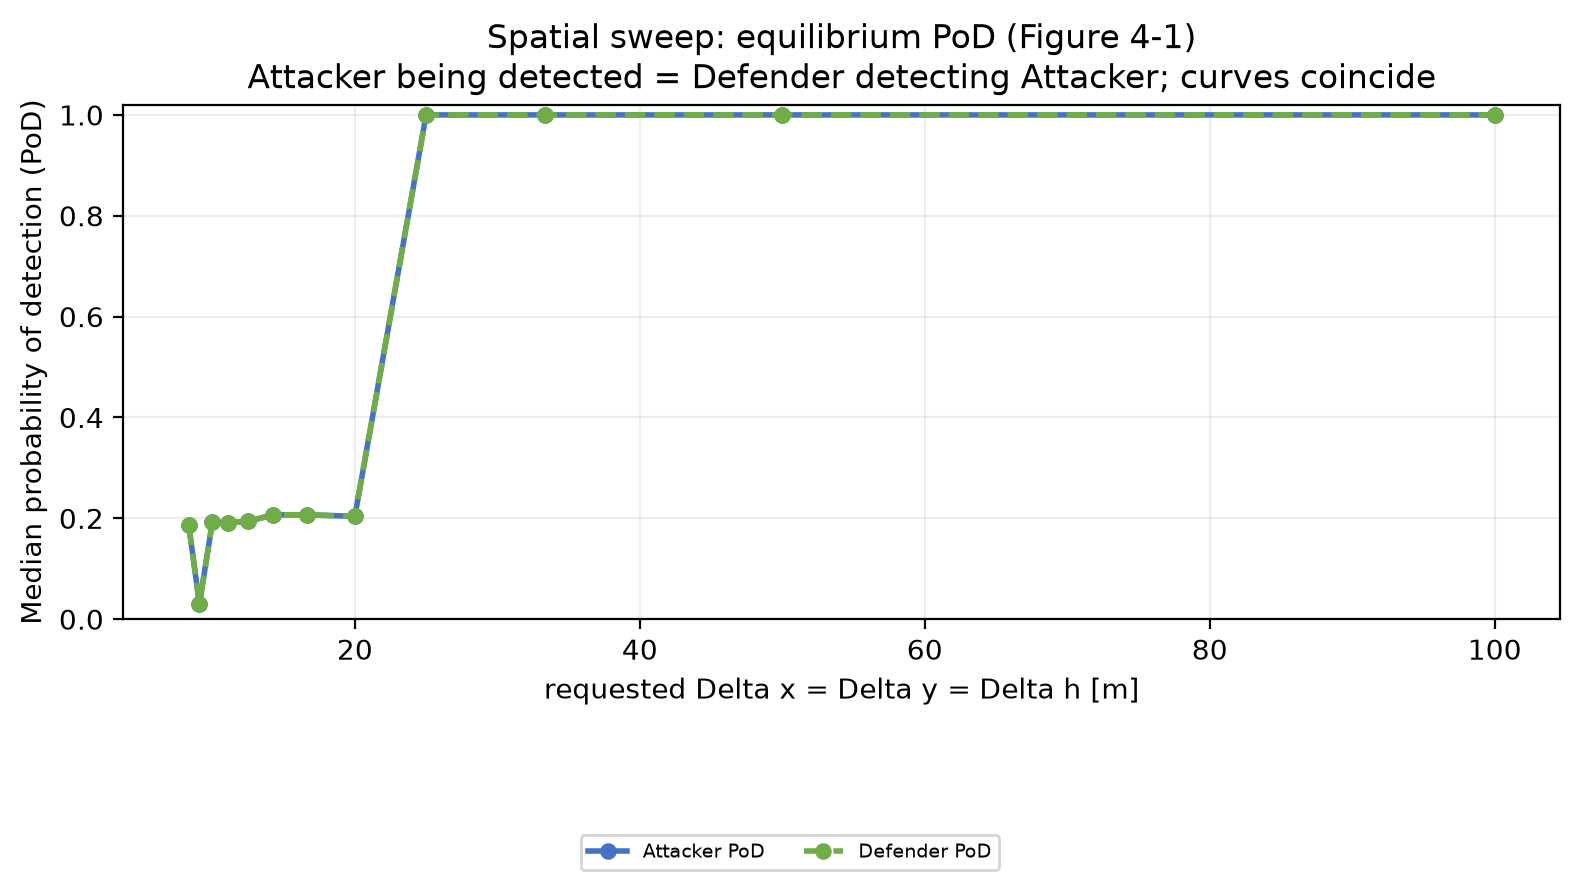

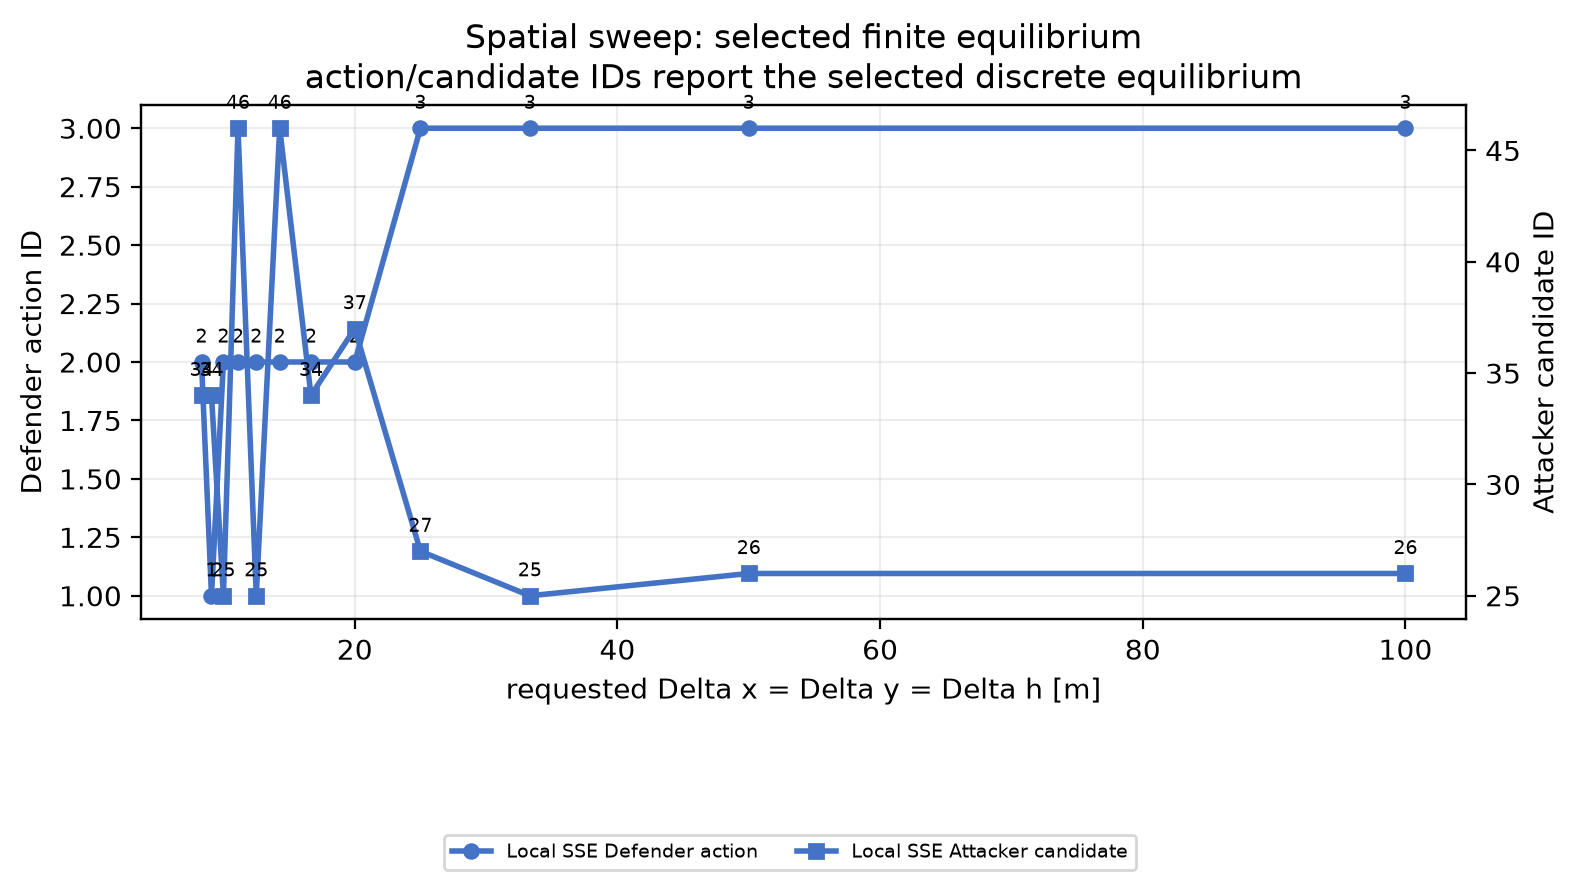

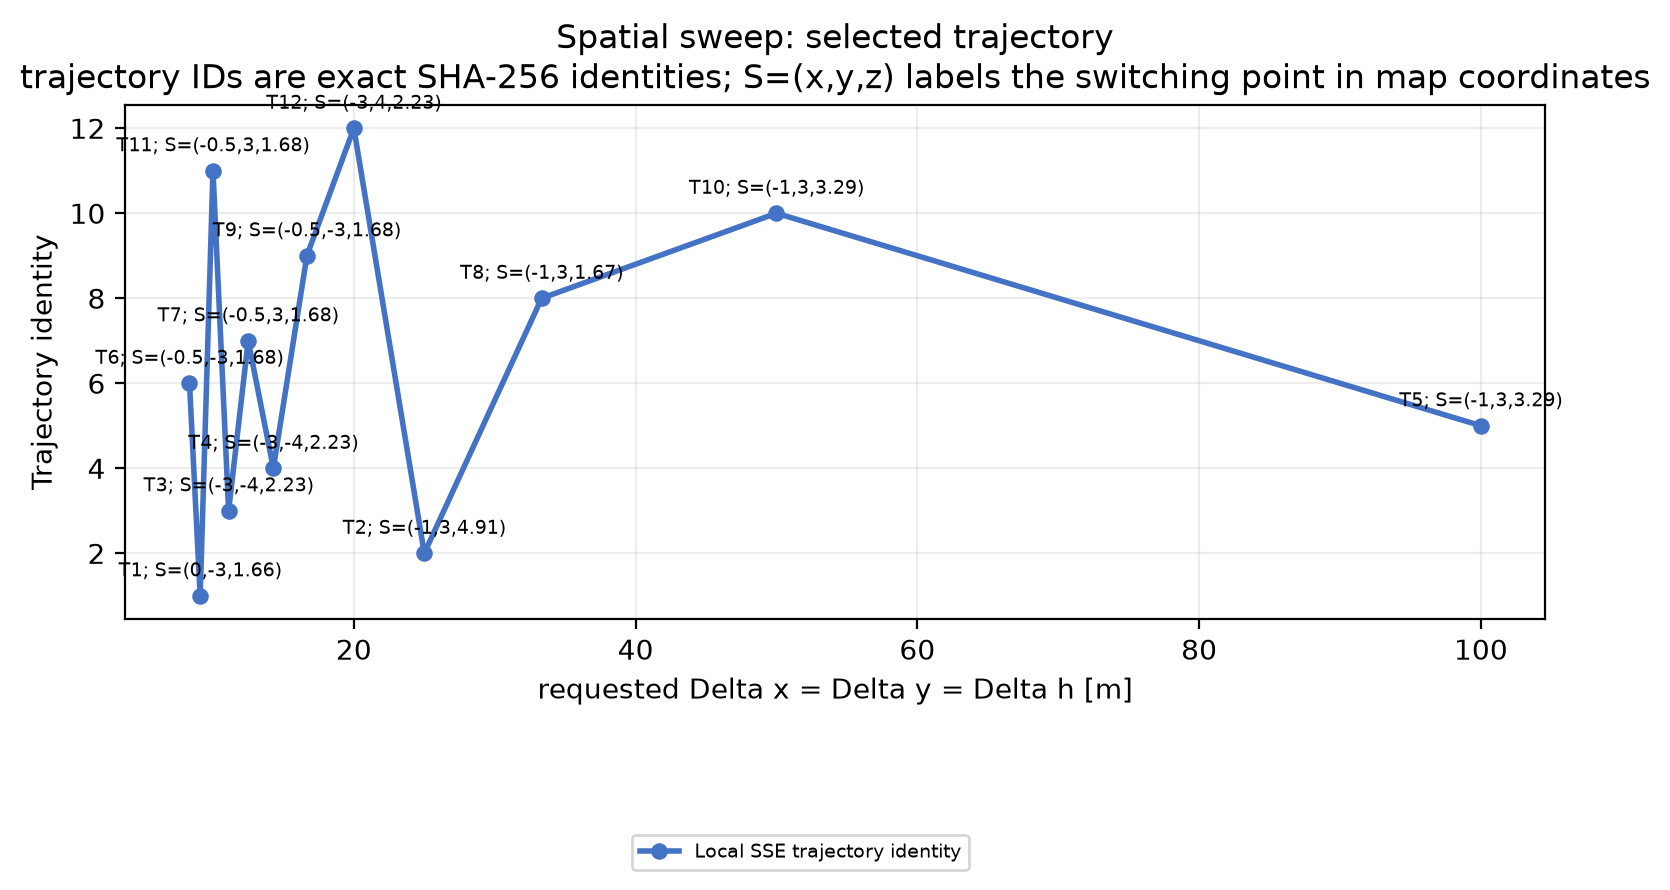

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_3_spatial_resolution\raw_spatial_repetitions.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_3_spatial_resolution\raw_spatial_repetitions.jsonl

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_3_spatial_resolution\stage14_3_validation_report.json

In [17]:
display(HTML('<h4>Static Stage 14.3 figures</h4>'))
for figure_name in stage14_3_summary['figure_files']:
    display(HTML(f'<h5>{figure_name}</h5>'))
    display(Image(filename=str(STAGE14_3_DIR / figure_name)))

display(FileLink(STAGE14_3_DIR / 'raw_spatial_repetitions.csv'))
display(FileLink(STAGE14_3_DIR / 'raw_spatial_repetitions.jsonl'))
display(FileLink(STAGE14_3_DIR / 'stage14_3_validation_report.json'))

### Stage 14.3 interpretation boundary

- Completed exact global-SSE results are oracle/reference measurements, not a
  reversal of the Local-SSE research pivot.
- The 20 m oracle completed; finer Local-SSE `D0` failures are model
  infeasibility, not runtime limits.
- The 12.5 m oracle timing-accounting failure is retained as an explicit
  worker failure and is not plotted as a completed measurement.
- No empirical curve is presented as formal asymptotic Big-O.
- The 20 m Cartesian grid is larger than the 25 m grid, but its reachable/active graph is much smaller; runtime and objective trends are therefore non-monotonic and do not establish convergence.

## Stage 14.4 — one-variable heading-resolution sweep

This section varies only requested heading spacing over 15, 10, 5, and 2.5
degrees. Spatial spacing remains 25 m; terrain, switching density, quadrature,
Defender actions, local-neighborhood radius, physics, objectives, and tie rules
remain fixed. The local SSE is primary and every evaluated Attacker response is
exact over the corresponding finite model.

In [18]:
if RECOMPUTE_STAGE14_4:
    stage14_4_summary = run_stage14_4_diagnostics(STAGE14_4_DIR, force=True)
else:
    summary_path = STAGE14_4_DIR / 'stage14_4_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError('Stage 14.4 artifact is absent; set RECOMPUTE_STAGE14_4=True.')
    stage14_4_summary = load_json(summary_path)

stage14_4_validation = load_json(STAGE14_4_DIR / 'stage14_4_validation_report.json')
display_record({
    'gate_passed': stage14_4_summary['gate_passed'],
    'heading_spacings_deg': stage14_4_summary['heading_spacings_deg'],
    'reused_repetitions': stage14_4_summary['reused_repetition_count'],
    'new_repetitions': stage14_4_summary['new_repetition_count'],
    'total_repetitions': stage14_4_summary['total_repetition_count'],
    'fine_heading_outcome': stage14_4_summary['fine_heading_outcome'],
    'next_stage_started': stage14_4_summary['next_stage_started'],
})

gate_passed,True
heading_spacings_deg,"[45.0, 36.0, 30.0, 22.5, 20.0, 18.0, 15.0, 12.0, 10.0, 9.0, 7.5, 6.0, 5.0, 4.5, 4.0, 3.0, 2.5, 2.0, 1.5, 1.0]"
reused_repetitions,0
new_repetitions,120
total_repetitions,120
fine_heading_outcome,"{'completed': True, 'computational_limit': False, 'heading_spacing_deg': 1.0, 'local_status_counts': {'completed': 3}}"
next_stage_started,False


In [19]:
stage14_4_rows = load_json(STAGE14_4_DIR / 'heading_sweep_summaries.json')
table_rows = []
for row in stage14_4_rows:
    components = row['runtime_component_statistics_s']
    med = lambda key: None if components.get(key) is None else round(components[key]['median'], 4)
    identity = row['solution_identities'][0] if row['solution_identities'] else (None,) * 5
    table_rows.append([
        row['algorithm_variant'], row['heading_spacing_deg'],
        None if row['T_SSE_statistics_s'] is None else round(row['T_SSE_statistics_s']['median'], 4),
        med('T_LOS_s'), med('T_graph_s'), med('T_hazard_s'), med('T_switch_s'), med('T_Bellman_s'),
        None if row['peak_rss_statistics_bytes'] is None else round(row['peak_rss_statistics_bytes']['median'] / 1024**2, 2),
        None if row['J_A_statistics'] is None else row['J_A_statistics']['median'],
        None if row['J_D_statistics'] is None else row['J_D_statistics']['median'],
        identity[0], identity[1], None if identity[4] is None else identity[4][:10],
    ])
display(HTML(
    '<table><tr><th>variant</th><th>Delta psi [deg]</th><th>T_SSE</th><th>T_LOS</th>'
    '<th>T_graph</th><th>T_hazard</th><th>T_switch</th><th>T_Bellman</th>'
    '<th>peak RSS [MiB]</th><th>J_A</th><th>J_D</th><th>D ID</th><th>A ID</th><th>trajectory</th></tr>'
    + ''.join('<tr>' + ''.join(f'<td>{value}</td>' for value in values) + '</tr>' for values in table_rows)
    + '</table><style>th,td{border:1px solid #bbb;padding:4px 7px}</style>'
))

variant,Delta psi [deg],T_SSE,T_LOS,T_graph,T_hazard,T_switch,T_Bellman,peak RSS [MiB],J_A,J_D,D ID,A ID,trajectory
local_sse,5.0,80.9611,4.8413,1.5848,8.2932,0.6732,8.6583,198.18,7.1945895064610585,0.9999991723787202,3,27,643ae13a42
local_sse,15.0,7.1324,4.7927,0.1058,0.2221,0.5151,0.1696,95.43,9.649314970197922,0.9999999937978457,3,27,dc3bca7544
local_sse,10.0,17.5373,4.845,0.3027,1.9128,0.5496,1.0182,123.5,8.8809260619725,0.9999999709805552,3,27,49f60c20ec
global_oracle,5.0,95.0997,5.8446,1.5657,9.6636,0.7855,10.481,200.18,7.1945895064610585,0.9999991723787202,3,27,643ae13a42
global_oracle,15.0,8.9452,5.9758,0.1073,0.2677,0.6386,0.205,96.16,9.649314970197922,0.9999999937978457,3,27,dc3bca7544
global_oracle,10.0,20.6158,5.7745,0.2945,2.3074,0.6576,1.2382,123.89,8.8809260619725,0.9999999709805552,3,27,49f60c20ec
local_sse,45.0,None,None,None,None,None,None,None,None,None,None,None,None
global_oracle,45.0,None,None,None,None,None,None,None,None,None,None,None,None
local_sse,36.0,None,None,None,None,None,None,None,None,None,None,None,None
global_oracle,36.0,None,None,None,None,None,None,None,None,None,None,None,None


### Stage 14.4 shared resolution-sweep figure guide

The requested heading resolution `Delta psi [deg]` is the controlled x-axis.
Realized `N_psi` remains in the summary table and machine-readable metadata
for reproducibility, but is not repeated on the plots because
`N_psi = 360 deg / realized Delta psi`. Stages 14.3--14.6 use the same
six-figure performance/solution schema; only the controlled x-axis changes.
Certified local SSE is solid and the exact global finite solver is the dashed
oracle/reference.

1. **Total SSE runtime** (`T_SSE`).
2. **Runtime decomposition** using the common component schema for both solvers.
3. **Peak process-tree memory** (RSS).
4. **Equilibrium objectives** (`J_A`, `J_D`).
5. **Selected finite equilibrium** (Defender action and Attacker candidate).
6. **Selected trajectory identity** and switching-point coordinates.

Heading-bin/quantization and state/edge diagnostics remain in machine-readable
audit artifacts, not in the primary performance figures.

`Individual isolated-process runs (n=3)` means a fresh Python worker for every
repetition, not guaranteed-cold operating-system or hardware caches. The 15,
10, and 5 degree rows reuse identical Stage-14.2C measurements; all other
declared spacings are Stage-14.4 measurements.

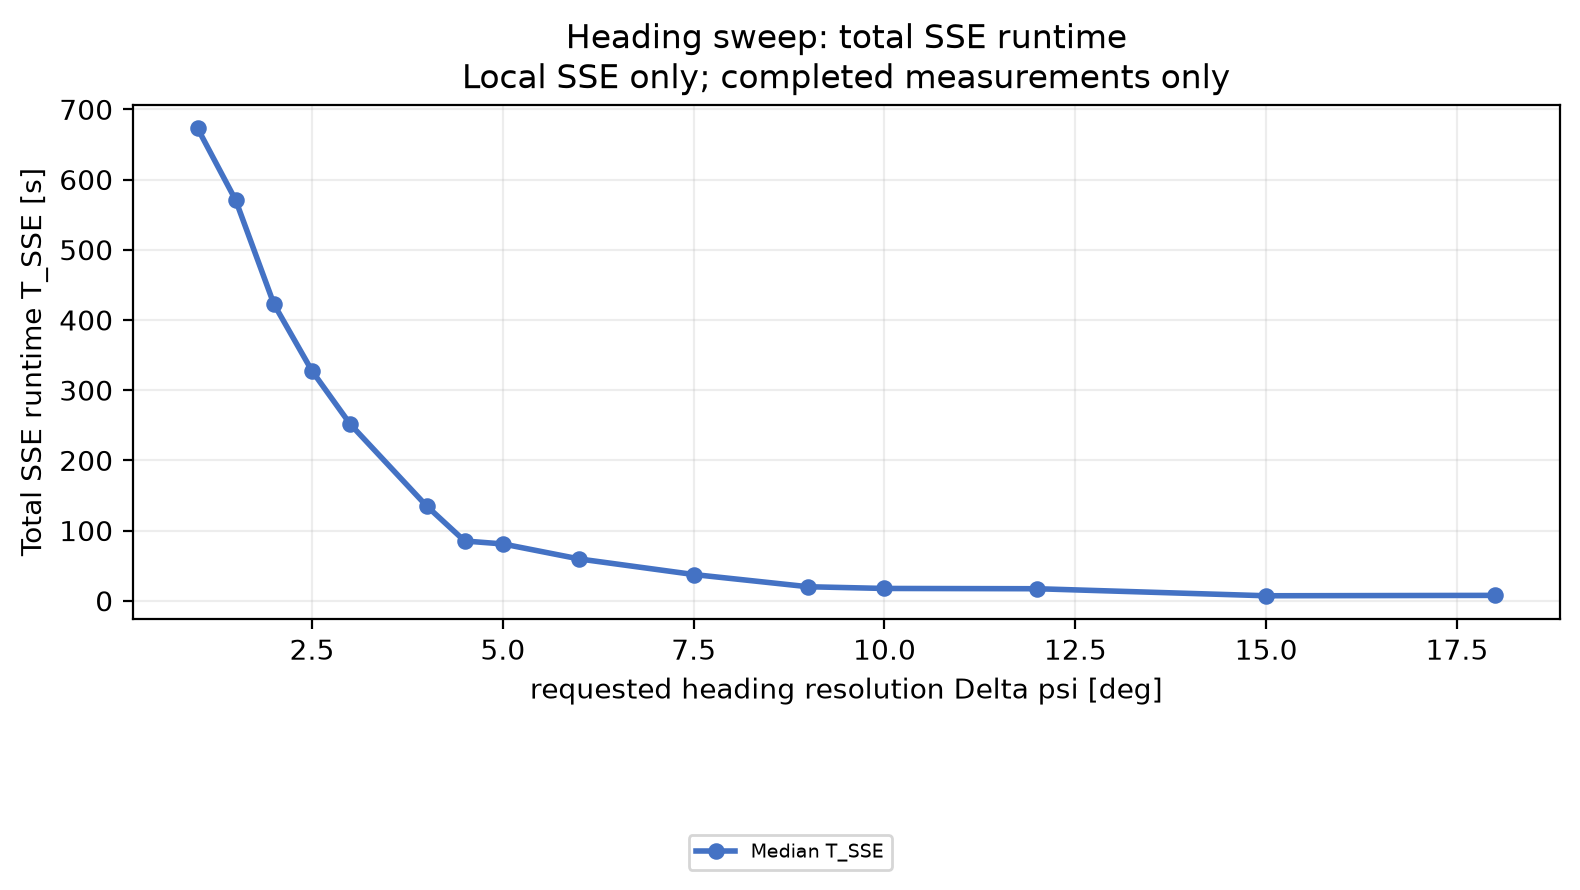

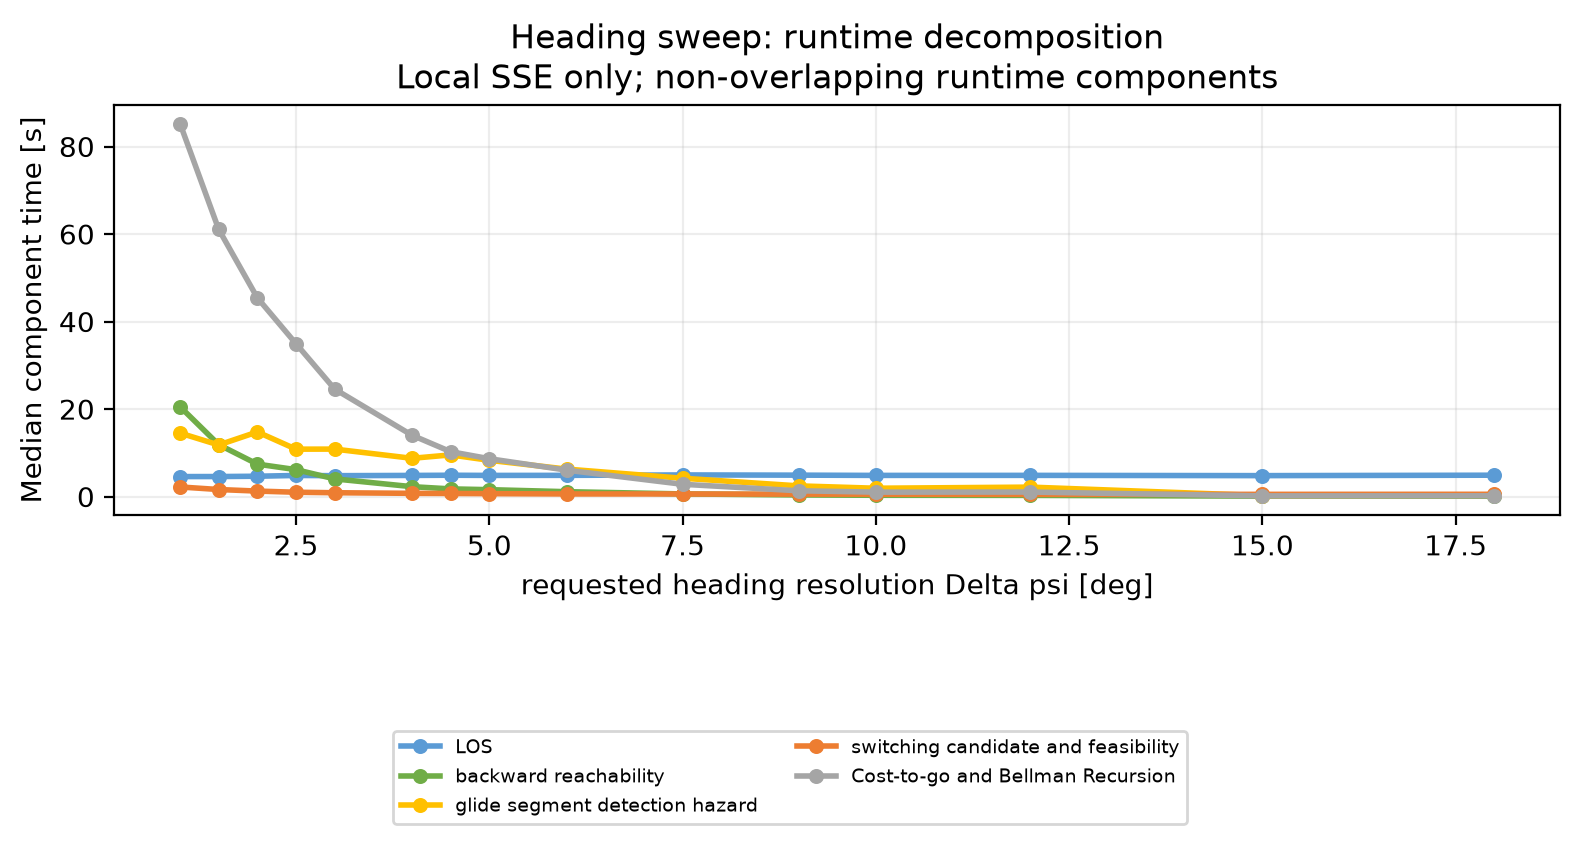

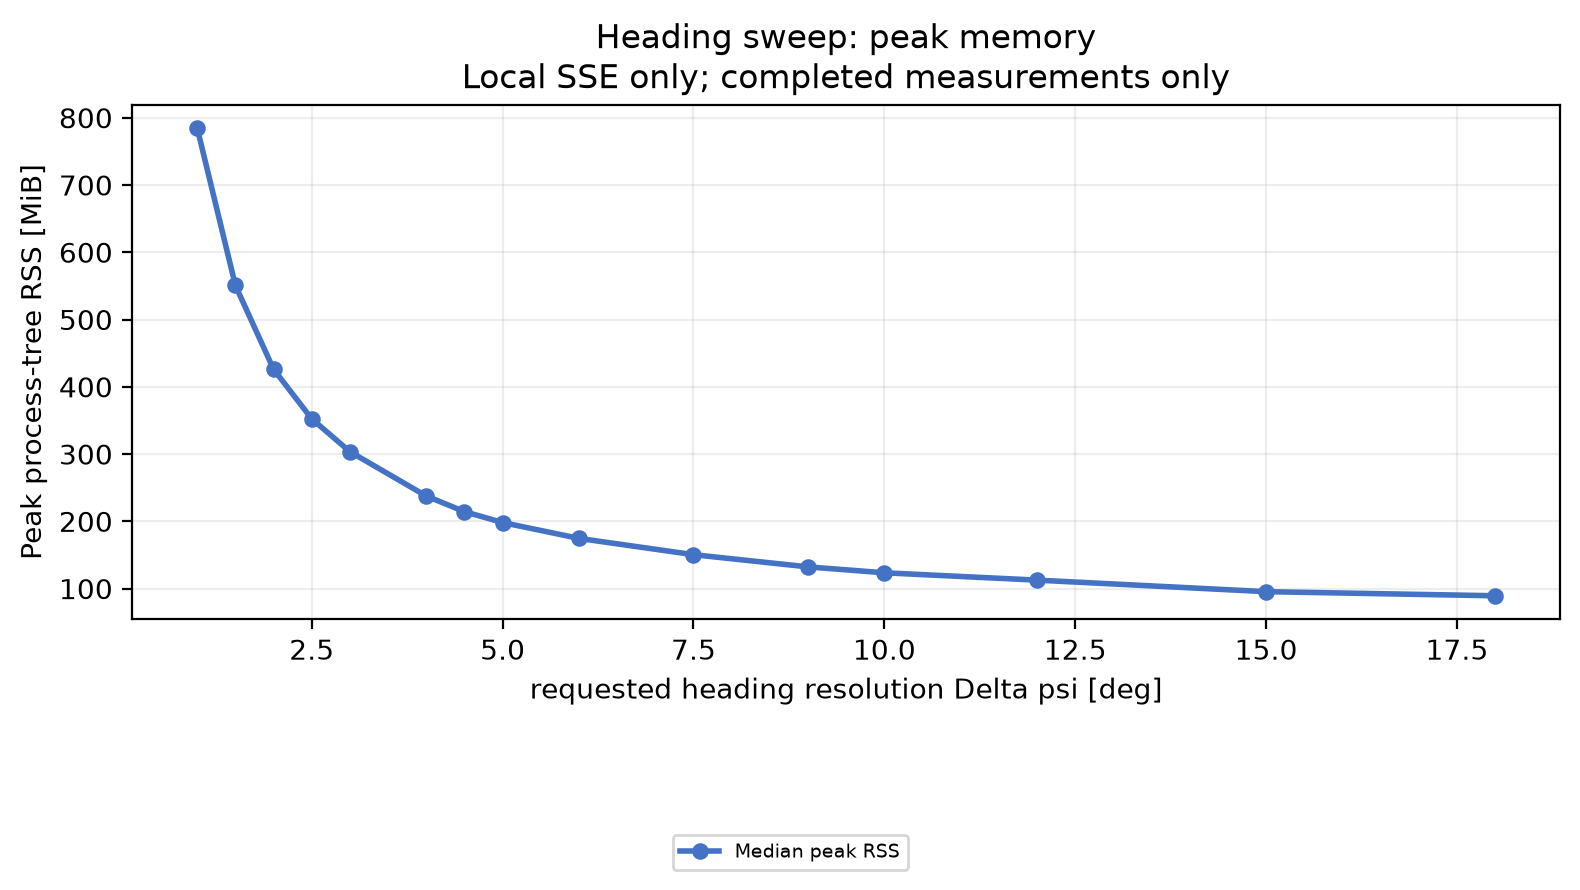

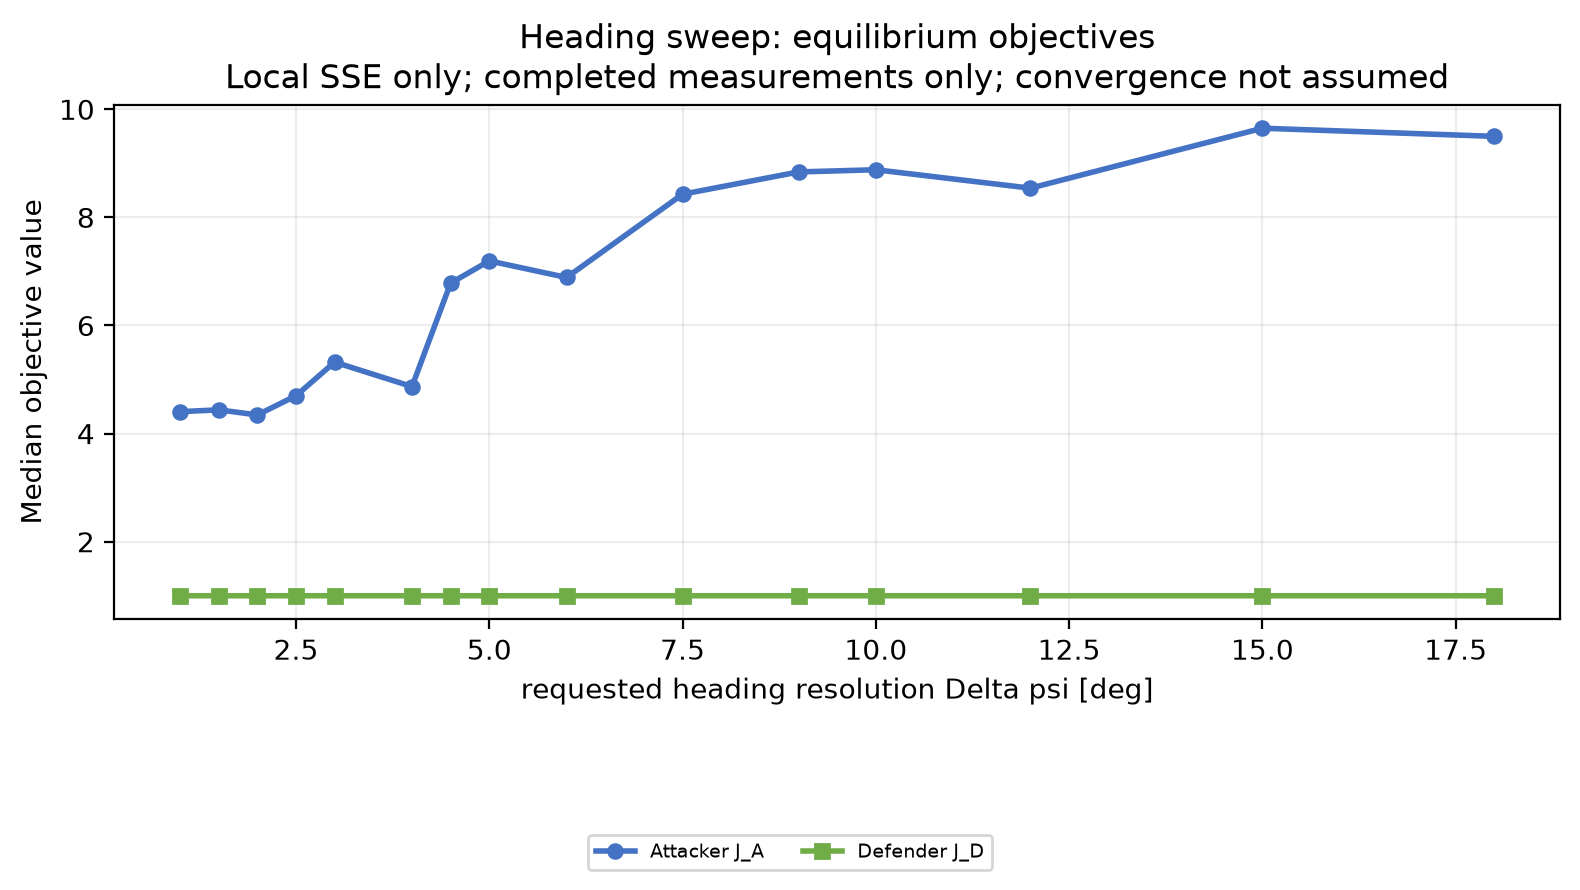

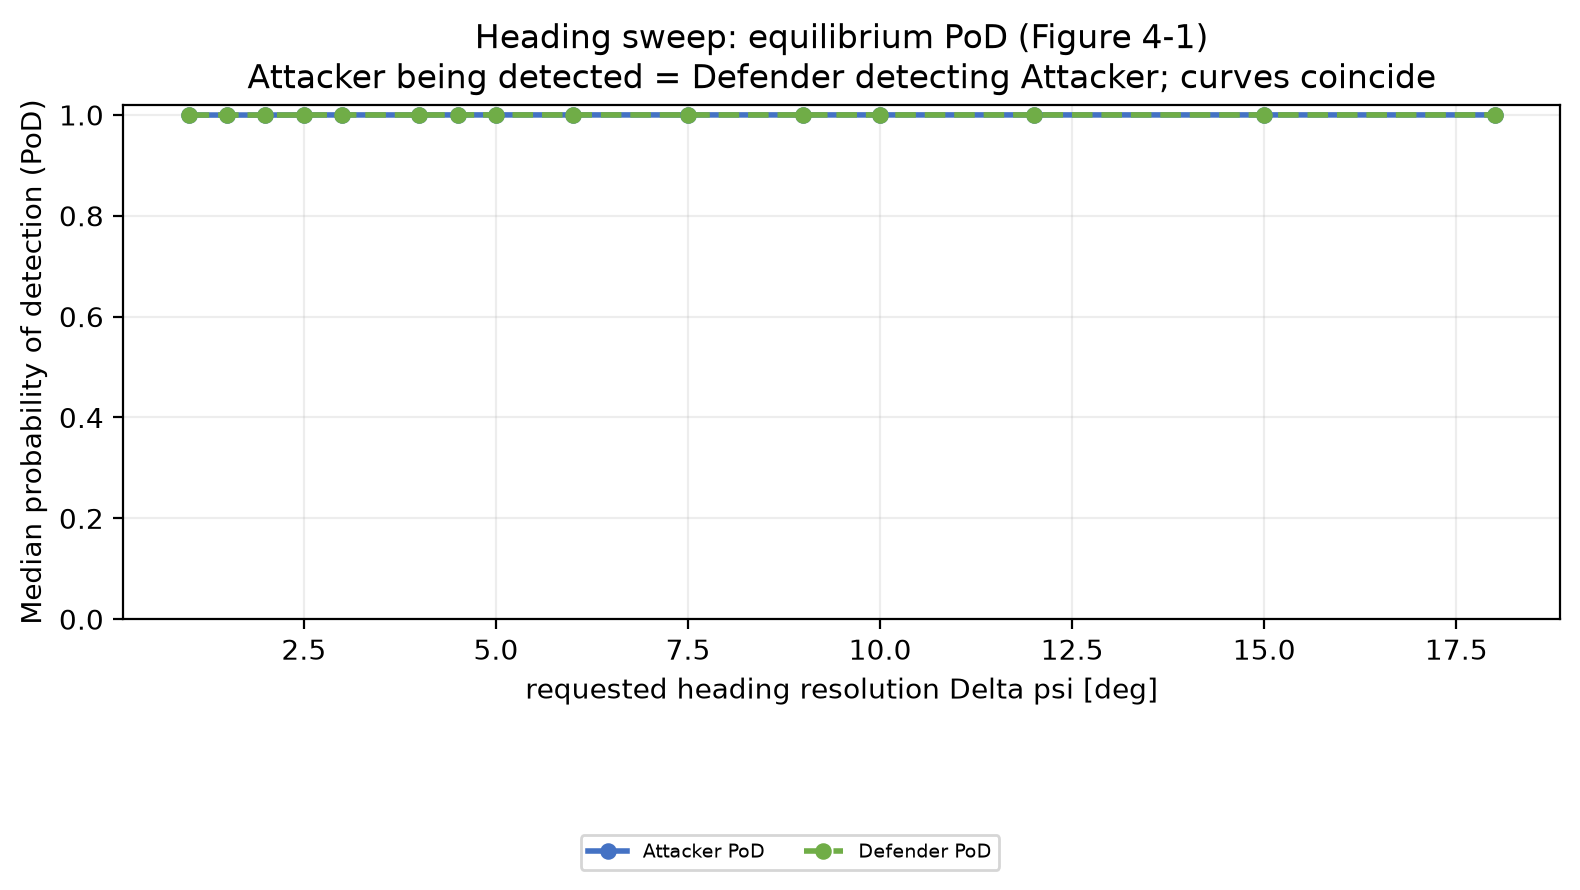

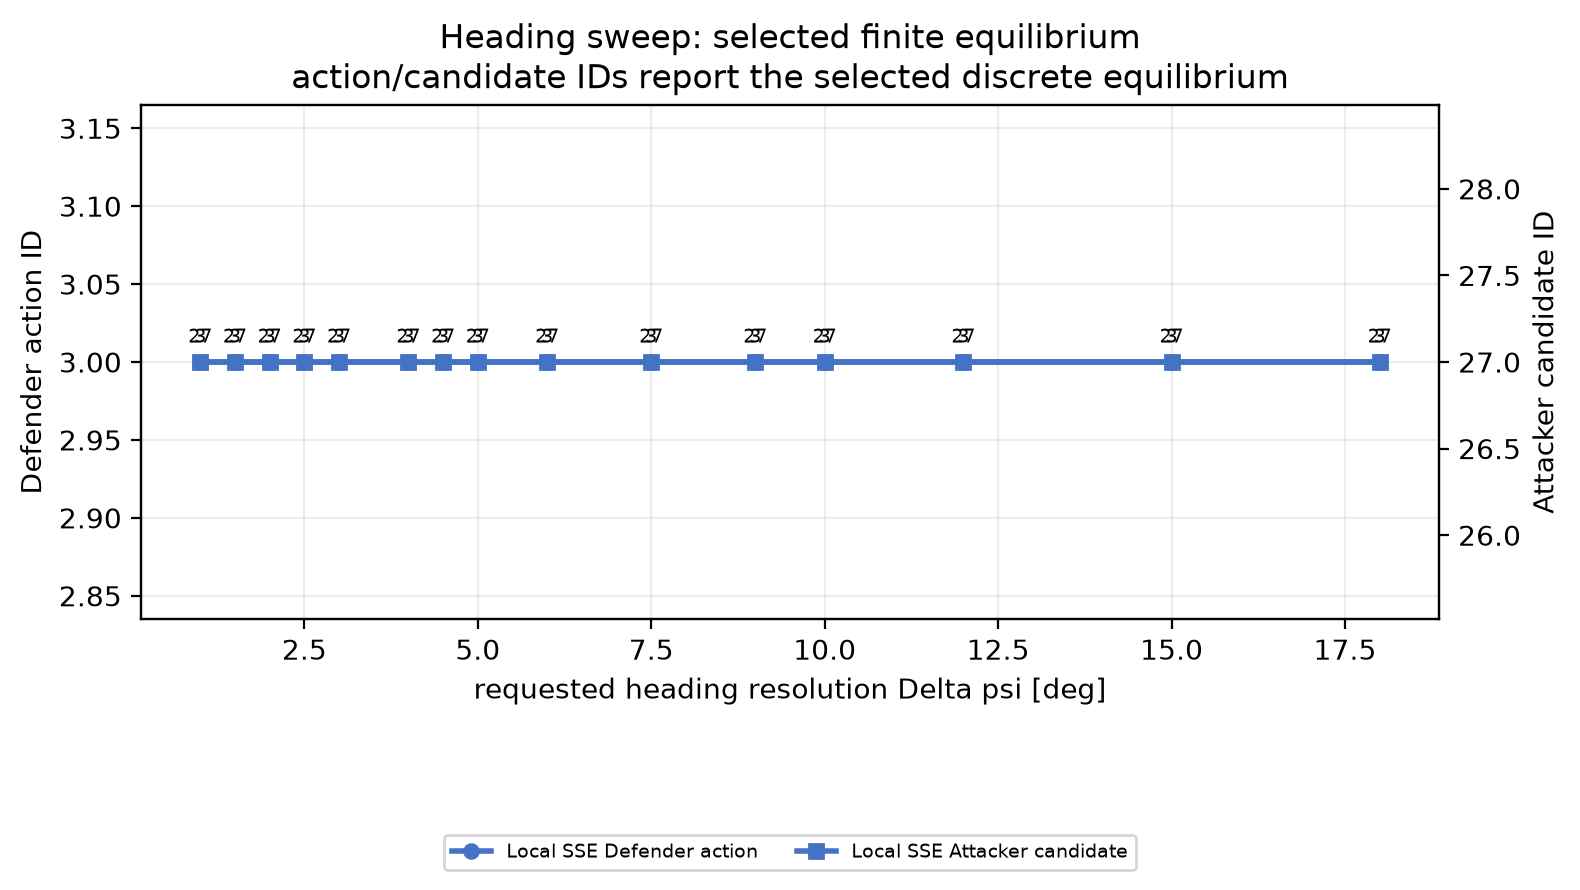

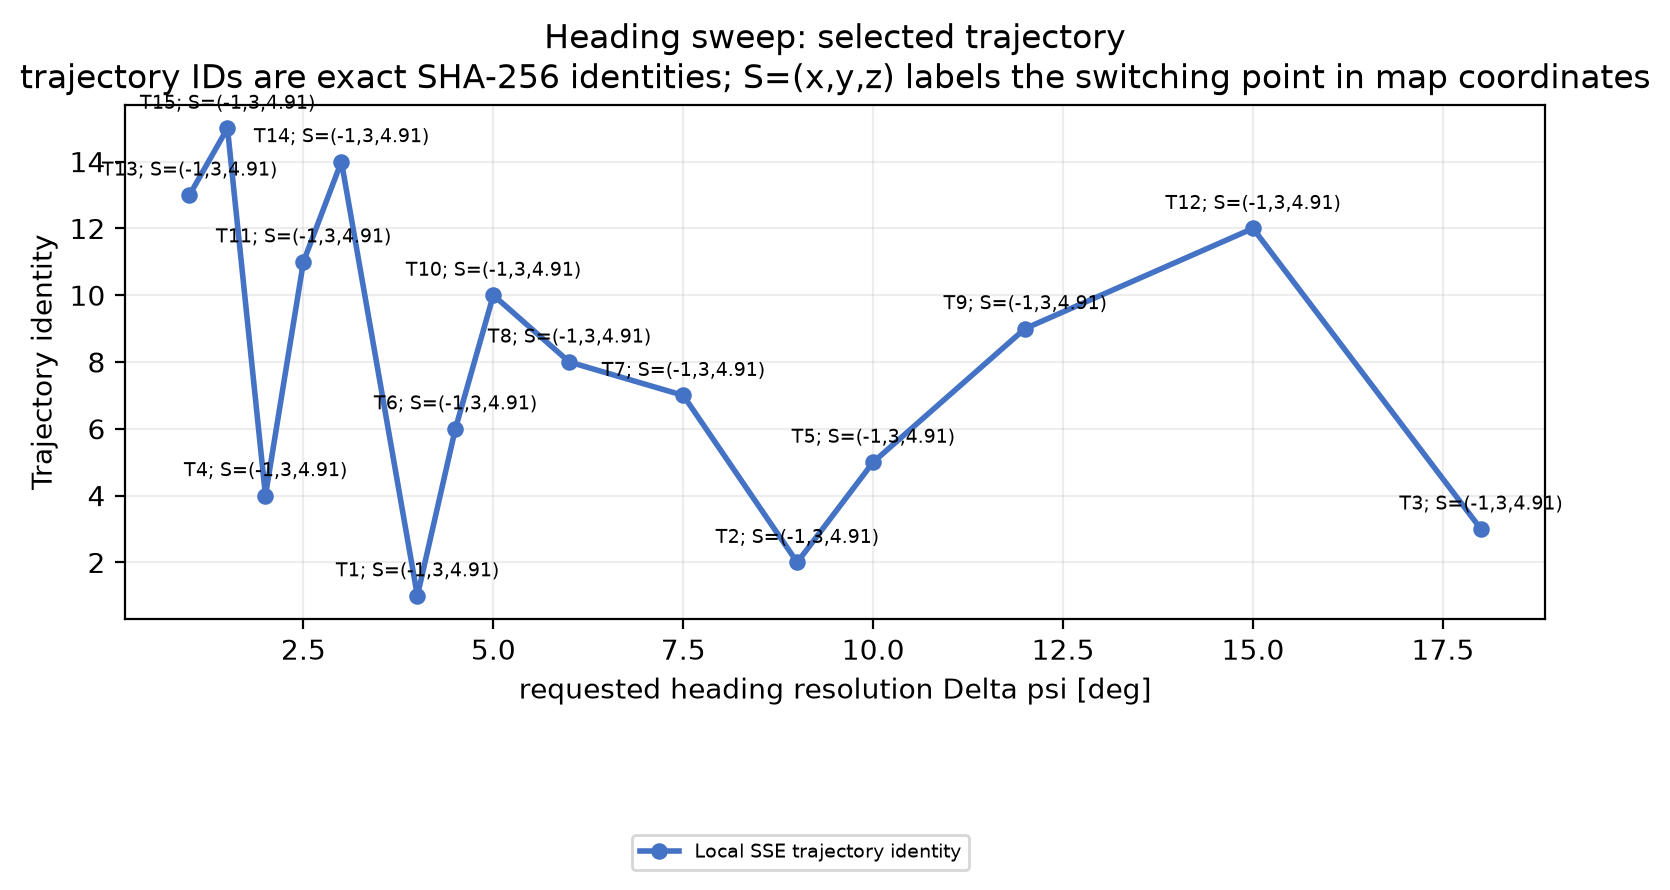

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_4_heading_resolution\raw_heading_repetitions.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_4_heading_resolution\raw_heading_repetitions.jsonl

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_4_heading_resolution\stage14_4_validation_report.json

In [20]:
display(HTML('<h4>Static Stage 14.4 figures</h4>'))
for figure_name in stage14_4_summary['figure_files']:
    display(HTML(f'<h5>{figure_name}</h5>'))
    display(Image(filename=str(STAGE14_4_DIR / figure_name)))

display(FileLink(STAGE14_4_DIR / 'raw_heading_repetitions.csv'))
display(FileLink(STAGE14_4_DIR / 'raw_heading_repetitions.jsonl'))
display(FileLink(STAGE14_4_DIR / 'stage14_4_validation_report.json'))

### Stage 14.4 interpretation boundary

- The primary plotted algorithm is the certified local SSE with exact finite
  Attacker responses. The frozen global solver remains a tractable oracle only.
- Completed repetitions are reported together with explicit fine-grid
  computational limits under the declared time and memory limits.
- Twenty requested heading spacings from 1 to 45 degrees are declared. Runtime
  behavior is measured only for completed points and is not a formal Big-O claim.
- Local and global outcomes coincide for this three-action Defender grid at all
  measured heading resolutions. This does not redefine local SSE as global SSE
  for other grids or initializations.
- The objective curves remain discretization-dependent. Twenty requested points
  improve resolution coverage but do not by themselves prove convergence.
- No Stage 14.5 work is started here.

## Stage 14.5 — one-variable switching-candidate count sweep

This section varies only LOS-tangent-surface contour sampling over 6, 9, and
12 samples while holding the radial count at 8. The resulting raw candidate
counts are 48, 72, and 96. The physical mission and continuous terrain are
unchanged.

In [21]:
if RECOMPUTE_STAGE14_5:
    stage14_5_summary = run_stage14_5_diagnostics(STAGE14_5_DIR, force=True)
else:
    summary_path = STAGE14_5_DIR / 'stage14_5_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError('Stage 14.5 artifact is absent; set RECOMPUTE_STAGE14_5=True.')
    stage14_5_summary = load_json(summary_path)

stage14_5_validation = load_json(STAGE14_5_DIR / 'stage14_5_validation_report.json')
display_record({
    'gate_passed': stage14_5_summary['gate_passed'],
    'contour_sample_counts': stage14_5_summary['contour_sample_counts'],
    'fixed_radial_sample_count': stage14_5_summary['fixed_radial_sample_count'],
    'raw_candidate_counts': stage14_5_summary['raw_candidate_counts'],
    'total_repetitions': stage14_5_summary['total_repetition_count'],
    'Bellman architecture measurement': stage14_5_summary['bellman_runtime_architecture_measurement'],
    'next_stage_started': stage14_5_summary['next_stage_started'],
})

gate_passed,True
contour_sample_counts,"[6, 9, 12]"
fixed_radial_sample_count,8
raw_candidate_counts,"[48, 72, 96]"
total_repetitions,18
Bellman architecture measurement,"{'interpretation': 'measured shared-Bellman behavior only; no monotonic trend is imposed', 'local_median_T_Bellman_s_by_raw_N_C': {'48': 3.949981899917475, '72': 5.4338690998993115, '96': 48.99781219982833}, 'relative_span_over_minimum': 11.404566259114256}"
next_stage_started,False


In [22]:
stage14_5_rows = load_json(STAGE14_5_DIR / 'candidate_sweep_summaries.json')
table_rows = []
for row in stage14_5_rows:
    components = row['runtime_statistics_s']
    med = lambda key: None if components.get(key) is None else round(components[key]['median'], 4)
    identity = row['solution_identities'][0] if row['solution_identities'] else (None,) * 5
    table_rows.append([
        row['algorithm_variant'], round(1.0 / row['requested_contour_sample_count'], 6),
        med('T_SSE_s'), med('T_LOS_s'), med('T_graph_s'), med('T_hazard_s'), med('T_switch_s'), med('T_Bellman_s'),
        None if row['peak_rss_statistics_bytes'] is None else round(row['peak_rss_statistics_bytes']['median'] / 1024**2, 2),
        None if row['J_A_statistics'] is None else row['J_A_statistics']['median'],
        None if row['J_D_statistics'] is None else row['J_D_statistics']['median'],
        identity[0], identity[1], None if identity[4] is None else identity[4][:10],
    ])
display(HTML(
    '<table><tr><th>variant</th><th>Delta s</th><th>T_SSE</th><th>T_LOS</th>'
    '<th>T_graph</th><th>T_hazard</th><th>T_switch</th><th>T_Bellman</th>'
    '<th>peak RSS [MiB]</th><th>J_A</th><th>J_D</th><th>D ID</th><th>A ID</th><th>trajectory</th></tr>'
    + ''.join('<tr>' + ''.join(f'<td>{value}</td>' for value in values) + '</tr>' for values in table_rows)
    + '</table><style>th,td{border:1px solid #bbb;padding:4px 7px}</style>'
))

variant,Delta s,T_SSE,T_LOS,T_graph,T_hazard,T_switch,T_Bellman,peak RSS [MiB],J_A,J_D,D ID,A ID,trajectory
local_sse,0.166667,30.8999,2.885,1.5782,3.9603,0.1974,3.95,192.4,0.2045392900376286,0.03764706502714094,1,16,61f011aeca
global_oracle,0.166667,52.2317,5.8888,1.5758,6.4272,0.387,6.9286,194.11,0.2644943595347,0.13668445481609712,4,13,78d86b288b
local_sse,0.111111,49.174,3.8657,1.6139,5.1524,0.3709,5.4339,195.2,0.31089702868278474,0.215471796199268,2,20,b2b1a50bbb
global_oracle,0.111111,62.2704,5.7759,1.6025,6.7396,0.5333,7.1827,195.39,0.31089702868278474,0.215471796199268,2,20,b2b1a50bbb
local_sse,0.083333,448.0406,23.0826,1.4777,35.165,2.8329,48.9978,200.18,7.1945895064610585,0.9999991723787202,3,27,643ae13a42
global_oracle,0.083333,510.7388,30.7341,1.4848,39.5508,3.7702,55.0311,200.01,7.1945895064610585,0.9999991723787202,3,27,643ae13a42


### Stage 14.5 switching-candidate-density figure guide

The common x-axis is normalized contour spacing `Delta s = 1/N_contour`. Only
the contour sampling density changes; radial sampling remains fixed at eight.
The certified local SSE is the primary solid series and the frozen exact global
solver is a dashed tractable oracle/reference series.

Stages 14.3--14.6 use the same six-figure schema:

1. total SSE runtime;
2. the common runtime-component decomposition for both solvers;
3. peak process-tree memory;
4. `J_A` and `J_D`;
5. selected Defender/Attacker equilibrium IDs;
6. selected trajectory identity and switching-point coordinates.

Candidate-filter counts remain available in raw/tabular validation artifacts,
but are not a primary performance figure.

Every repetition uses a fresh isolated Python worker. This does not claim cold
operating-system or hardware caches. `N_C_unique` records distinct physical
positions but does not change or deduplicate the solver candidate set.

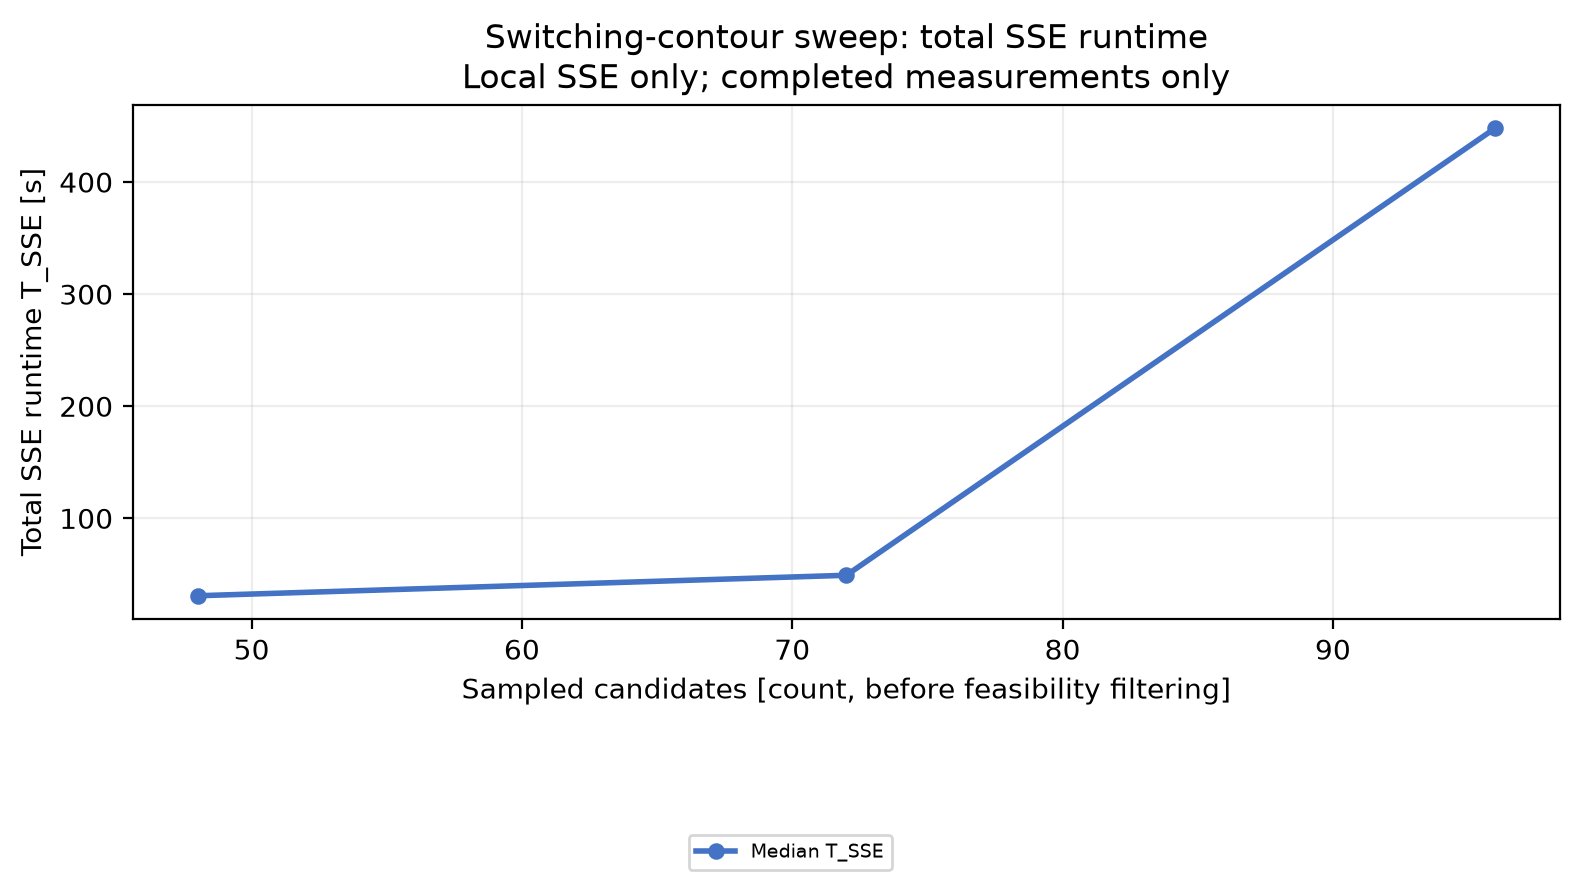

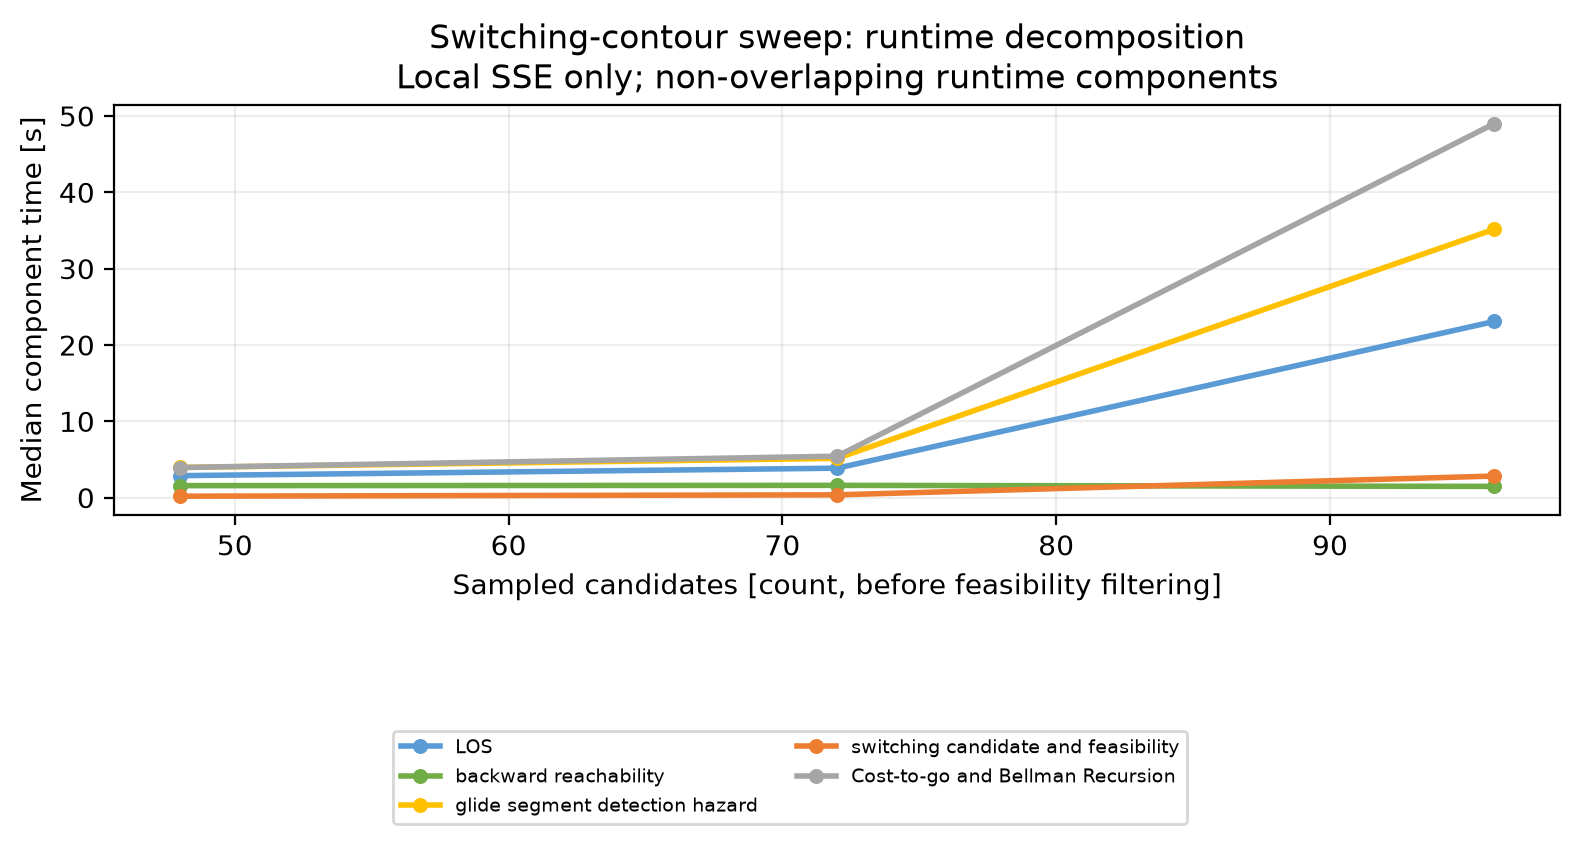

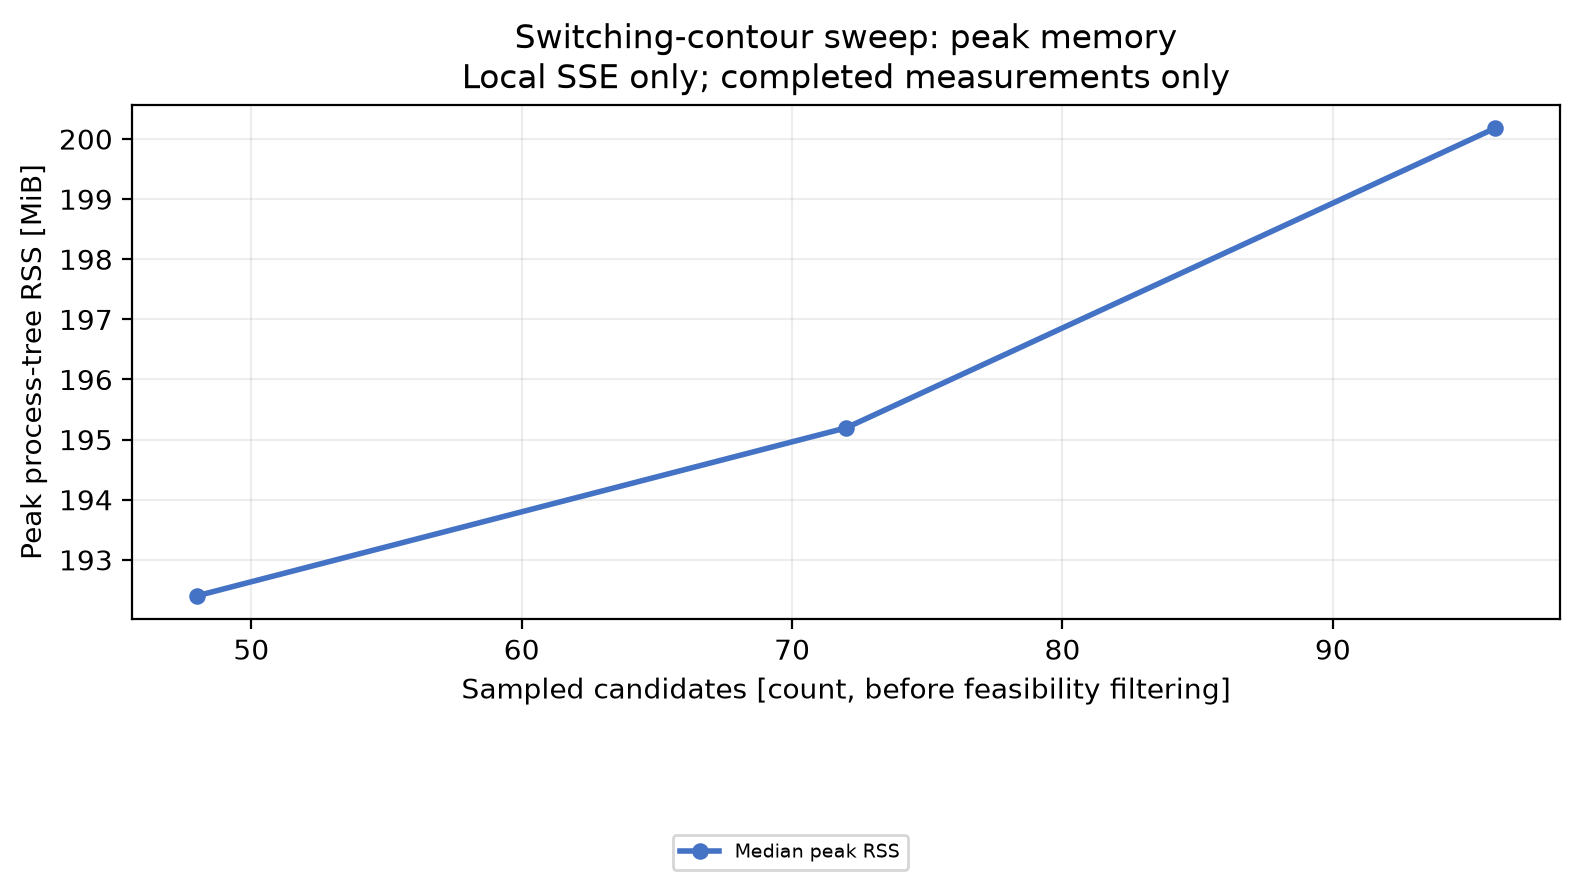

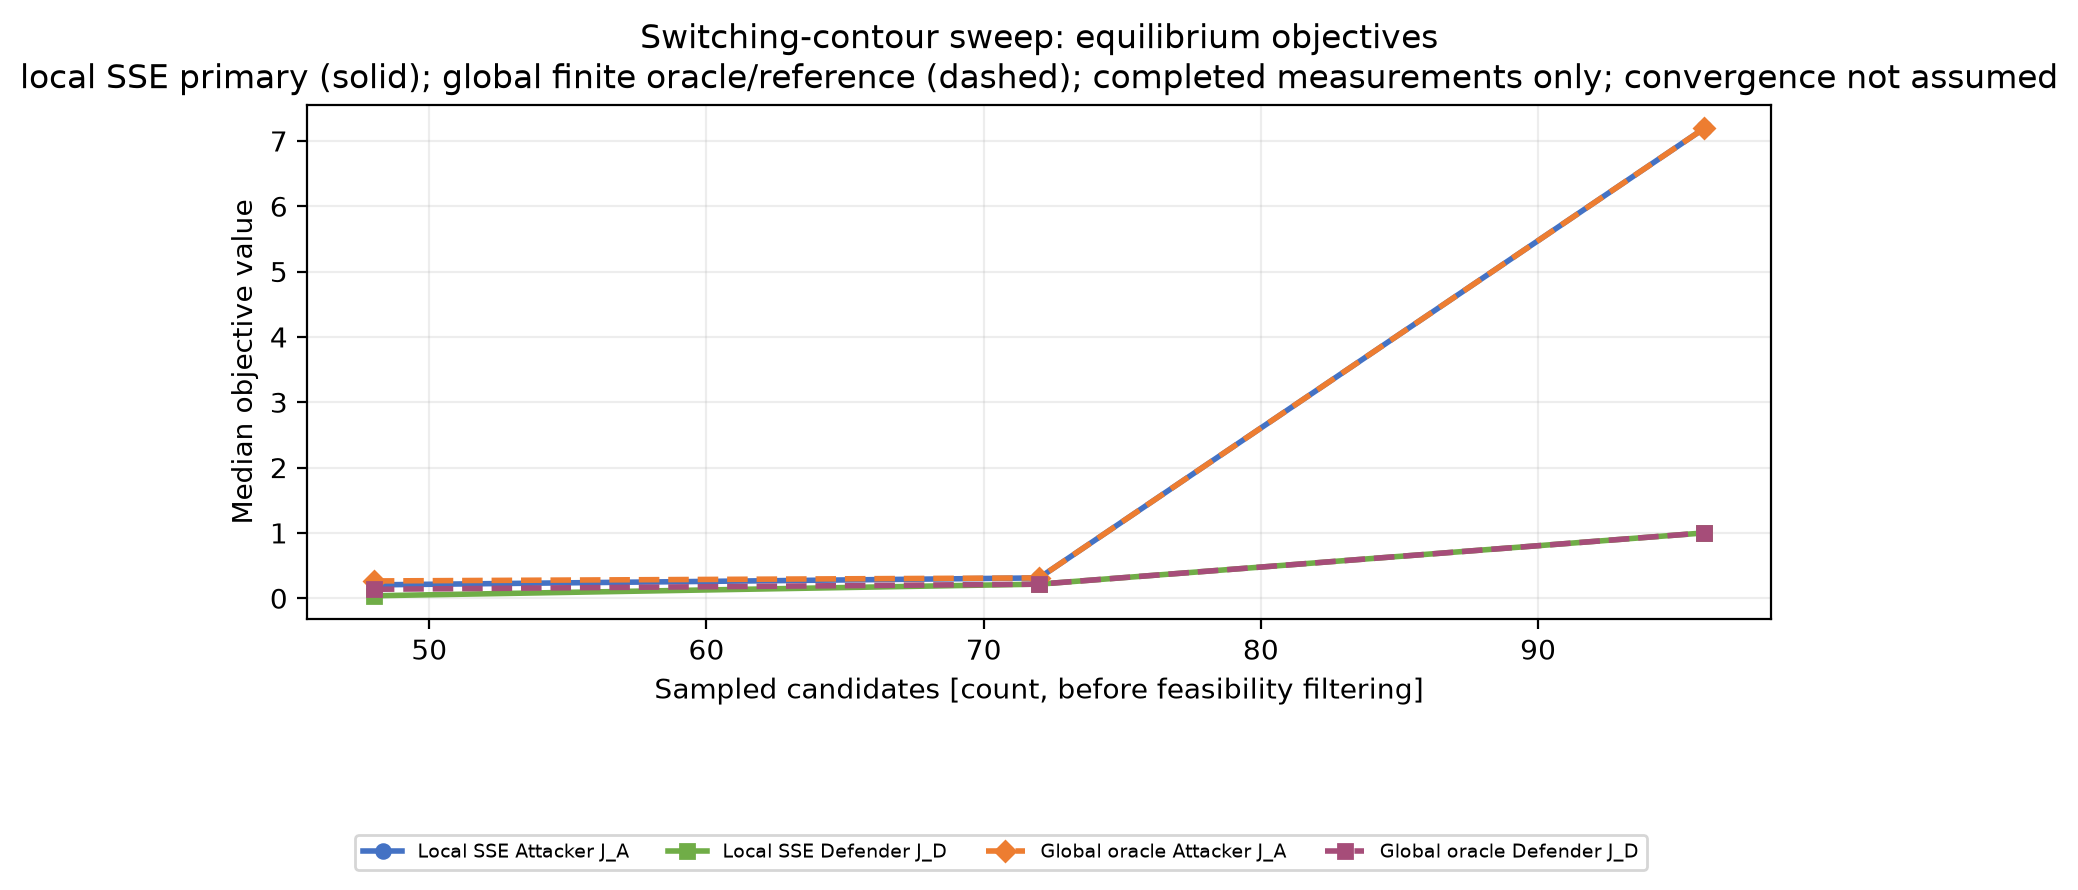

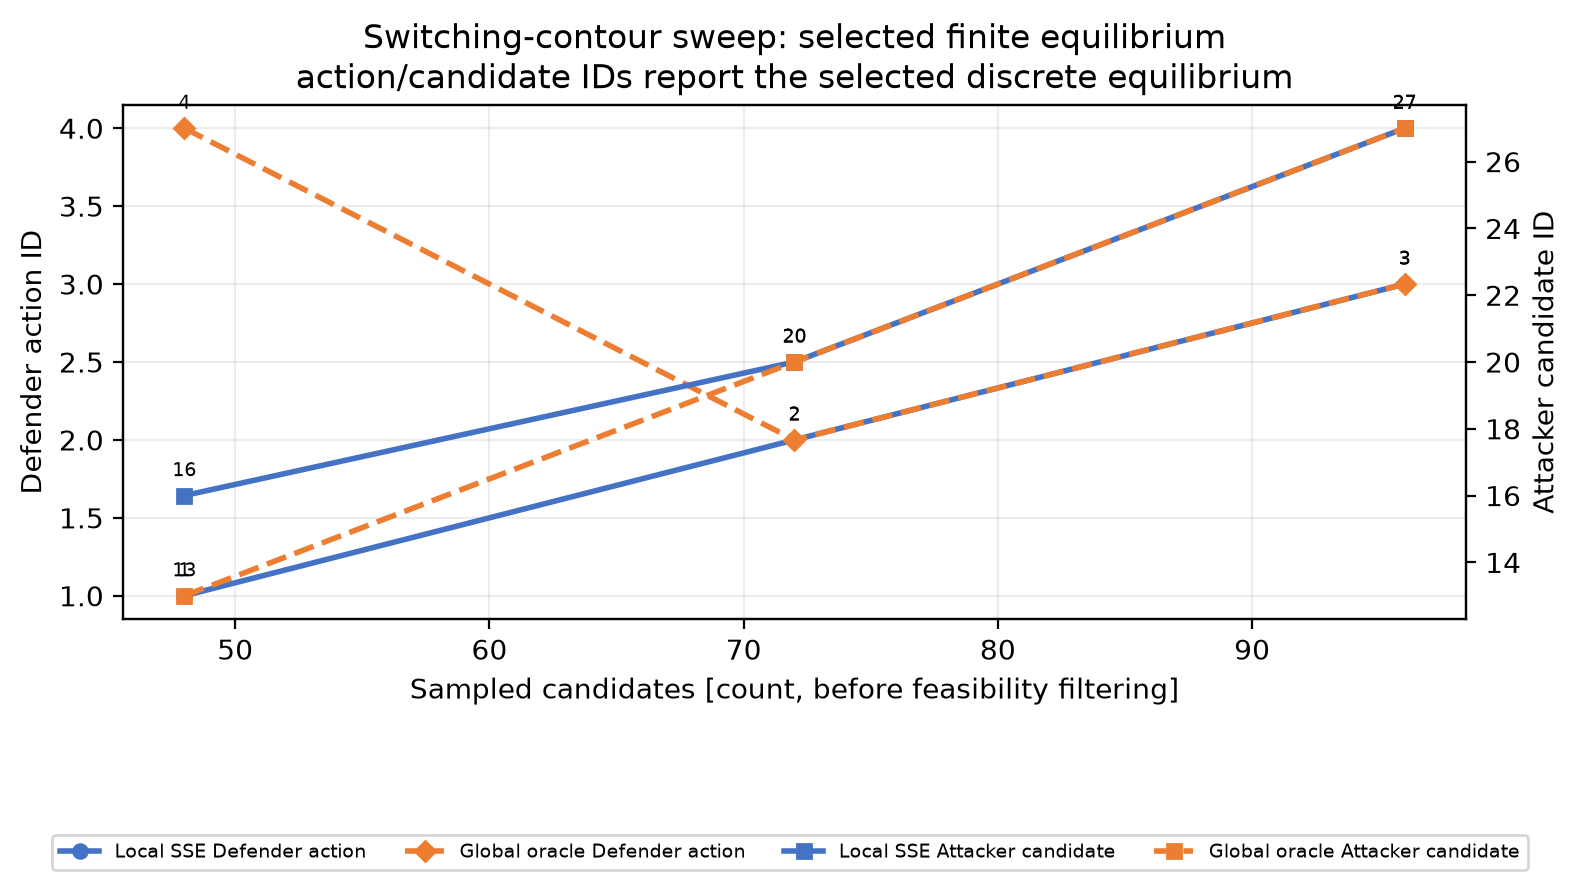

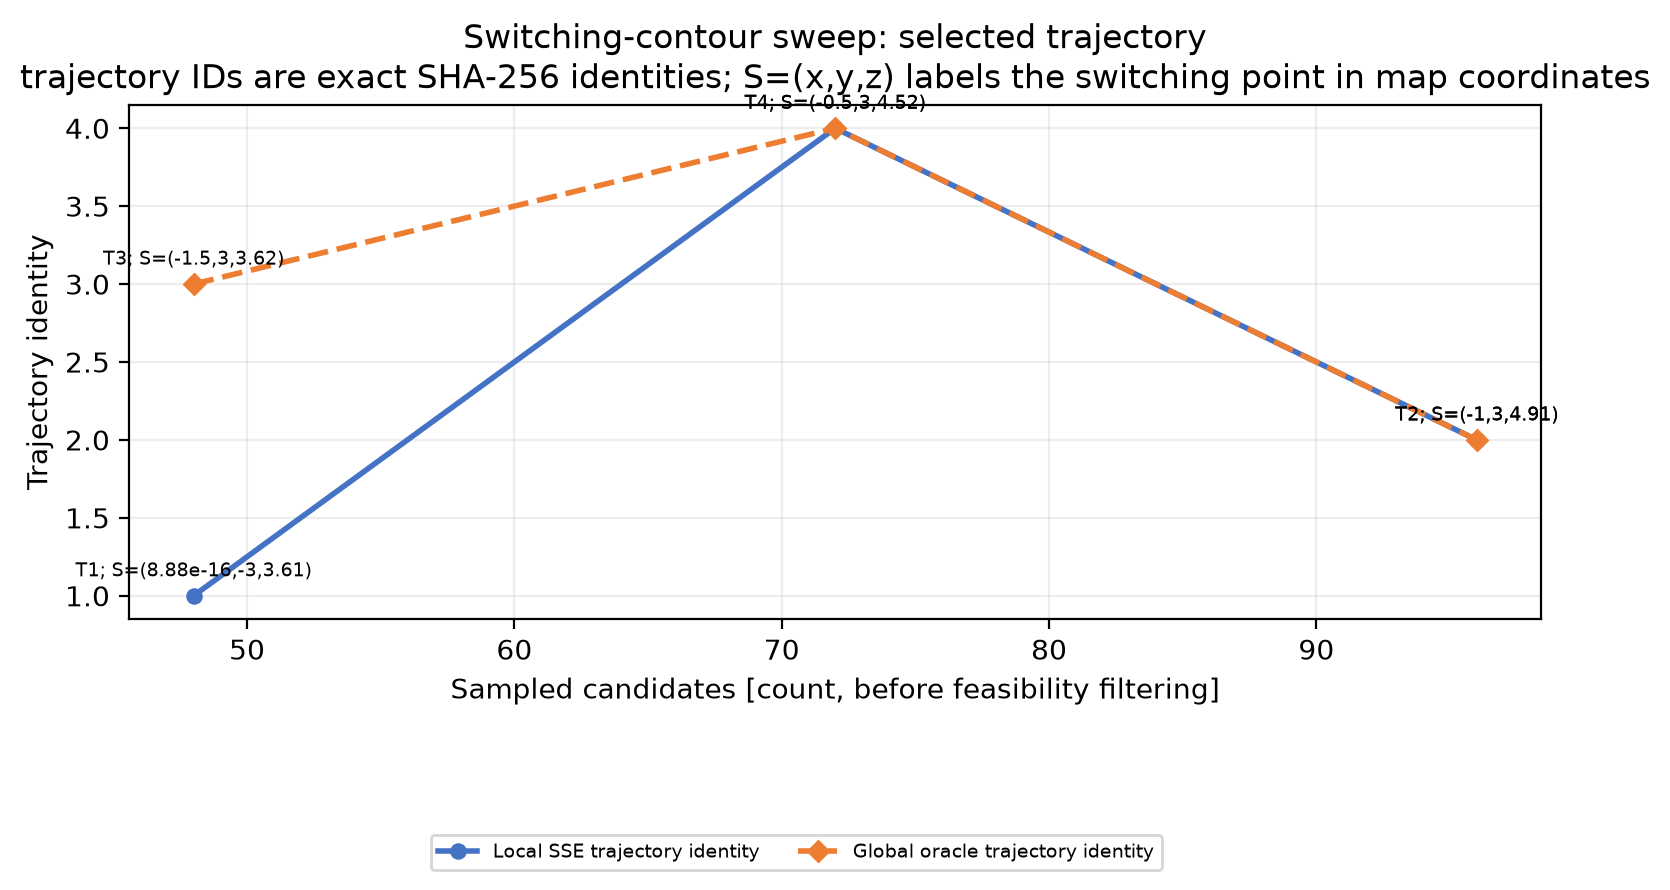

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_5_switching_candidates\raw_candidate_repetitions.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_5_switching_candidates\raw_candidate_repetitions.jsonl

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_5_switching_candidates\candidate_sweep_summaries.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_5_switching_candidates\stage14_5_validation_report.json

In [23]:
display(HTML('<h4>Static Stage 14.5 figures</h4>'))
for figure_name in stage14_5_summary['figure_files']:
    display(HTML(f'<h5>{figure_name}</h5>'))
    display(Image(filename=str(STAGE14_5_DIR / figure_name)))

display(FileLink(STAGE14_5_DIR / 'raw_candidate_repetitions.csv'))
display(FileLink(STAGE14_5_DIR / 'raw_candidate_repetitions.jsonl'))
display(FileLink(STAGE14_5_DIR / 'candidate_sweep_summaries.csv'))
display(FileLink(STAGE14_5_DIR / 'stage14_5_validation_report.json'))

### Stage 14.5 interpretation boundary

- Only switching-contour sample count varies; spatial/altitude/heading grids,
  radial sampling, quadrature, Defender actions, terrain, physics, objectives,
  and tie rules remain fixed.
- Every plotted timing point is a median of three isolated-process repetitions.
- The candidate funnel contains cumulative survivor counts. The unique-position
  curve is diagnostic and is not an additional solver filter.
- Exact exhaustive candidate minimization, Strong follower tie handling,
  local-SSE certification, and independent trajectory replay are exit-gate
  requirements.
- Objective convergence is not declared from three candidate-density points.
- No Stage 14.6 work is started here.

## Stage 14.6 — one-variable local-neighborhood radius sweep

This section holds a deterministic nine-action Defender grid fixed and varies
only `r_neighbor` over `{1, 2, 4, 8}`. Action ID 0 is the fixed start, and
`r_neighbor=8` is the complete-grid/global-reference endpoint.

In [24]:
if RECOMPUTE_STAGE14_6:
    stage14_6_summary = run_stage14_6_diagnostics(STAGE14_6_DIR, force=True)
else:
    summary_path = STAGE14_6_DIR / 'stage14_6_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError('Stage 14.6 artifact is absent; set RECOMPUTE_STAGE14_6=True.')
    stage14_6_summary = load_json(summary_path)

stage14_6_validation = load_json(STAGE14_6_DIR / 'stage14_6_validation_report.json')
display_record({
    'gate_passed': stage14_6_summary['gate_passed'],
    'r_neighbor_values': stage14_6_summary['r_neighbor_values'],
    'fixed_defender_action_count': stage14_6_summary['defender_action_count'],
    'fixed_defender_x_map': stage14_6_summary['defender_x_map'],
    'full_radius': stage14_6_summary['full_radius'],
    'full_radius_equals_global': stage14_6_summary['full_radius_global_equivalence_passed'],
    'total_repetitions': stage14_6_summary['total_repetition_count'],
    'next_stage_started': stage14_6_summary['next_stage_started'],
})

gate_passed,True
r_neighbor_values,"[1, 2, 4, 8]"
fixed_defender_action_count,9
fixed_defender_x_map,"[5.0, 5.3125, 5.625, 5.9375, 6.25, 6.5625, 6.875, 7.1875, 7.5]"
full_radius,8
full_radius_equals_global,True
total_repetitions,15
next_stage_started,False


In [25]:
stage14_6_rows = load_json(STAGE14_6_DIR / 'radius_sweep_summaries.json')
table_rows = []
for row in stage14_6_rows:
    components = row['runtime_statistics_s']
    med = lambda key: None if components.get(key) is None else round(components[key]['median'], 4)
    identity = row['solution_identities'][0] if row['solution_identities'] else (None,) * 5
    table_rows.append([
        row['algorithm_variant'], row['r_neighbor'],
        med('T_SSE_s'), med('T_LOS_s'), med('T_graph_s'), med('T_hazard_s'), med('T_switch_s'), med('T_Bellman_s'),
        None if row['peak_rss_statistics_bytes'] is None else round(row['peak_rss_statistics_bytes']['median'] / 1024**2, 2),
        None if row['J_A_statistics'] is None else row['J_A_statistics']['median'],
        None if row['J_D_statistics'] is None else row['J_D_statistics']['median'],
        identity[0], identity[1], None if identity[4] is None else identity[4][:10],
    ])
display(HTML(
    '<table><tr><th>variant</th><th>r_neighbor</th><th>T_SSE</th><th>T_LOS</th>'
    '<th>T_graph</th><th>T_hazard</th><th>T_switch</th><th>T_Bellman</th>'
    '<th>peak RSS [MiB]</th><th>J_A</th><th>J_D</th><th>D ID</th><th>A ID</th><th>trajectory</th></tr>'
    + ''.join('<tr>' + ''.join(f'<td>{value}</td>' for value in values) + '</tr>' for values in table_rows)
    + '</table><style>th,td{border:1px solid #bbb;padding:4px 7px}</style>'
))

variant,r_neighbor,T_SSE,T_LOS,T_graph,T_hazard,T_switch,T_Bellman,peak RSS [MiB],J_A,J_D,D ID,A ID,trajectory
local_sse,1,18.7822,1.8967,1.5435,2.1151,0.2283,4.17,191.22,0.18906376619883056,0.015043572080443185,0,34,2e26280151
local_sse,2,19.8876,2.8507,1.5149,2.1175,0.3365,4.2384,190.23,0.18906376619883056,0.015043572080443185,0,34,2e26280151
local_sse,4,22.2589,4.7811,1.5426,2.0772,0.5491,4.317,191.34,0.18906376619883056,0.015043572080443185,0,34,2e26280151
local_sse,8,48.4244,8.5317,1.5304,3.8557,0.984,8.1662,196.03,0.944086144839464,0.7814861193516704,8,26,827fe82284
global_oracle,8,48.721,8.5288,1.5518,4.0789,0.9888,8.5078,196.07,0.944086144839464,0.7814861193516704,8,26,827fe82284


### Stage 14.6 neighborhood-radius figure guide

The common x-axis is `r_neighbor`, measured in Defender grid-index lengths.
The complete nine-action Defender grid, physical sensor coordinates, initial
action, Attacker discretization, terrain, physics, objectives, and numerical
tolerances remain fixed. The exact global solver appears only as the full-radius
reference endpoint.

Stages 14.3--14.6 use the same six-figure schema; only the controlled x-axis
changes:

1. total SSE runtime;
2. the common runtime-component decomposition for both solvers;
3. peak process-tree memory;
4. `J_A` and `J_D`;
5. selected Defender/Attacker equilibrium IDs;
6. selected trajectory identity and switching-point coordinates.

Evaluation counts, cache hits, local-search iterations, and neighborhood-width
records remain in raw/tabular validation artifacts, not in the primary
performance figures.

All figures are static PNGs. Legends are outside the axes at bottom center.

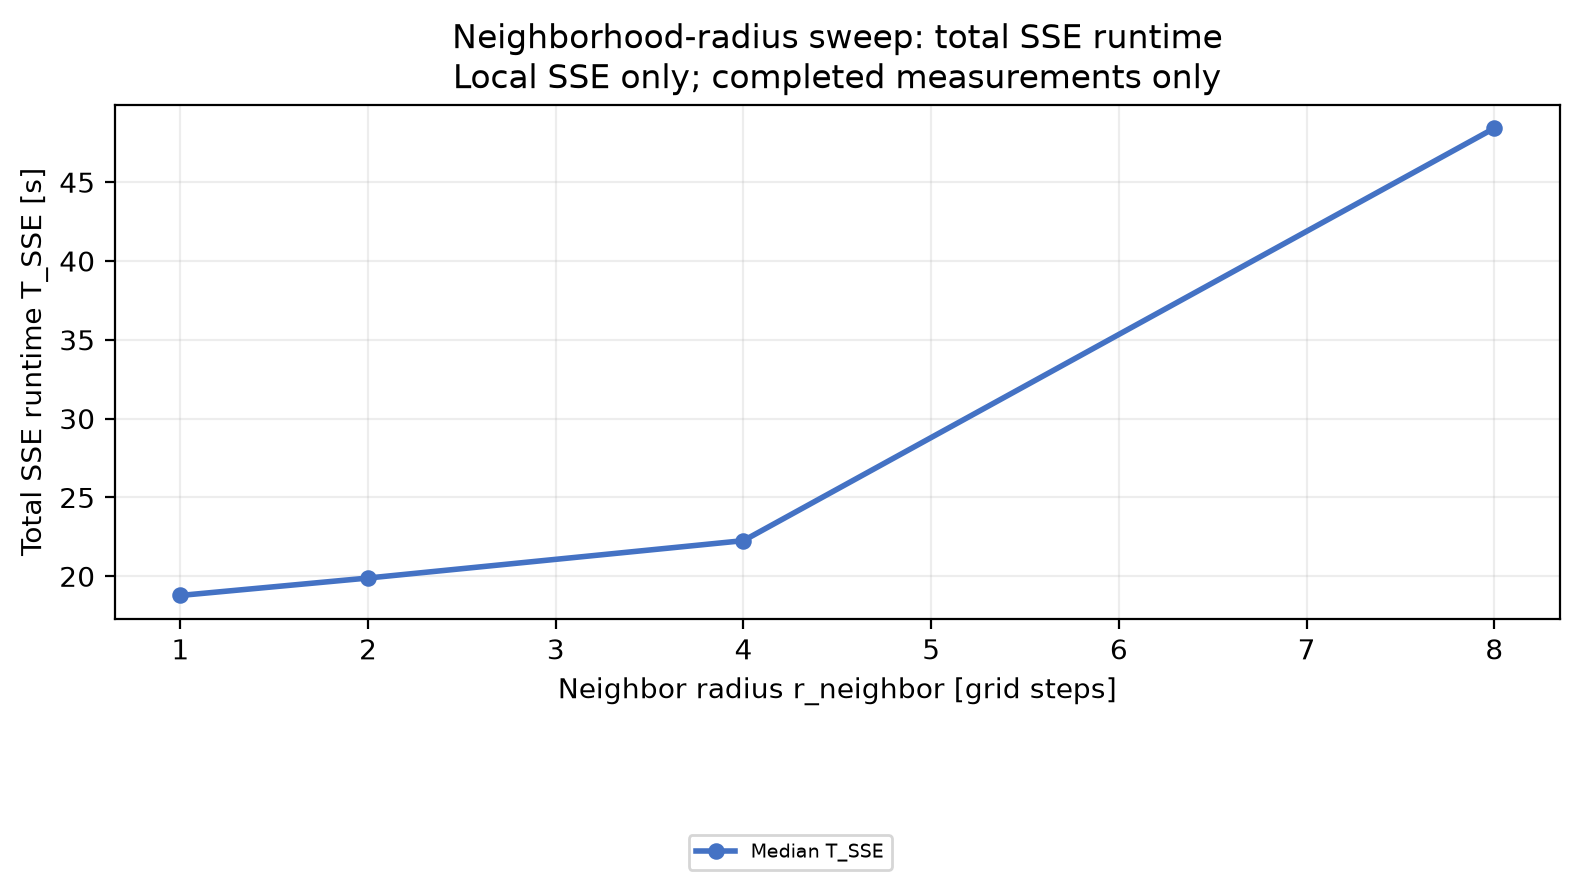

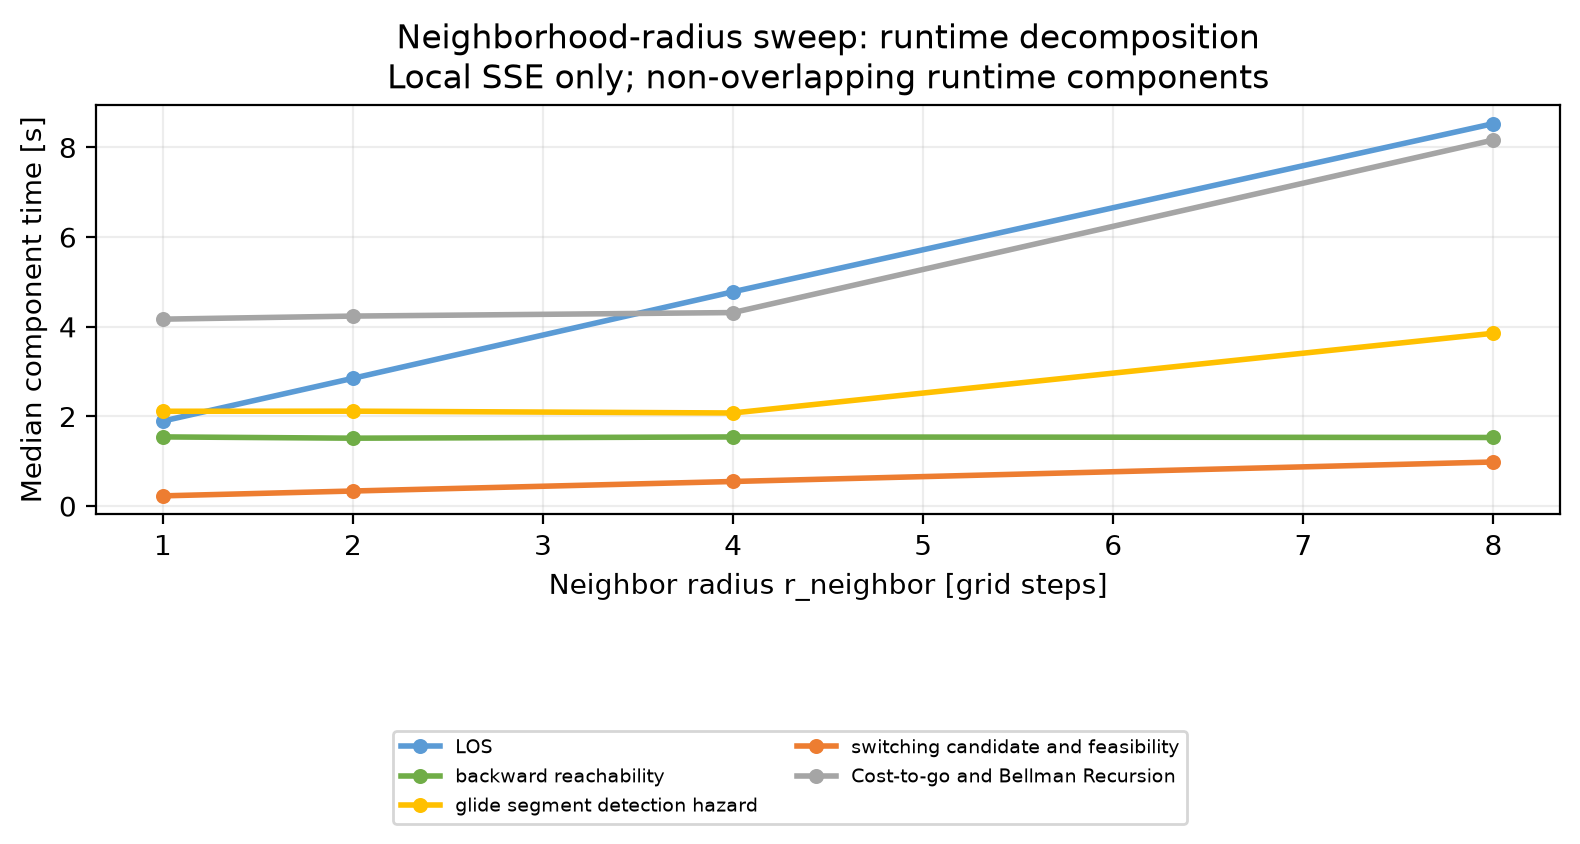

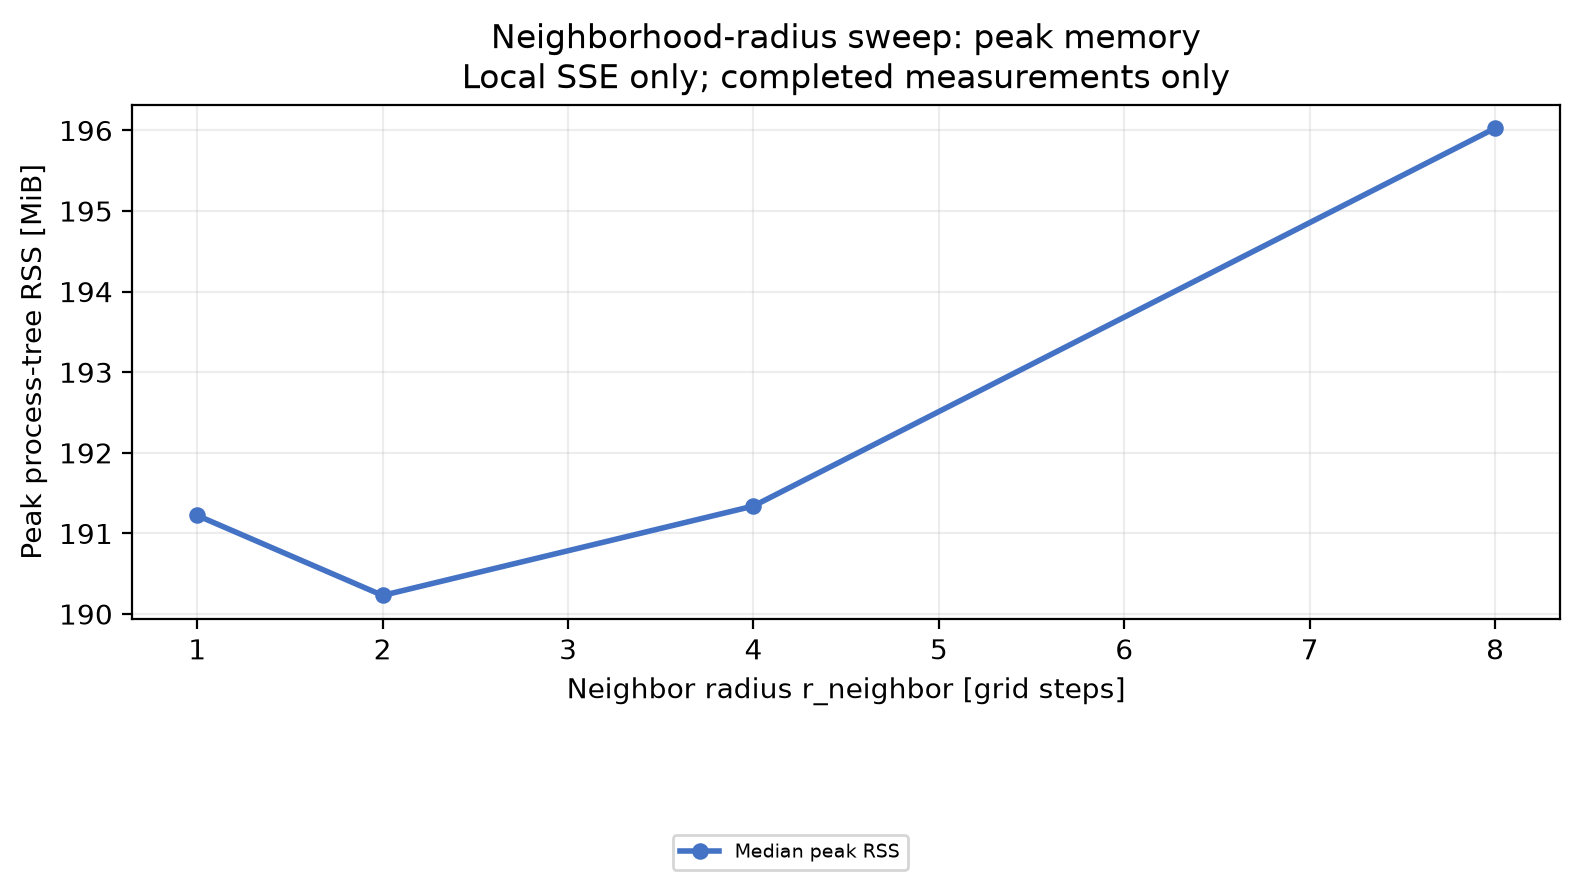

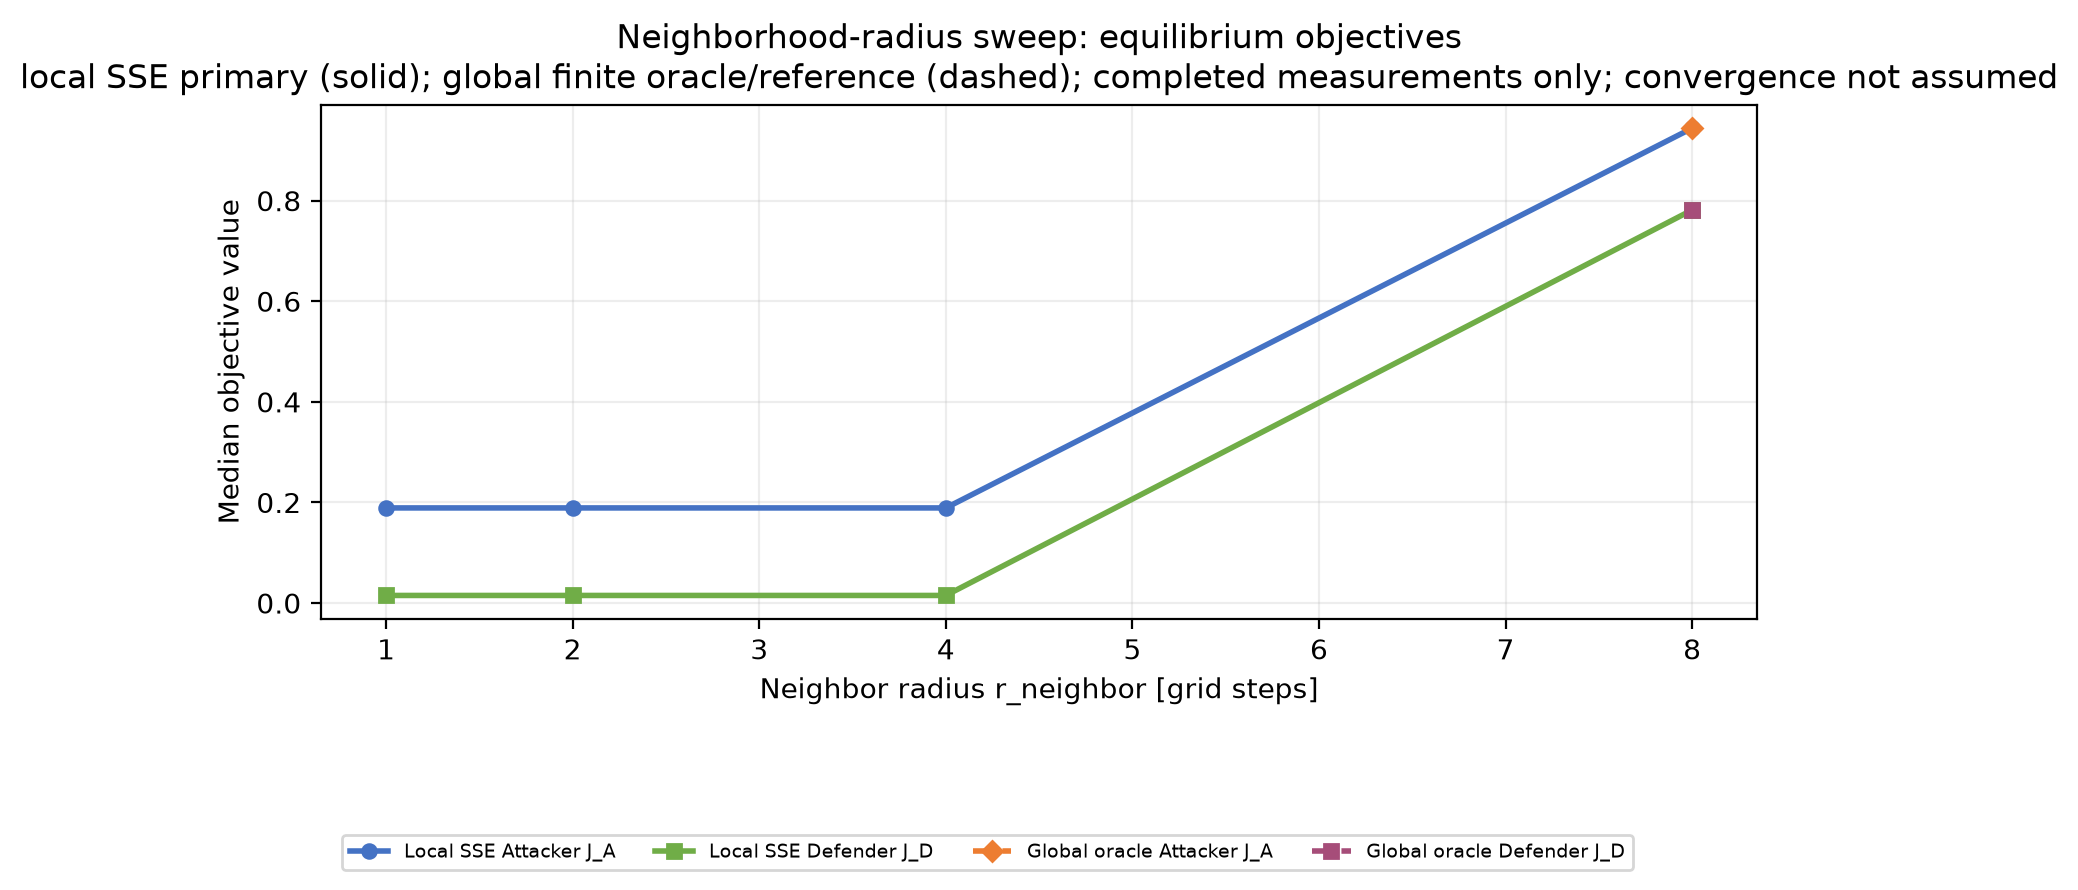

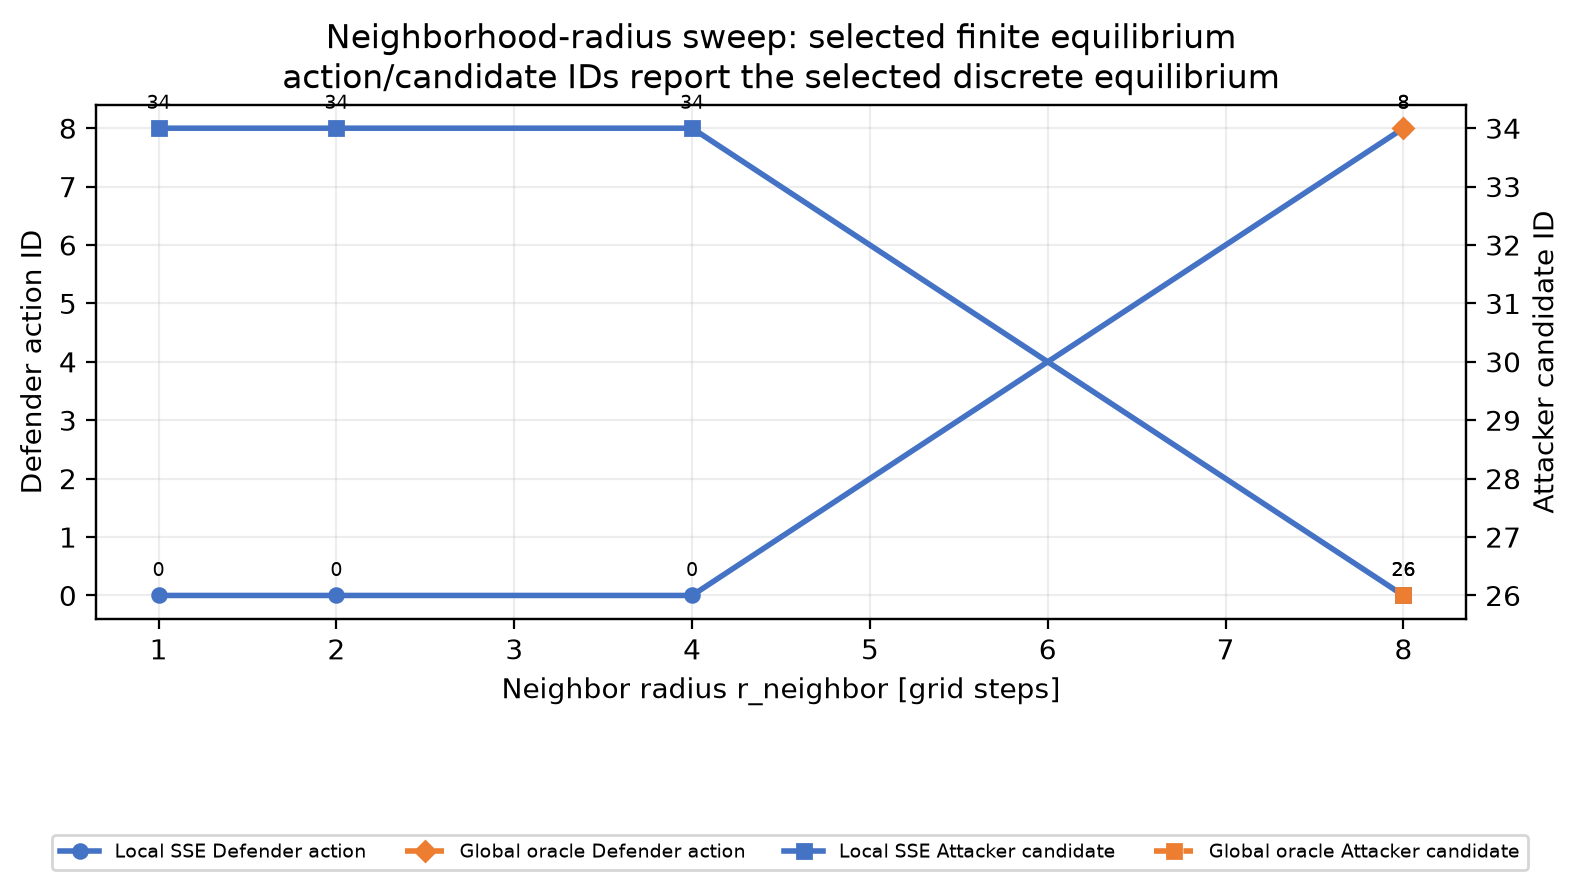

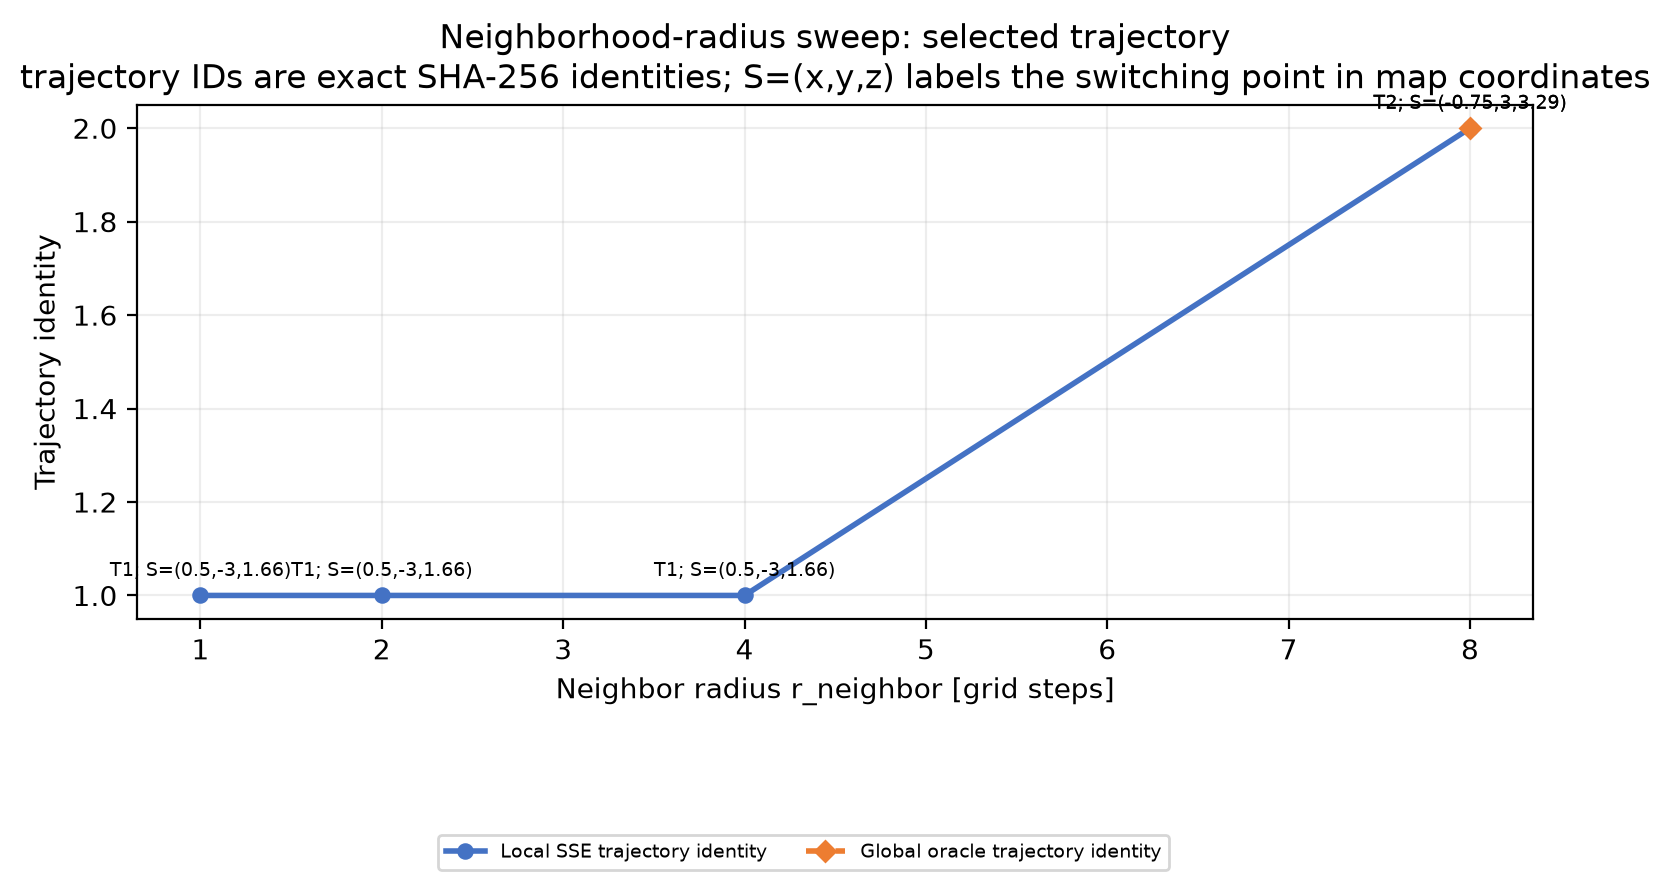

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_6_neighbor_radius\raw_radius_repetitions.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_6_neighbor_radius\raw_radius_repetitions.jsonl

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_6_neighbor_radius\radius_sweep_summaries.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_6_neighbor_radius\full_radius_global_equivalence.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_6_neighbor_radius\stage14_6_validation_report.json

In [26]:
display(HTML('<h4>Static Stage 14.6 figures</h4>'))
for figure_name in stage14_6_summary['figure_files']:
    display(HTML(f'<h5>{figure_name}</h5>'))
    display(Image(filename=str(STAGE14_6_DIR / figure_name)))

display(FileLink(STAGE14_6_DIR / 'raw_radius_repetitions.csv'))
display(FileLink(STAGE14_6_DIR / 'raw_radius_repetitions.jsonl'))
display(FileLink(STAGE14_6_DIR / 'radius_sweep_summaries.json'))
display(FileLink(STAGE14_6_DIR / 'full_radius_global_equivalence.json'))
display(FileLink(STAGE14_6_DIR / 'stage14_6_validation_report.json'))

### Stage 14.6 interpretation boundary

- This is a one-variable local-neighborhood-radius experiment; it is not a
  Defender-action-count sweep.
- Runtime is interpreted using realized unique exact BR evaluations and measured
  overhead. Increasing radius need not imply monotonic runtime because search
  iteration count can change.
- `r_neighbor=8=N_D-1` covers the complete fixed action grid and must match the
  unchanged exact global finite-SSE result within frozen tolerances.
- Smaller-radius results certify local SSE only and are initialization- and
  neighborhood-dependent; they are not global-equilibrium claims.
- No Stage 14.7 work is started here.

## Stage 14.7 — theoretical and empirical scaling analysis

This section consolidates completed Stage 14.3–14.6 measurements. It performs
analysis and static rendering only; it does not launch Bellman, Attacker-BR,
local-SSE, or global-SSE workers.

In [27]:
if RECOMPUTE_STAGE14_7:
    stage14_7_summary = run_stage14_7_analysis(STAGE14_7_DIR)
else:
    summary_path = STAGE14_7_DIR / 'stage14_7_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError('Stage 14.7 artifact is absent; set RECOMPUTE_STAGE14_7=True.')
    stage14_7_summary = load_json(summary_path)

stage14_7_validation = load_json(STAGE14_7_DIR / 'stage14_7_validation_report.json')
display_record({
    'gate_passed': stage14_7_summary['gate_passed'],
    'source_sweeps': stage14_7_summary['source_sweeps'],
    'normalized_configurations': stage14_7_summary['normalized_configuration_count'],
    'completed_configurations': stage14_7_summary['completed_configuration_count'],
    'completed_fits': f"{stage14_7_summary['completed_fit_count']}/{stage14_7_summary['fit_record_count']}",
    'noncompleted_repetitions_retained': stage14_7_summary['noncompleted_repetition_count'],
    'solver_or_benchmark_workers_started': stage14_7_summary['solver_or_benchmark_workers_started'],
    'next_stage_started': stage14_7_summary['next_stage_started'],
})

gate_passed,True
source_sweeps,"['spatial', 'heading', 'switching', 'radius']"
normalized_configurations,29
completed_configurations,26
completed_fits,33/33
noncompleted_repetitions_retained,9
solver_or_benchmark_workers_started,0
next_stage_started,False


In [28]:
stage14_7_fits = load_json(STAGE14_7_DIR / 'fit_parameters.json')
primary_fit_ids = [
    'spatial__local_sse__T_total_s_vs_spatial_resolution_m',
    'heading__local_sse__T_total_s_vs_heading_resolution_deg',
    'switching__local_sse__T_total_s_vs_switching_contour_spacing',
    'radius__local_sse__T_total_s_vs_r_neighbor',
    'radius__local_sse__T_total_s_vs_N_eval_unique',
]
fit_by_id = {row['fit_id']: row for row in stage14_7_fits}
table_rows = []
for fit_id in primary_fit_ids:
    row = fit_by_id[fit_id]
    table_rows.append([
        fit_id, row['sample_count'], row['fit_range'],
        round(row['c'], 6), round(row['alpha'], 6), round(row['r_squared'], 6),
        row['empirical_fit_only'], row['formal_big_o_claim'], row['extrapolation_performed'],
    ])
display(HTML(
    '<table><tr><th>fit</th><th>n</th><th>range</th><th>c</th><th>alpha</th>'
    '<th>R^2</th><th>empirical only</th><th>formal Big-O</th><th>extrapolated</th></tr>'
    + ''.join('<tr>' + ''.join(f'<td>{value}</td>' for value in row) + '</tr>' for row in table_rows)
    + '</table><style>th,td{border:1px solid #bbb;padding:4px 7px}</style>'
))

fit,n,range,c,alpha,R^2,empirical only,formal Big-O,extrapolated
spatial__local_sse__T_total_s_vs_spatial_resolution_m,3,"{'maximum': 100.0, 'minimum': 25.0}",6947.140179,-1.449316,0.965124,True,False,False
heading__local_sse__T_total_s_vs_heading_resolution_deg,4,"{'maximum': 15.0, 'minimum': 2.5}",1784.320155,-2.185729,0.998075,True,False,False
switching__local_sse__T_total_s_vs_switching_contour_spacing,3,"{'maximum': 0.16666666666666666, 'minimum': 0.08333333333333333}",0.741942,-1.786224,0.952956,True,False,False
radius__local_sse__T_total_s_vs_r_neighbor,4,"{'maximum': 8.0, 'minimum': 1.0}",16.173116,0.426161,0.746468,True,False,False
radius__local_sse__T_total_s_vs_N_eval_unique,4,"{'maximum': 9.0, 'minimum': 2.0}",10.735556,0.60937,0.806819,True,False,False


### Stage 14.7 consolidated scaling figure guide

All points come from previously saved Stage 14.3–14.6 measurements; this
analysis starts no solver or benchmark worker. Dotted power-law curves are
finite-range empirical fits only. Their `alpha` values are not formal Big-O.

1. Total runtime versus spatial spacing `Delta x = Delta y = Delta h` in metres;
   full-grid and active-corridor state counts are secondary-y diagnostics.
2. Total runtime versus requested heading spacing `Delta psi` in degrees.
3. Total runtime versus normalized switching-contour spacing
   `Delta s = 1 / N_contour`; raw candidate count is a secondary-y diagnostic.
4. Total local-SSE runtime versus `r_neighbor`.
5. Unique evaluations and local-search iterations versus `r_neighbor`.
6. Bellman runtime versus sweep-specific spatial/heading discretization;
   `N_S_active` and `N_E` remain separate secondary-y diagnostics.
7. Peak memory versus sweep-specific spatial/heading discretization;
   `N_S_active` and `N_E` remain separate secondary-y diagnostics.
8. Additive local-SSE runtime decomposition across the four sweeps.
9. Objective sensitivity to spatial, heading, and switching discretization;
   this is a diagnostic and not a convergence proof.

Every legend is outside the axes at bottom center. Every output is static PNG.

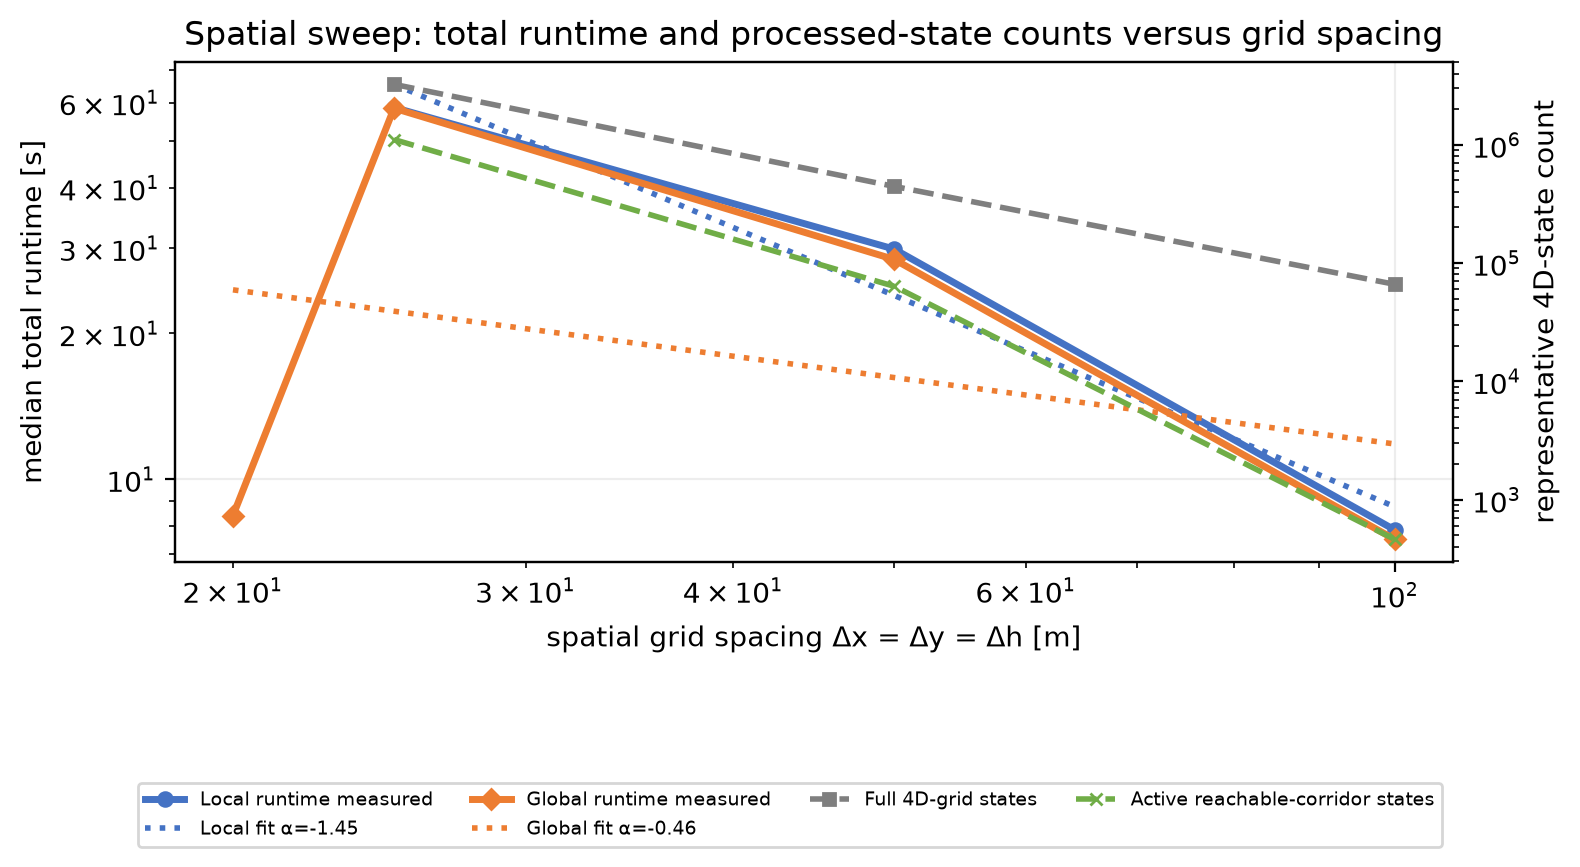

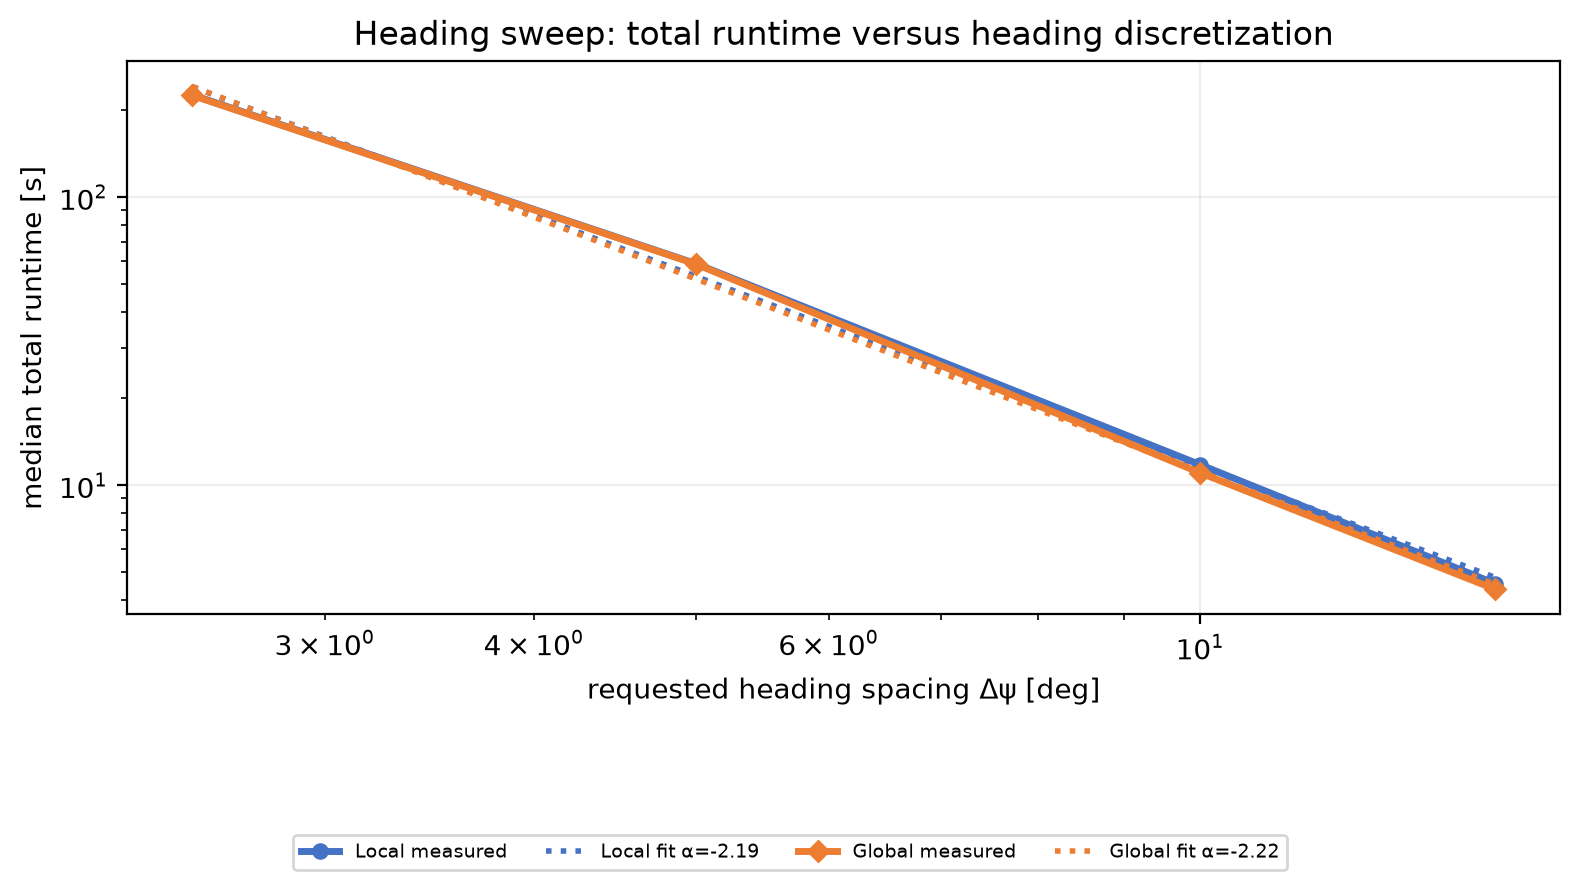

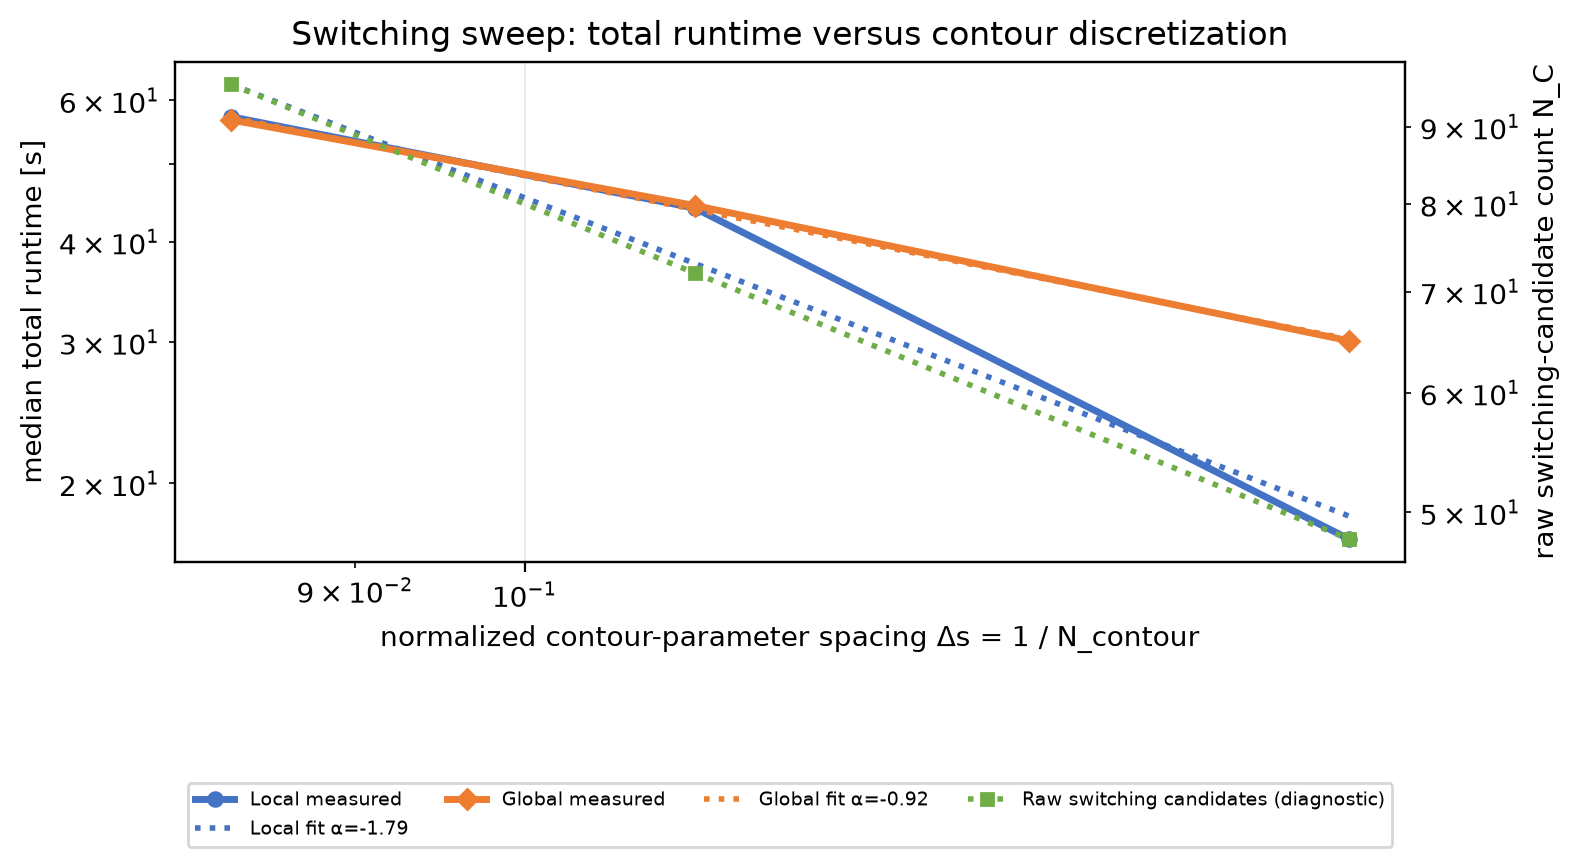

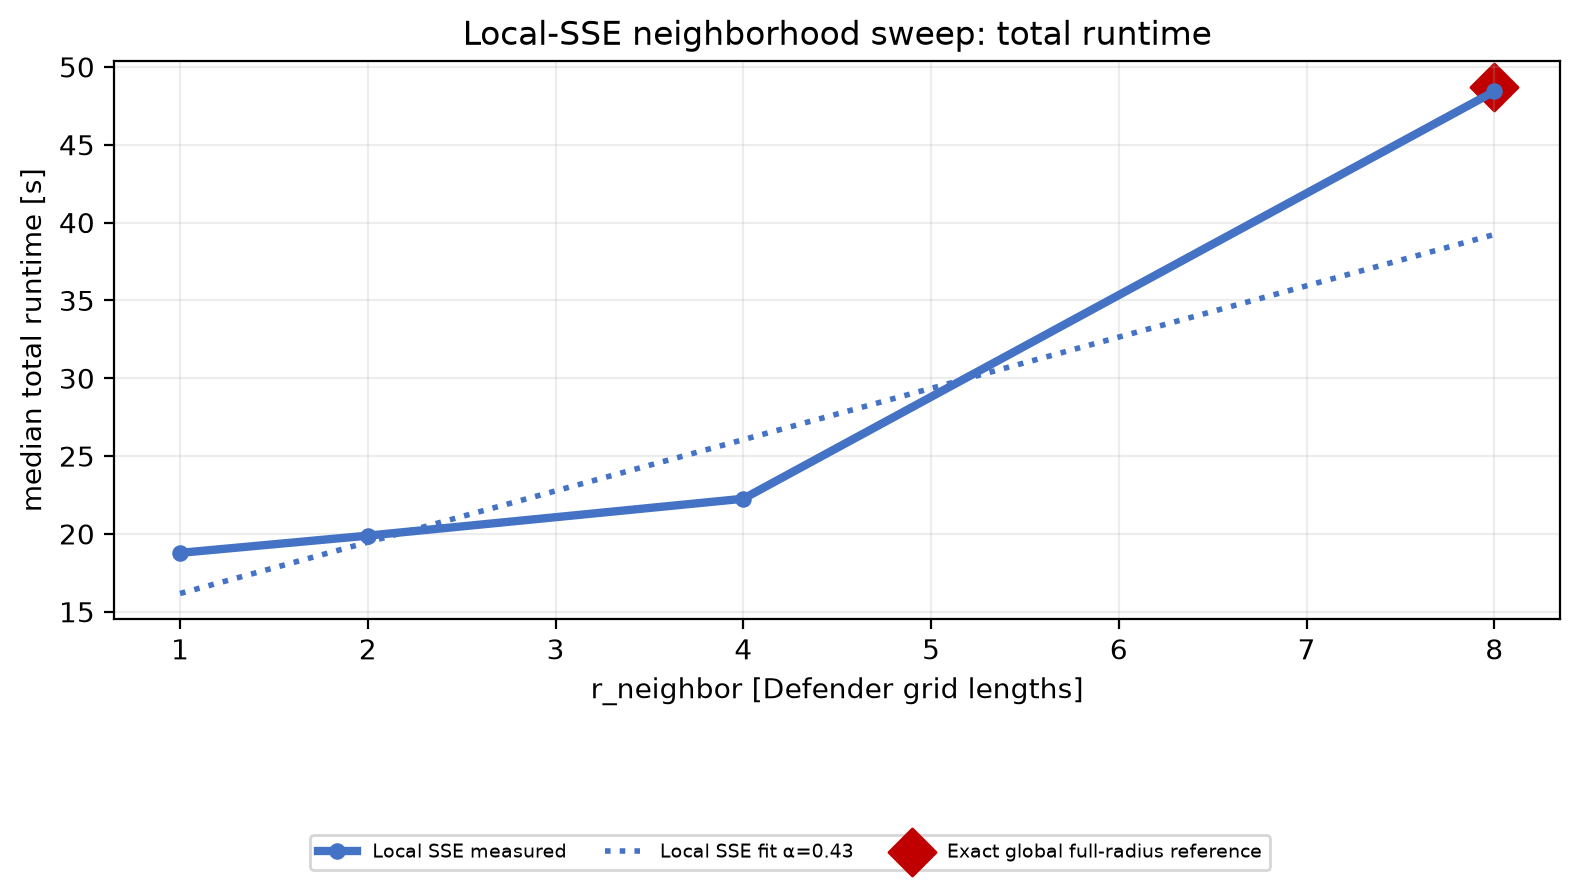

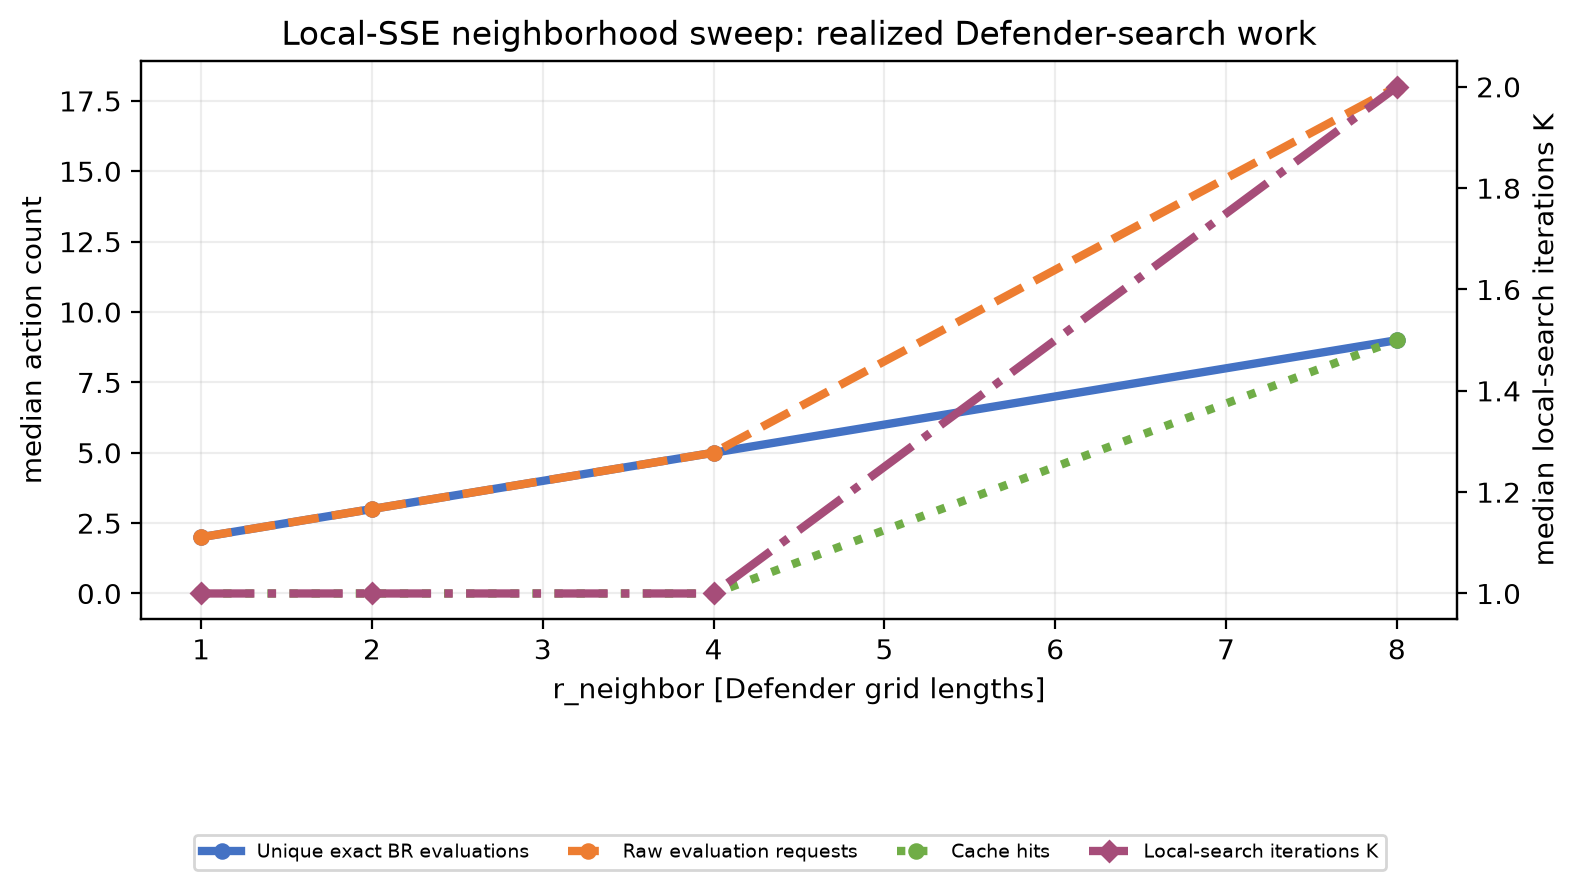

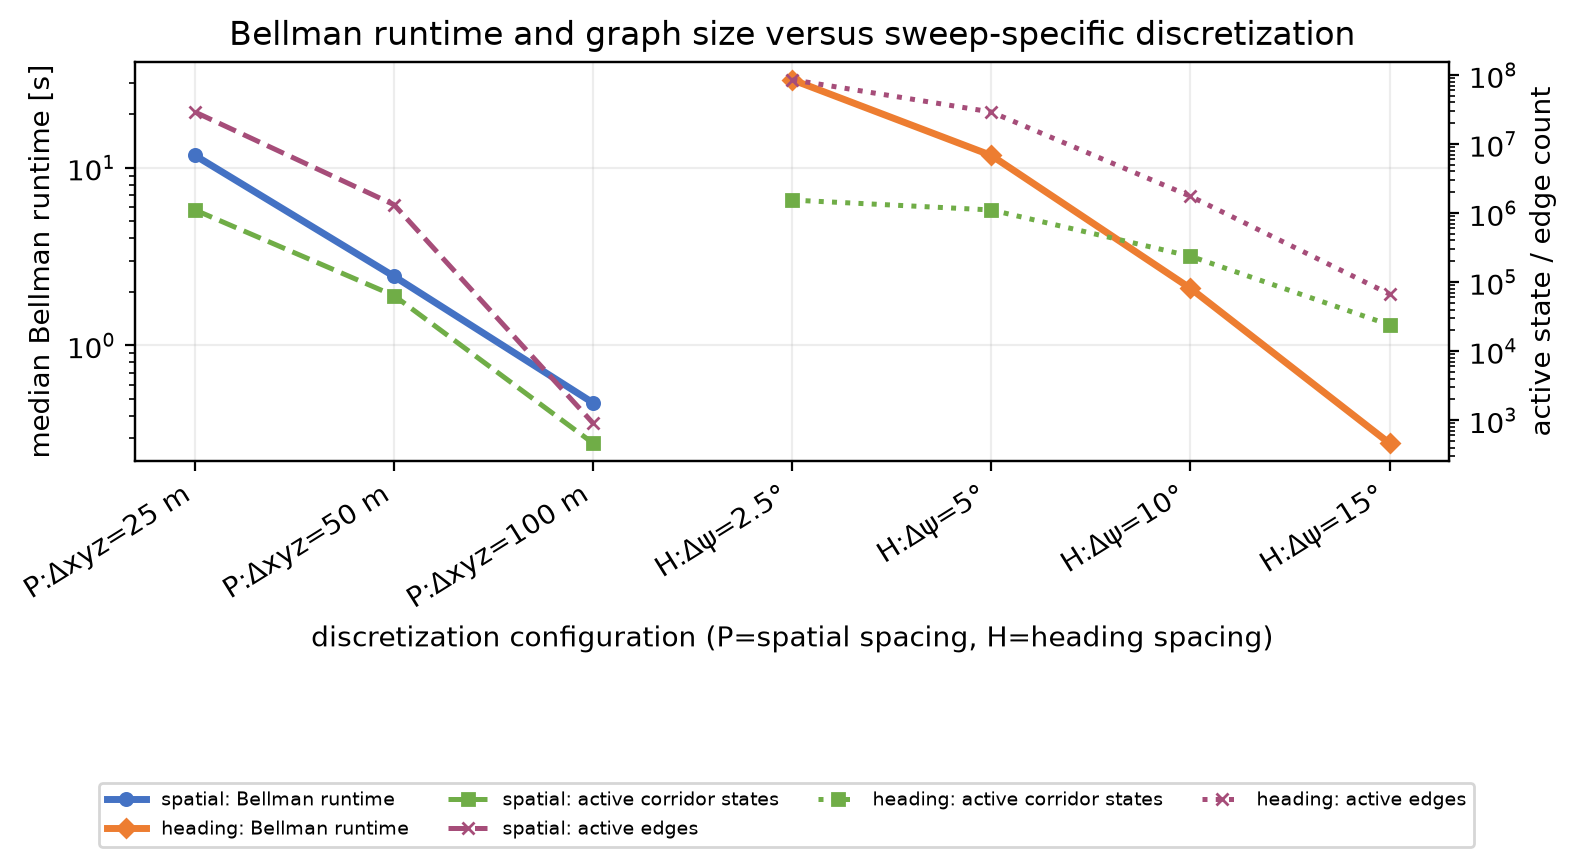

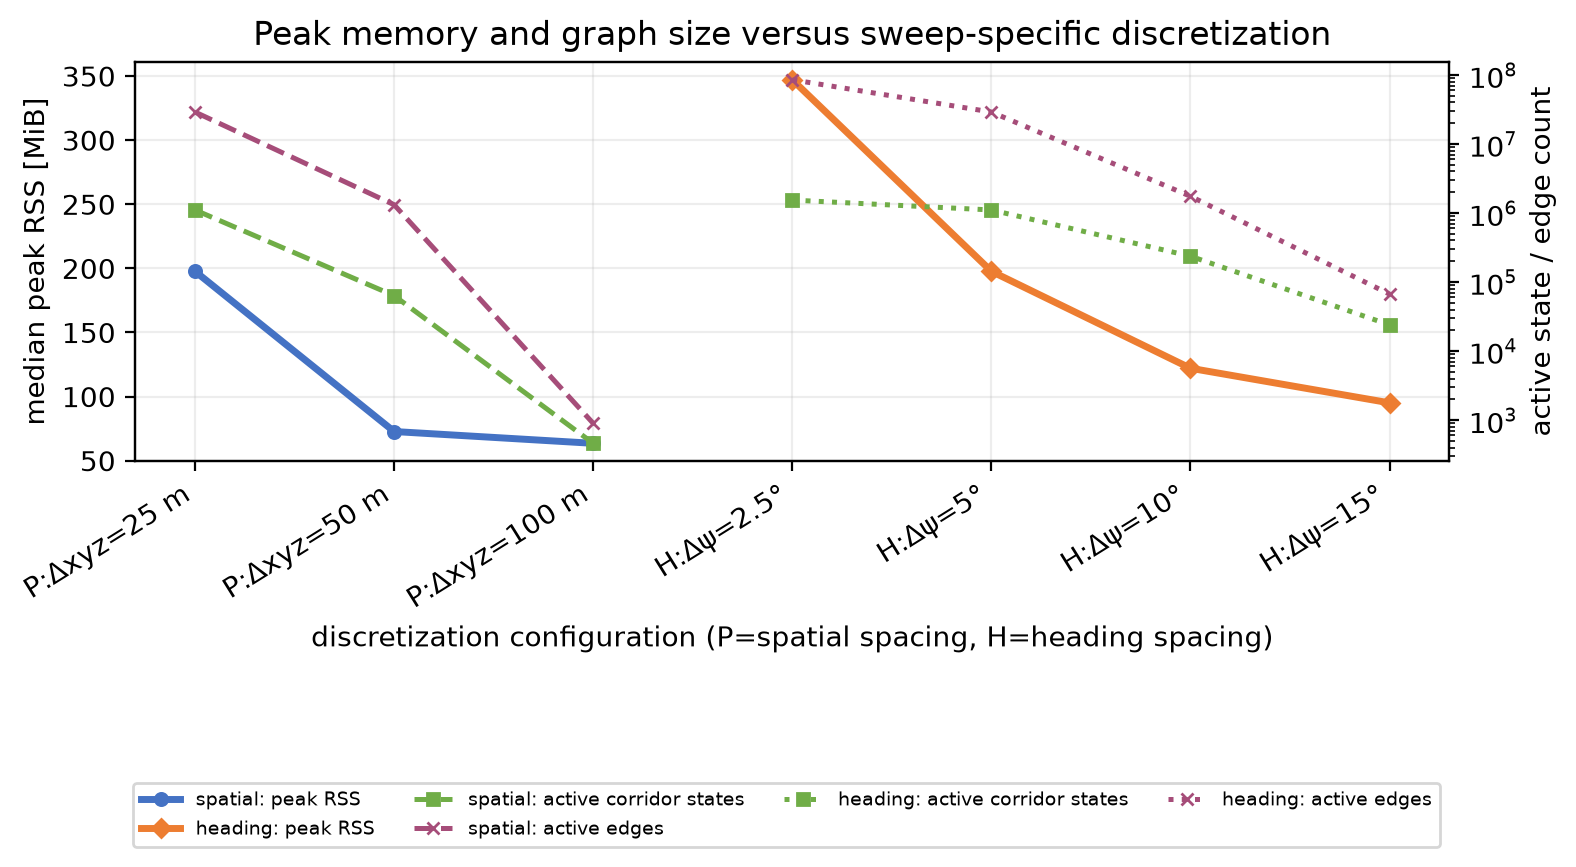

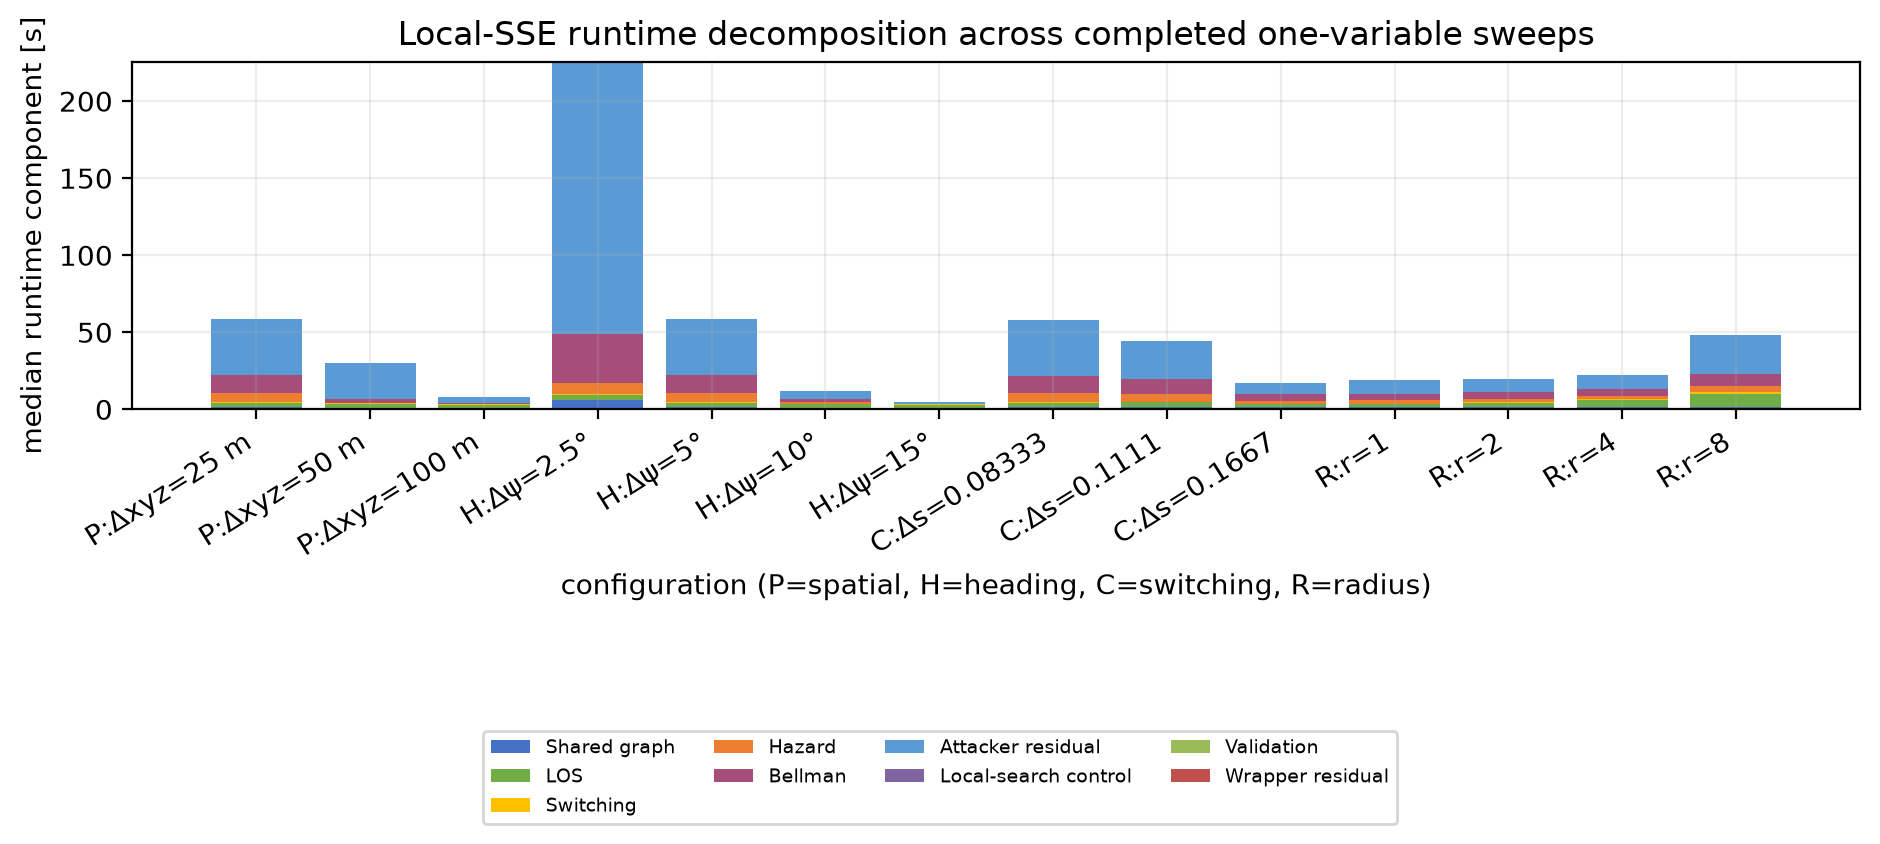

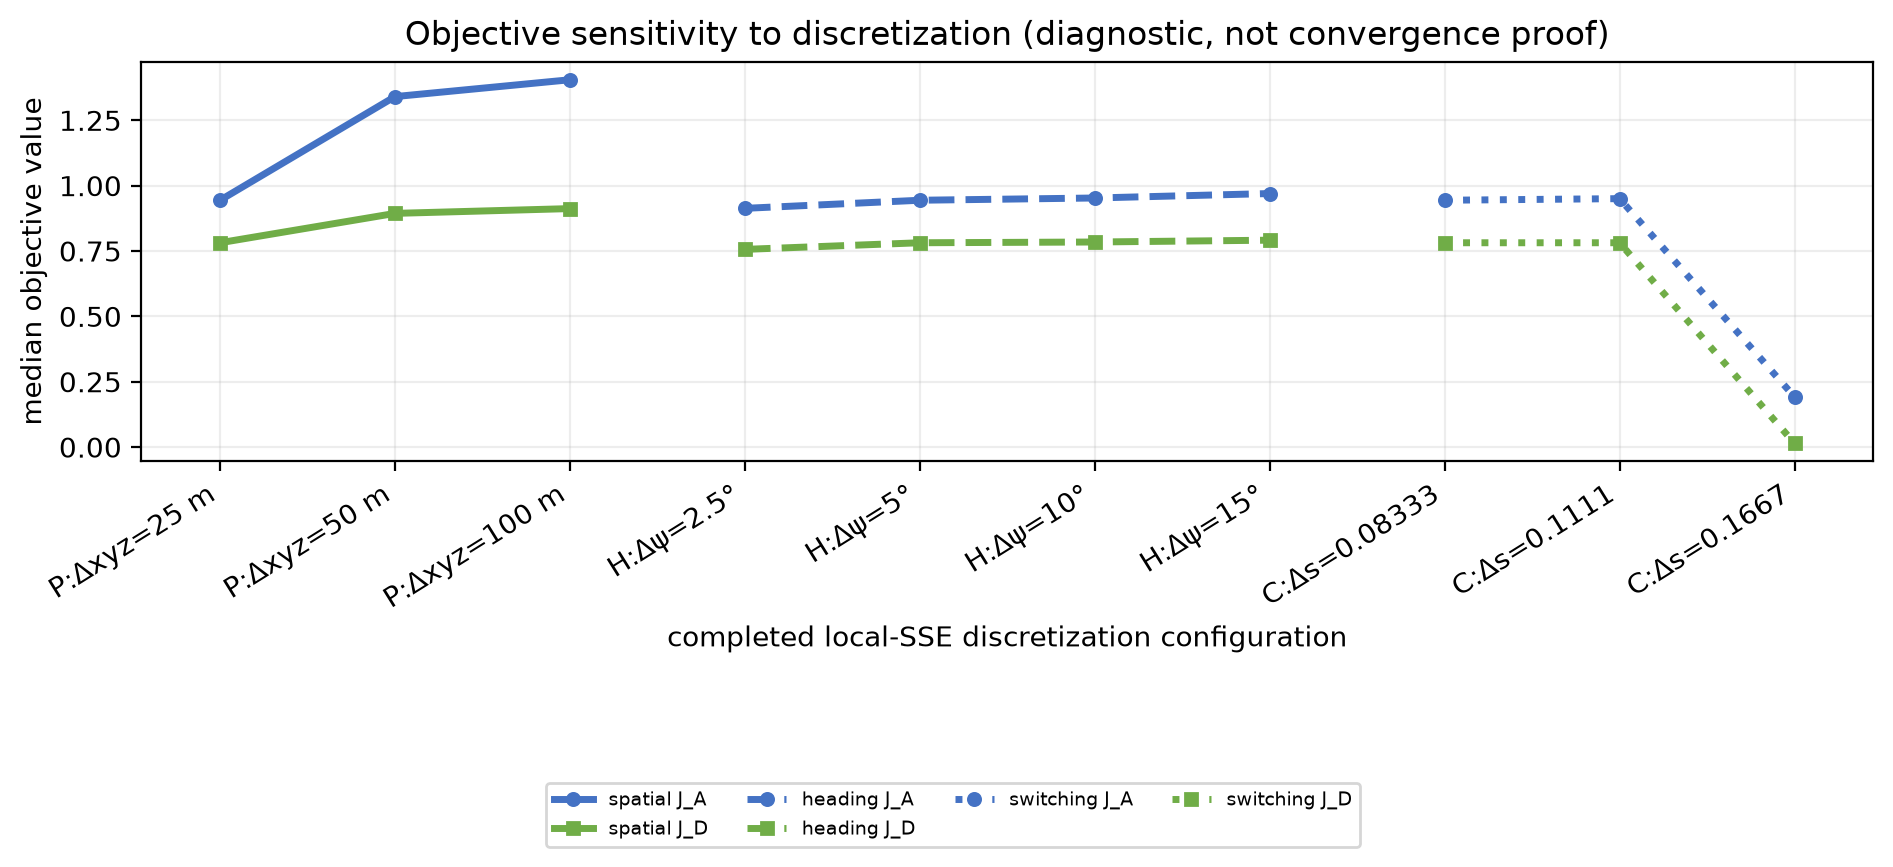

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_7_scaling_analysis\fit_parameters.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_7_scaling_analysis\fit_parameters.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_7_scaling_analysis\computational_limit_cases.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_7_scaling_analysis\raw_summary_crosscheck.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_7_scaling_analysis\theoretical_vs_empirical_interpretation.md

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_7_scaling_analysis\stage14_7_validation_report.json

In [29]:
display(HTML('<h4>Static Stage 14.7 figures</h4>'))
for figure_name in stage14_7_summary['figure_files']:
    display(HTML(f'<h5>{figure_name}</h5>'))
    display(Image(filename=str(STAGE14_7_DIR / figure_name)))

display(FileLink(STAGE14_7_DIR / 'fit_parameters.csv'))
display(FileLink(STAGE14_7_DIR / 'fit_parameters.json'))
display(FileLink(STAGE14_7_DIR / 'computational_limit_cases.json'))
display(FileLink(STAGE14_7_DIR / 'raw_summary_crosscheck.json'))
display(FileLink(STAGE14_7_DIR / 'theoretical_vs_empirical_interpretation.md'))
display(FileLink(STAGE14_7_DIR / 'stage14_7_validation_report.json'))

### Stage 14.7 claim boundary

- Theoretical reference relations and measured empirical fits are separate.
- Fits use one median point per completed configuration, not three repetitions
  treated as independent scaling samples.
- Fit curves stop at the measured minimum and maximum; no extrapolation is
  performed.
- Model-infeasible and computational/instrumentation failures are retained in
  the failure inventory and excluded from fits.
- `N_S_active` and `N_E` are never added into an artificial combined plot axis.
- State, edge, candidate, and heading-bin counts are not used as figure
  x-axes. Each figure uses the user-controlled discretization scale.
- No Stage 14.8 work is started here.

## Stage 14.8 — final integration and regression gate

This is a report-only notebook section. The external Stage-14.8 harness ran
the single canonical fresh-process smoke, all tests, artifact regeneration,
and this notebook execution. It did not rerun the Stage-14.3–14.6 sweeps and
did not start work beyond Stage 14.

In [30]:
stage14_8_summary_path = STAGE14_8_DIR / 'stage14_8_summary.json'
if not stage14_8_summary_path.exists():
    raise FileNotFoundError(
        'Stage 14.8 report is absent. Run stage14_8_final_gate.py outside the notebook.'
    )
stage14_8_summary = load_json(stage14_8_summary_path)
display_record({
    'gate_passed': stage14_8_summary['gate_passed'],
    'test_count': stage14_8_summary['test_count'],
    'figure_count': stage14_8_summary['figure_count'],
    'raw_repetition_count': stage14_8_summary['raw_repetition_count'],
    'completed_repetitions': stage14_8_summary['completed_repetition_count'],
    'noncompleted_repetitions': stage14_8_summary['noncompleted_repetition_count'],
    'canonical_clean_smoke_recorded': stage14_8_summary['canonical_clean_smoke_recorded'],
    'full_scaling_sweeps_rerun': stage14_8_summary['full_scaling_sweeps_rerun'],
    'next_stage_started': stage14_8_summary['next_stage_started'],
})
assert stage14_8_summary['gate_passed']
assert stage14_8_summary['full_scaling_sweeps_rerun'] is False
assert stage14_8_summary['next_stage_started'] is False

gate_passed,True
test_count,125
figure_count,49
raw_repetition_count,339
completed_repetitions,226
noncompleted_repetitions,113
canonical_clean_smoke_recorded,True
full_scaling_sweeps_rerun,False
next_stage_started,False


In [31]:
stage14_8_validation = load_json(STAGE14_8_DIR / 'stage14_8_validation_report.json')
check_rows = [[name, passed] for name, passed in stage14_8_validation['checks'].items()]
display(HTML(
    '<table><tr><th>Final integration check</th><th>Passed</th></tr>'
    + ''.join('<tr>' + ''.join(f'<td>{value}</td>' for value in row) + '</tr>' for row in check_rows)
    + '</table><style>th,td{border:1px solid #bbb;padding:4px 7px}</style>'
))
assert stage14_8_validation['gate_passed']
assert all(stage14_8_validation['stage14_pass_checklist'].values())

Final integration check,Passed
all_completed_equilibria_pass_independent_replay,True
all_prior_stage_gates_pass,True
all_raw_attempts_and_failures_explicit,True
all_regression_and_stage14_tests_pass,True
all_stage14_figures_recreated,True
attacker_and_defender_objectives_unchanged,True
canonical_frozen_reference_rerun_through_harness,True
empirical_fits_remain_non_asymptotic,True
integrated_notebook_executes_without_output_errors,True
profiled_and_original_solution_identities_match,True


In [32]:
display(FileLink(STAGE14_8_DIR / 'README.md'))
display(FileLink(STAGE14_8_DIR / 'all_raw_repetitions.csv'))
display(FileLink(STAGE14_8_DIR / 'all_raw_repetitions.jsonl'))
display(FileLink(STAGE14_8_DIR / 'all_configuration_summaries.csv'))
display(FileLink(STAGE14_8_DIR / 'frozen_benchmark_configuration_set.json'))
display(FileLink(STAGE14_8_DIR / 'fit_parameters.csv'))
display(FileLink(STAGE14_8_DIR / 'figure_manifest.json'))
display(FileLink(STAGE14_8_DIR / 'test_validation_report.json'))
display(FileLink(STAGE14_8_DIR / 'practical_boundary_observations.md'))
display(FileLink(STAGE14_8_DIR / 'stage14_8_validation_report.json'))

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_8_final_gate\README.md

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_8_final_gate\all_raw_repetitions.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_8_final_gate\all_raw_repetitions.jsonl

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_8_final_gate\all_configuration_summaries.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_8_final_gate\frozen_benchmark_configuration_set.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_8_final_gate\fit_parameters.csv

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_8_final_gate\figure_manifest.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_8_final_gate\test_validation_report.json

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_8_final_gate\practical_boundary_observations.md

C:\Users\jeffe\Desktop\git\glider_hybrid_control\3D_0827\figure\stage_14_8_final_gate\stage14_8_validation_report.json

### Stage 14 final claim boundary

The certified result is an exact Strong Stackelberg equilibrium of the
configured finite Defender-action, switching-candidate, and Bellman-lattice
model. The empirical scaling observations are limited to measured
configurations. This gate makes no continuous-space equilibrium claim and no
unmeasured-resolution extrapolation. Work beyond Stage 14 remains stopped.

## Beyond Stage 14 — not started

The practical tractability-boundary study and any exact-SSE-versus-RL
comparison require a separate updated plan and explicit user approval.